In [ ]:
import os
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from datetime import datetime
import cv2
from PIL import Image
from keras import backend, optimizers

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!apt-get install unrar
!pip install rarfile

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [ ]:
# Path to the .rar file
rar_file_path = "/content/drive/MyDrive/Original_Data_Only_Augmented_10000.rar"

# Destination folder for extracted files
extract_to = "/content/myData"

# Ensure the destination directory exists
os.makedirs(extract_to, exist_ok=True)

# Extract using unrar
!unrar x -r {rar_file_path} {extract_to}


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/drive/MyDrive/Original_Data_Only_Augmented_10000.rar


Would you like to replace the existing file /content/myData/final_data/masks/train/EMIDEC_Case_P003_slice_5_Inf_NoReflowN_randAug831_aug_1564.npy
131200 bytes, modified on 2025-06-26 23:42
with a new one
131200 bytes, modified on 2025-06-26 23:42

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit e

All OK


In [ ]:
  # Paths to the images and masks directories
train_images_path = "/content/myData/final_data/images/train"
train_masks_path = "/content/myData/final_data/masks/train"
val_images_path = "/content/myData/final_data/images/val"
val_masks_path = "/content/myData/final_data/masks/val"
test_images_path = "/content/myData/final_data/images/test"
test_masks_path = "/content/myData/final_data/masks/test"

# List and sort files to ensure they match
train_image_files = sorted(os.listdir(train_images_path))
train_mask_files = sorted(os.listdir(train_masks_path))
val_image_files = sorted(os.listdir(val_images_path))
val_mask_files = sorted(os.listdir(val_masks_path))
test_image_files = sorted(os.listdir(test_images_path))
test_mask_files = sorted(os.listdir(test_masks_path))

In [ ]:
def load_dataset(images_path, masks_path):
    images = []
    masks = []
    filenames = []

    # List all files in sorted order to ensure proper alignment
    image_files = sorted(os.listdir(images_path))
    mask_files = sorted(os.listdir(masks_path))

    for img_file, mask_file in zip(image_files, mask_files):
        # Full paths
        img_path = os.path.join(images_path, img_file)
        mask_path = os.path.join(masks_path, mask_file)

        # Load images and masks as NumPy arrays
        img = np.load(img_path)  # Shape: (H, W) or (H, W, C)
        mask = np.load(mask_path)  # Shape: (H, W) or (H, W, C)

        # Append to lists
        images.append(img)
        masks.append(mask)
        filenames.append(img_file)

    return images, masks, filenames


In [ ]:
# Load dataset
train_images_tensor, train_masks_tensor, train_filenames = load_dataset(train_images_path, train_masks_path)
val_images_tensor, val_masks_tensor, val_filenames = load_dataset(val_images_path, val_masks_path)
test_images_tensor, test_masks_tensor, test_filenames = load_dataset(test_images_path, test_masks_path)
train_images_tensor = tf.expand_dims(train_images_tensor, axis=-1)
train_masks_tensor = tf.expand_dims(train_masks_tensor, axis=-1)
val_images_tensor = tf.expand_dims(val_images_tensor, axis=-1)
val_masks_tensor = tf.expand_dims(val_masks_tensor, axis=-1)
test_images_tensor = tf.expand_dims(test_images_tensor, axis=-1)
test_masks_tensor = tf.expand_dims(test_masks_tensor, axis=-1)



# Check shapes
print(f"Train Images Tensor Shape: {train_images_tensor.shape}, dtype: {train_images_tensor.dtype}")
print(f"Train Masks Tensor Shape: {train_masks_tensor.shape}, dtype: {train_masks_tensor.dtype}")
print(f"Val Images Tensor Shape: {val_images_tensor.shape}, dtype: {val_images_tensor.dtype}")
print(f"Val Masks Tensor Shape: {val_masks_tensor.shape}, dtype: {val_masks_tensor.dtype}")
print(f"Test Images Tensor Shape: {test_images_tensor.shape}, dtype: {test_images_tensor.dtype}")
print(f"Test Masks Tensor Shape: {test_masks_tensor.shape}, dtype: {test_masks_tensor.dtype}")

Train Images Tensor Shape: (10000, 128, 128, 1), dtype: <dtype: 'float64'>
Train Masks Tensor Shape: (10000, 128, 128, 1), dtype: <dtype: 'float64'>
Val Images Tensor Shape: (60, 128, 128, 1), dtype: <dtype: 'float64'>
Val Masks Tensor Shape: (60, 128, 128, 1), dtype: <dtype: 'float64'>
Test Images Tensor Shape: (80, 128, 128, 1), dtype: <dtype: 'float64'>
Test Masks Tensor Shape: (80, 128, 128, 1), dtype: <dtype: 'float64'>


In [ ]:
# Model input shape
IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS = train_images_tensor.shape[1:]
NUM_CLASSES = 5
input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
batch_size = 8

In [ ]:
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras import backend as K
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy, MeanIoU
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
from tensorflow.keras.callbacks import ModelCheckpoint


## Useful blocks to build Unet


In [ ]:
def conv_block(x, filter_size, size, dropout, batch_norm=False):

    conv = layers.Conv2D(size, (filter_size, filter_size), padding="same")(x)
    if batch_norm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    conv = layers.Activation("relu")(conv)

    conv = layers.Conv2D(size, (filter_size, filter_size), padding="same")(conv)
    if batch_norm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    conv = layers.Activation("relu")(conv)

    if dropout > 0:
        conv = layers.Dropout(dropout)(conv)

    return conv

In [ ]:
def repeat_elem(tensor, rep):
    # lambda function to repeat Repeats the elements of a tensor along an axis
    #by a factor of rep.
    # If tensor has shape (None, 256,256,3), lambda will return a tensor of shape
    #(None, 256,256,6), if specified axis=3 and rep=2.

     return layers.Lambda(lambda x, repnum: K.repeat_elements(x, repnum, axis=3),
                          arguments={'repnum': rep})(tensor)

In [ ]:
def res_conv_block(x, filter_size, size, dropout, batch_norm=False):
    '''
    Residual convolutional layer.
    Two variants....
    Either put activation function before the addition with shortcut
    or after the addition (which would be as proposed in the original resNet).

    1. conv - BN - Activation - conv - BN - Activation
                                          - shortcut  - BN - shortcut+BN

    2. conv - BN - Activation - conv - BN
                                     - shortcut  - BN - shortcut+BN - Activation

    Check fig 4 in https://arxiv.org/ftp/arxiv/papers/1802/1802.06955.pdf
    '''

    conv = layers.Conv2D(size, (filter_size, filter_size), padding='same')(x)
    if batch_norm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    conv = layers.Activation('relu')(conv)

    conv = layers.Conv2D(size, (filter_size, filter_size), padding='same')(conv)
    if batch_norm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    #conv = layers.Activation('relu')(conv)    #Activation before addition with shortcut
    if dropout > 0:
        conv = layers.Dropout(dropout)(conv)

    shortcut = layers.Conv2D(size, kernel_size=(1, 1), padding='same')(x)
    if batch_norm is True:
        shortcut = layers.BatchNormalization(axis=3)(shortcut)

    res_path = layers.add([shortcut, conv])
    res_path = layers.Activation('relu')(res_path)    #Activation after addition with shortcut (Original residual block)
    return res_path

In [ ]:
def gating_signal(input, out_size, batch_norm=False):
    """
    resize the down layer feature map into the same dimension as the up layer feature map
    using 1x1 conv
    :return: the gating feature map with the same dimension of the up layer feature map
    """
    x = layers.Conv2D(out_size, (1, 1), padding='same')(input)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

In [ ]:
def attention_block(x, gating, inter_shape):
    shape_x = K.int_shape(x)
    shape_g = K.int_shape(gating)

# Getting the x signal to the same shape as the gating signal
    theta_x = layers.Conv2D(inter_shape, (2, 2), strides=(2, 2), padding='same')(x)  # 16
    shape_theta_x = K.int_shape(theta_x)

# Getting the gating signal to the same number of filters as the inter_shape
    phi_g = layers.Conv2D(inter_shape, (1, 1), padding='same')(gating)
    upsample_g = layers.Conv2DTranspose(inter_shape, (3, 3),
                                 strides=(shape_theta_x[1] // shape_g[1], shape_theta_x[2] // shape_g[2]),
                                 padding='same')(phi_g)  # 16

    concat_xg = layers.add([upsample_g, theta_x])
    act_xg = layers.Activation('relu')(concat_xg)
    psi = layers.Conv2D(1, (1, 1), padding='same')(act_xg)
    sigmoid_xg = layers.Activation('sigmoid')(psi)
    shape_sigmoid = K.int_shape(sigmoid_xg)
    upsample_psi = layers.UpSampling2D(size=(shape_x[1] // shape_sigmoid[1], shape_x[2] // shape_sigmoid[2]))(sigmoid_xg)  # 32

    upsample_psi = repeat_elem(upsample_psi, shape_x[3])

    y = layers.multiply([upsample_psi, x])

    result = layers.Conv2D(shape_x[3], (1, 1), padding='same')(y)
    result_bn = layers.BatchNormalization()(result)
    return result_bn

In [ ]:
def Attention_ResUNet(input_shape, NUM_CLASSES=1, dropout_rate=0.0, batch_norm=True):
    '''
    Rsidual UNet, with attention

    '''
    # network structure
    FILTER_NUM = 64 # number of basic filters for the first layer
    FILTER_SIZE = 3 # size of the convolutional filter
    UP_SAMP_SIZE = 2 # size of upsampling filters
    # input data
    # dimension of the image depth
    inputs = layers.Input(input_shape, dtype=tf.float32)
    axis = 3

    # Downsampling layers
    # DownRes 1, double residual convolution + pooling
    conv_128 = res_conv_block(inputs, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)
    pool_64 = layers.MaxPooling2D(pool_size=(2,2))(conv_128)
    # DownRes 2
    conv_64 = res_conv_block(pool_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    pool_32 = layers.MaxPooling2D(pool_size=(2,2))(conv_64)
    # DownRes 3
    conv_32 = res_conv_block(pool_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    pool_16 = layers.MaxPooling2D(pool_size=(2,2))(conv_32)
    # DownRes 4
    conv_16 = res_conv_block(pool_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    pool_8 = layers.MaxPooling2D(pool_size=(2,2))(conv_16)
    # DownRes 5, convolution only
    conv_8 = res_conv_block(pool_8, FILTER_SIZE, 16*FILTER_NUM, dropout_rate, batch_norm)

    # Upsampling layers
    # UpRes 6, attention gated concatenation + upsampling + double residual convolution
    gating_16 = gating_signal(conv_8, 8*FILTER_NUM, batch_norm)
    att_16 = attention_block(conv_16, gating_16, 8*FILTER_NUM)
    up_16 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(conv_8)
    up_16 = layers.concatenate([up_16, att_16], axis=axis)
    up_conv_16 = res_conv_block(up_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 7
    gating_32 = gating_signal(up_conv_16, 4*FILTER_NUM, batch_norm)
    att_32 = attention_block(conv_32, gating_32, 4*FILTER_NUM)
    up_32 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_16)
    up_32 = layers.concatenate([up_32, att_32], axis=axis)
    up_conv_32 = res_conv_block(up_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 8
    gating_64 = gating_signal(up_conv_32, 2*FILTER_NUM, batch_norm)
    att_64 = attention_block(conv_64, gating_64, 2*FILTER_NUM)
    up_64 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_32)
    up_64 = layers.concatenate([up_64, att_64], axis=axis)
    up_conv_64 = res_conv_block(up_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 9
    gating_128 = gating_signal(up_conv_64, FILTER_NUM, batch_norm)
    att_128 = attention_block(conv_128, gating_128, FILTER_NUM)
    up_128 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_64)
    up_128 = layers.concatenate([up_128, att_128], axis=axis)
    up_conv_128 = res_conv_block(up_128, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)

    # 1*1 convolutional layers

    conv_final = layers.Conv2D(NUM_CLASSES, kernel_size=(1,1))(up_conv_128)
    conv_final = layers.BatchNormalization(axis=axis)(conv_final)
    conv_final = layers.Activation('softmax')(conv_final)


    # Model integration
    model = models.Model(inputs, conv_final, name="AttentionResUNet")
    return model

In [ ]:
def weighted_sparse_categorical_crossentropy(class_weights):
    def loss(y_true, y_pred):
        # Flatten tensors
        y_true_flat = tf.reshape(y_true, [-1])
        y_pred_flat = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])

        # Cast to int32 before using one-hot
        y_true_flat = tf.cast(y_true_flat, tf.int32)

        # One-hot encode y_true
        y_true_one_hot = tf.one_hot(y_true_flat, depth=tf.shape(y_pred)[-1])

        # Standard categorical crossentropy
        ce = tf.keras.losses.categorical_crossentropy(y_true_one_hot, y_pred_flat)

        # Apply per-pixel weights based on true class
        weights = tf.gather(class_weights, y_true_flat)
        weighted_loss = ce * weights

        return tf.reduce_mean(weighted_loss)

    return loss


In [ ]:
# Class weights as per generator loss
class_weights = tf.constant([1.0, 7.0, 11.0, 26.0, 90.0], dtype=tf.float32)

model = Attention_ResUNet(input_shape=(128, 128, 1), NUM_CLASSES=5)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=weighted_sparse_categorical_crossentropy(class_weights),
    metrics=[SparseCategoricalAccuracy()]
)
model.summary()

Model: "AttentionResUNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │        128 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │      8,320 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_5[0][0]  

 Total params: 39,089,373 (149.11 MB)

 Trainable params: 39,067,859 (149.03 MB)

 Non-trainable params: 21,514 (84.04 KB)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [ ]:
def generate_images(model, test_input, tar):
    test_input = tf.squeeze(test_input, axis=0)  # Remove batch dim
    tar = tf.squeeze(tar, axis=0)  # Remove batch dim
    prediction = model(tf.expand_dims(test_input, axis=0), training=False)
    prediction = tf.argmax(prediction, axis=-1)  # Convert softmax to class labels
    prediction = tf.squeeze(prediction, axis=0)  # Remove batch dim

    cmap_mask = ListedColormap(['black', 'white', 'gray', 'red', 'yellow'])

    plt.figure(figsize=(15, 5))
    display_list = [test_input, tar, prediction]
    titles = ['Input Image', 'Ground Truth Mask', 'Predicted Mask']

    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.title(titles[i])

        if i == 0:
            # Assume grayscale input
            if len(display_list[i].shape) == 2:
                plt.imshow(display_list[i], cmap='gray')
            else:
                plt.imshow(tf.squeeze(display_list[i], axis=-1), cmap='gray')
        else:
            # Use colormap for masks
            plt.imshow(display_list[i], cmap=cmap_mask, vmin=0, vmax=4)

        plt.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
# Custom callback
class CheckpointAndPlotCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_images_tensor, val_masks_tensor, checkpoint_dir, every_n_epochs=10):
        super().__init__()
        self.val_images = val_images_tensor
        self.val_masks = val_masks_tensor
        self.checkpoint_dir = checkpoint_dir
        self.every_n = every_n_epochs

        # Choose one sample to track
        idx = np.random.randint(0, len(val_images_tensor))
        self.sample_image = val_images_tensor[idx:idx+1]  # keep batch dim
        self.sample_mask = val_masks_tensor[idx:idx+1]

        os.makedirs(self.checkpoint_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            # Save model
            checkpoint_path = os.path.join(self.checkpoint_dir, f'ckpt-epoch{epoch+1}.weights.h5')
            self.model.save_weights(checkpoint_path)
            print(f"Saved checkpoint: {checkpoint_path}")

        # Plotting
        print(f"Generating predictions at epoch {epoch+1}")
        generate_images(self.model, self.sample_image, self.sample_mask)

In [ ]:
class PerClassDiceCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_images, val_masks, num_classes):
        super().__init__()
        self.val_images = val_images
        self.val_masks = val_masks
        self.num_classes = num_classes

    def dice_score(self, y_true, y_pred, class_id, smooth=1e-6):
        # Create binary masks for the class
        y_true_class = tf.cast(tf.equal(y_true, class_id), tf.float32)
        y_pred_class = tf.cast(tf.equal(y_pred, class_id), tf.float32)

        intersection = tf.reduce_sum(y_true_class * y_pred_class)
        union = tf.reduce_sum(y_true_class) + tf.reduce_sum(y_pred_class)

        return (2. * intersection + smooth) / (union + smooth)

    def on_epoch_end(self, epoch, logs=None):
        preds = self.model.predict(self.val_images, verbose=0)
        preds = tf.argmax(preds, axis=-1)  # [batch, H, W]

        y_true = tf.squeeze(self.val_masks, axis=-1)  # Make sure shape matches [batch, H, W]

        print("\nPer-class Dice scores:")
        for class_id in range(self.num_classes):
            dice = self.dice_score(y_true, preds, class_id)
            print(f"  Class {class_id}: Dice = {dice.numpy():.4f}")


In [ ]:
class BestDiceCheckpointCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_images, val_masks, num_classes, save_path):
        super().__init__()
        self.val_images = val_images
        self.val_masks = val_masks
        self.num_classes = num_classes
        self.save_path = save_path
        self.best_dice = -1  # initialize with lowest possible

    def dice_score(self, y_true, y_pred, class_id, smooth=1e-6):
        y_true_class = tf.cast(tf.equal(y_true, class_id), tf.float32)
        y_pred_class = tf.cast(tf.equal(y_pred, class_id), tf.float32)

        intersection = tf.reduce_sum(y_true_class * y_pred_class)
        union = tf.reduce_sum(y_true_class) + tf.reduce_sum(y_pred_class)

        return (2. * intersection + smooth) / (union + smooth)

    def on_epoch_end(self, epoch, logs=None):
        preds = self.model.predict(self.val_images, verbose=0)
        preds = tf.argmax(preds, axis=-1)
        y_true = tf.squeeze(self.val_masks, axis=-1)

        # Compute mean dice across all classes
        dice_scores = []
        for class_id in range(self.num_classes):
            dice = self.dice_score(y_true, preds, class_id)
            dice_scores.append(dice)
        mean_dice = tf.reduce_mean(dice_scores)

        print(f"\nEpoch {epoch+1}: Mean Dice = {mean_dice:.4f}")
        if mean_dice > self.best_dice:
            self.best_dice = mean_dice
            self.model.save_weights(self.save_path)
            print(f"✅ New best Dice score! Model saved to {self.save_path}")


In [ ]:
# Example usage:
checkpoint_dir = '/content/drive/MyDrive/Original_Data_Only_Augmented_10000/ckpt'
best_model_dir = '/content/drive/MyDrive/Original_Data_Only_Augmented_10000/best'
os.makedirs(best_model_dir, exist_ok=True)

dice_callback = PerClassDiceCallback(
    val_images=val_images_tensor,
    val_masks=val_masks_tensor,
    num_classes=5  # since you have 5 classes: background, cavity, myocardium, infarction, no-reflow
)

# Callbacks
callbacks = [
    CheckpointAndPlotCallback(val_images_tensor, val_masks_tensor, checkpoint_dir=checkpoint_dir, every_n_epochs=10),
    PerClassDiceCallback(val_images=val_images_tensor, val_masks=val_masks_tensor, num_classes=5),
    BestDiceCheckpointCallback(
        val_images=val_images_tensor,
        val_masks=val_masks_tensor,
        num_classes=5,
        save_path=os.path.join(best_model_dir, 'best_model_dice.weights.h5')
    )
]

Epoch 1/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - loss: 2.5109 - sparse_categorical_accuracy: 0.7843Generating predictions at epoch 1


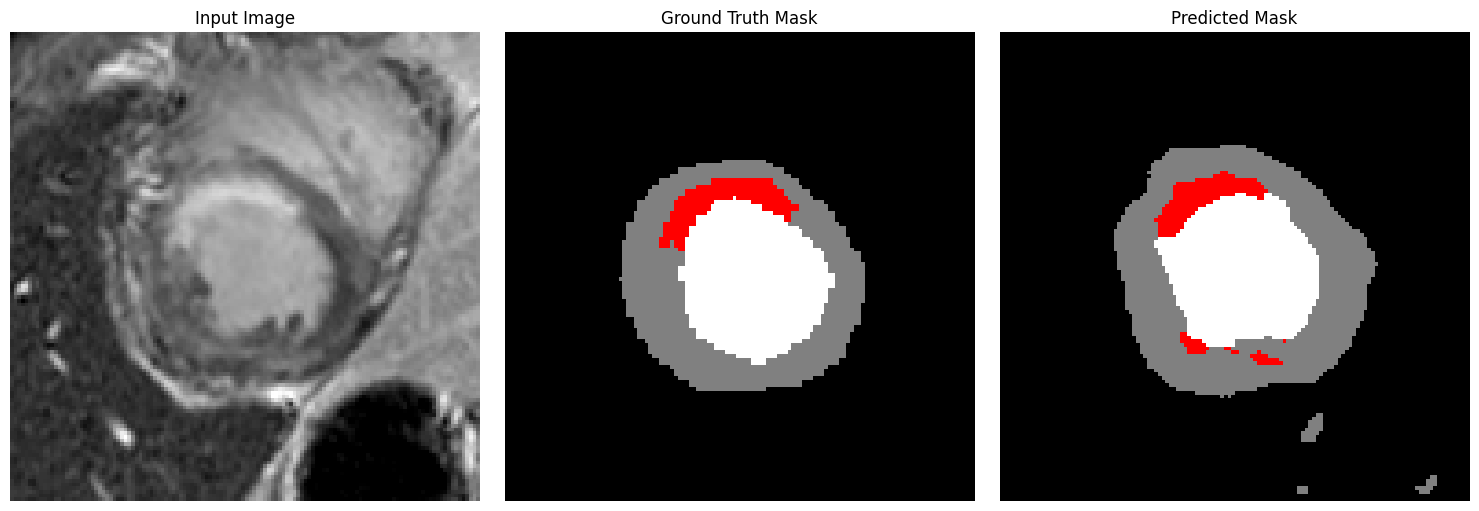


Per-class Dice scores:
  Class 0: Dice = 0.9552
  Class 1: Dice = 0.8669
  Class 2: Dice = 0.6949
  Class 3: Dice = 0.4209
  Class 4: Dice = 0.1668

Epoch 1: Mean Dice = 0.6209
✅ New best Dice score! Model saved to /content/drive/MyDrive/Original_Data_Only_Augmented_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 407s 261ms/step - loss: 2.5105 - sparse_categorical_accuracy: 0.7844 - val_loss: 1.3818 - val_sparse_categorical_accuracy: 0.9008
Epoch 2/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 1.3196 - sparse_categorical_accuracy: 0.9220Generating predictions at epoch 2


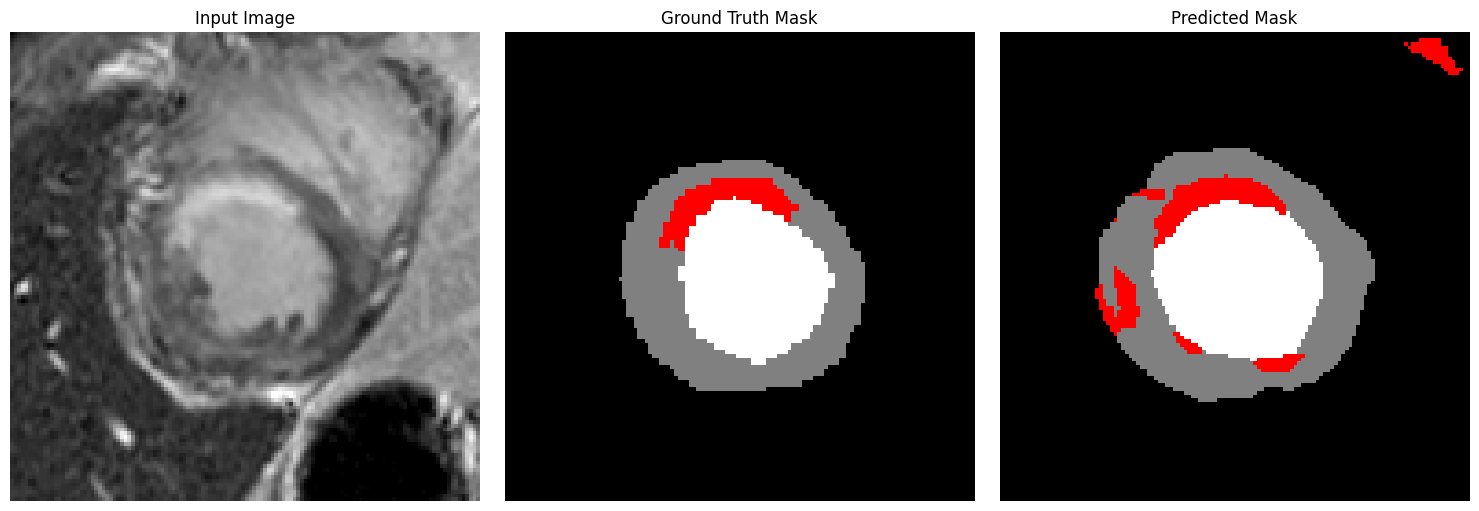


Per-class Dice scores:
  Class 0: Dice = 0.9187
  Class 1: Dice = 0.8629
  Class 2: Dice = 0.6641
  Class 3: Dice = 0.2928
  Class 4: Dice = 0.0492

Epoch 2: Mean Dice = 0.5576
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 275s 217ms/step - loss: 1.3195 - sparse_categorical_accuracy: 0.9220 - val_loss: 1.4531 - val_sparse_categorical_accuracy: 0.8494
Epoch 3/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 1.0728 - sparse_categorical_accuracy: 0.9357Generating predictions at epoch 3


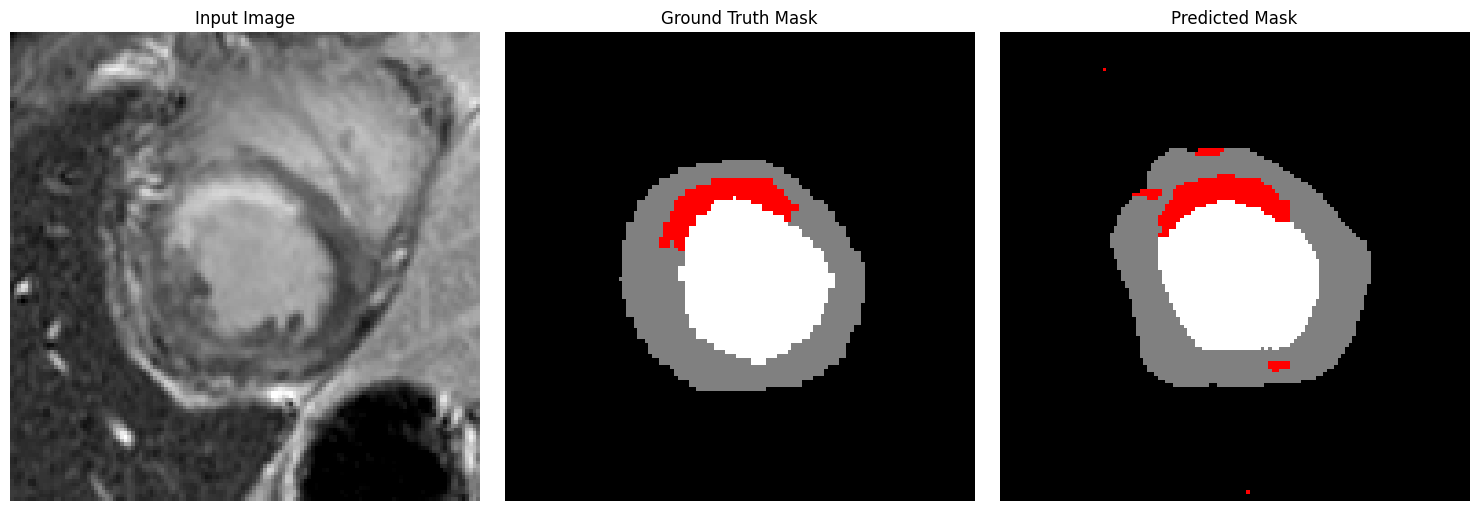


Per-class Dice scores:
  Class 0: Dice = 0.9540
  Class 1: Dice = 0.9022
  Class 2: Dice = 0.7240
  Class 3: Dice = 0.3521
  Class 4: Dice = 0.1561

Epoch 3: Mean Dice = 0.6177
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 270s 216ms/step - loss: 1.0728 - sparse_categorical_accuracy: 0.9357 - val_loss: 1.2127 - val_sparse_categorical_accuracy: 0.9024
Epoch 4/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.9234 - sparse_categorical_accuracy: 0.9425Generating predictions at epoch 4


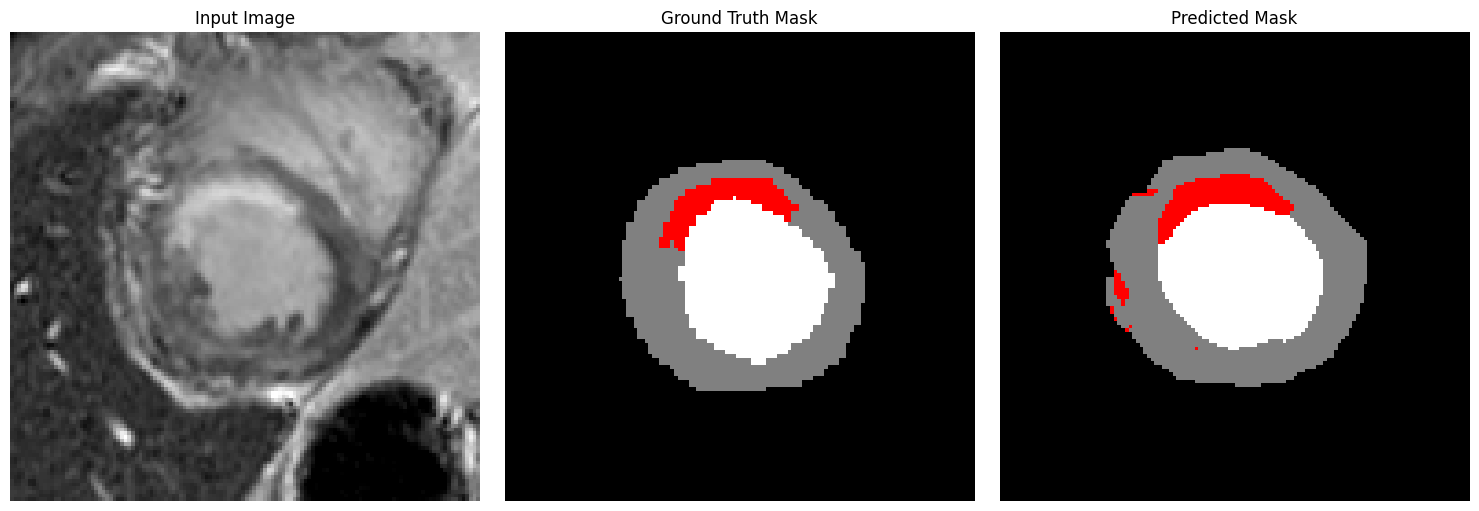


Per-class Dice scores:
  Class 0: Dice = 0.9598
  Class 1: Dice = 0.9041
  Class 2: Dice = 0.7239
  Class 3: Dice = 0.4036
  Class 4: Dice = 0.2942

Epoch 4: Mean Dice = 0.6571
✅ New best Dice score! Model saved to /content/drive/MyDrive/Original_Data_Only_Augmented_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 335s 227ms/step - loss: 0.9234 - sparse_categorical_accuracy: 0.9425 - val_loss: 1.1295 - val_sparse_categorical_accuracy: 0.9136
Epoch 5/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.8926 - sparse_categorical_accuracy: 0.9436Generating predictions at epoch 5


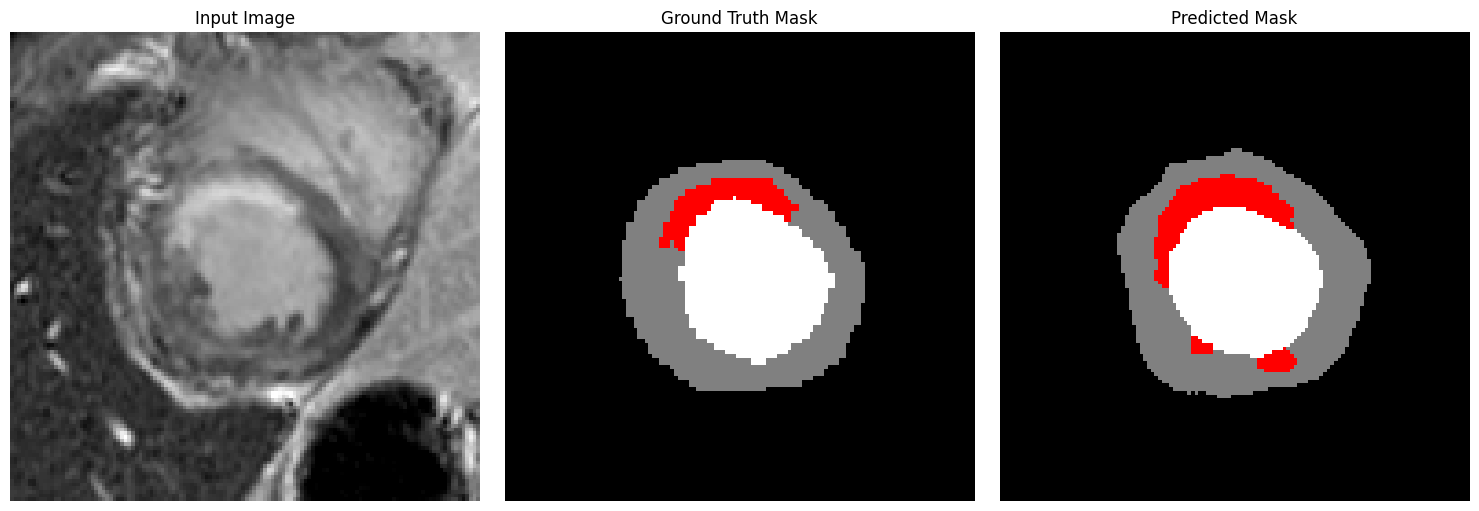


Per-class Dice scores:
  Class 0: Dice = 0.9776
  Class 1: Dice = 0.9050
  Class 2: Dice = 0.7776
  Class 3: Dice = 0.5596
  Class 4: Dice = 0.2962

Epoch 5: Mean Dice = 0.7032
✅ New best Dice score! Model saved to /content/drive/MyDrive/Original_Data_Only_Augmented_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 324s 228ms/step - loss: 0.8926 - sparse_categorical_accuracy: 0.9436 - val_loss: 0.9834 - val_sparse_categorical_accuracy: 0.9396
Epoch 6/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.8014 - sparse_categorical_accuracy: 0.9489Generating predictions at epoch 6


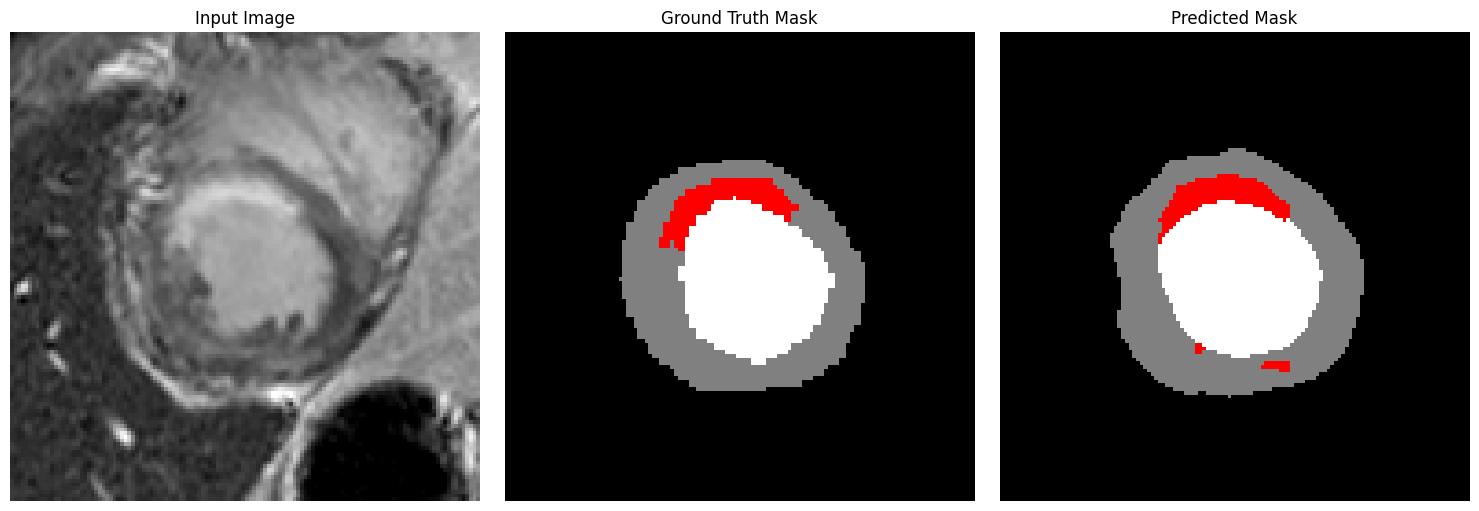


Per-class Dice scores:
  Class 0: Dice = 0.9740
  Class 1: Dice = 0.9202
  Class 2: Dice = 0.7623
  Class 3: Dice = 0.5576
  Class 4: Dice = 0.3743

Epoch 6: Mean Dice = 0.7177
✅ New best Dice score! Model saved to /content/drive/MyDrive/Original_Data_Only_Augmented_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 324s 230ms/step - loss: 0.8014 - sparse_categorical_accuracy: 0.9489 - val_loss: 0.9747 - val_sparse_categorical_accuracy: 0.9373
Epoch 7/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.7243 - sparse_categorical_accuracy: 0.9524Generating predictions at epoch 7


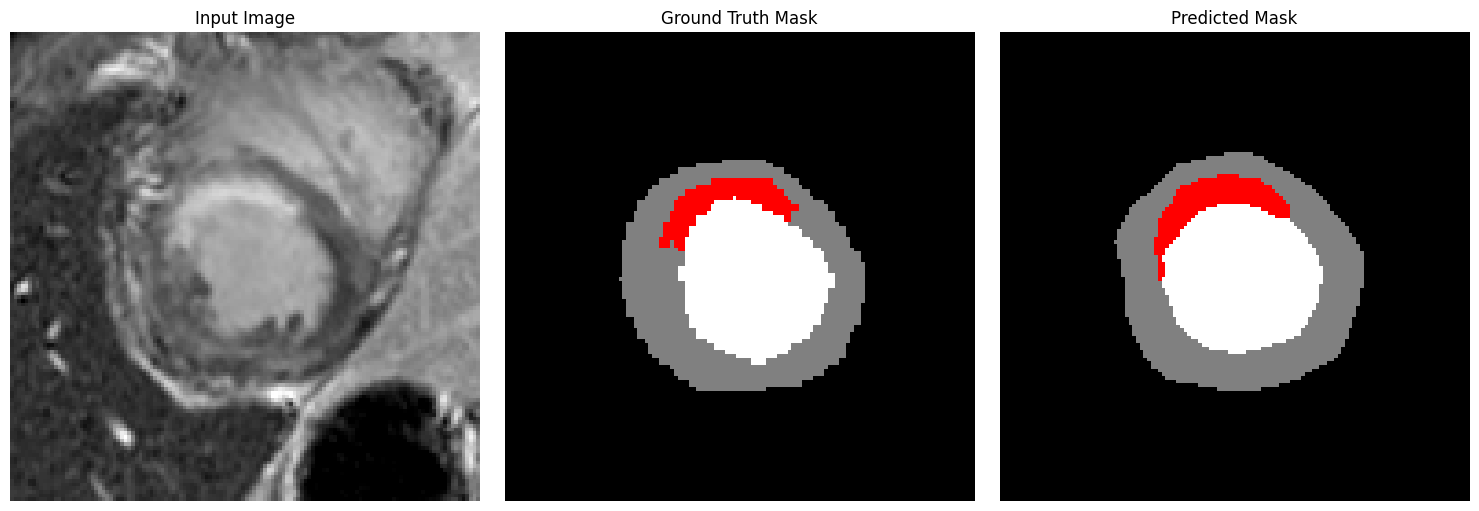


Per-class Dice scores:
  Class 0: Dice = 0.9807
  Class 1: Dice = 0.9217
  Class 2: Dice = 0.7929
  Class 3: Dice = 0.6146
  Class 4: Dice = 0.4701

Epoch 7: Mean Dice = 0.7560
✅ New best Dice score! Model saved to /content/drive/MyDrive/Original_Data_Only_Augmented_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 317s 227ms/step - loss: 0.7243 - sparse_categorical_accuracy: 0.9524 - val_loss: 0.9118 - val_sparse_categorical_accuracy: 0.9484
Epoch 8/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.6848 - sparse_categorical_accuracy: 0.9540Generating predictions at epoch 8


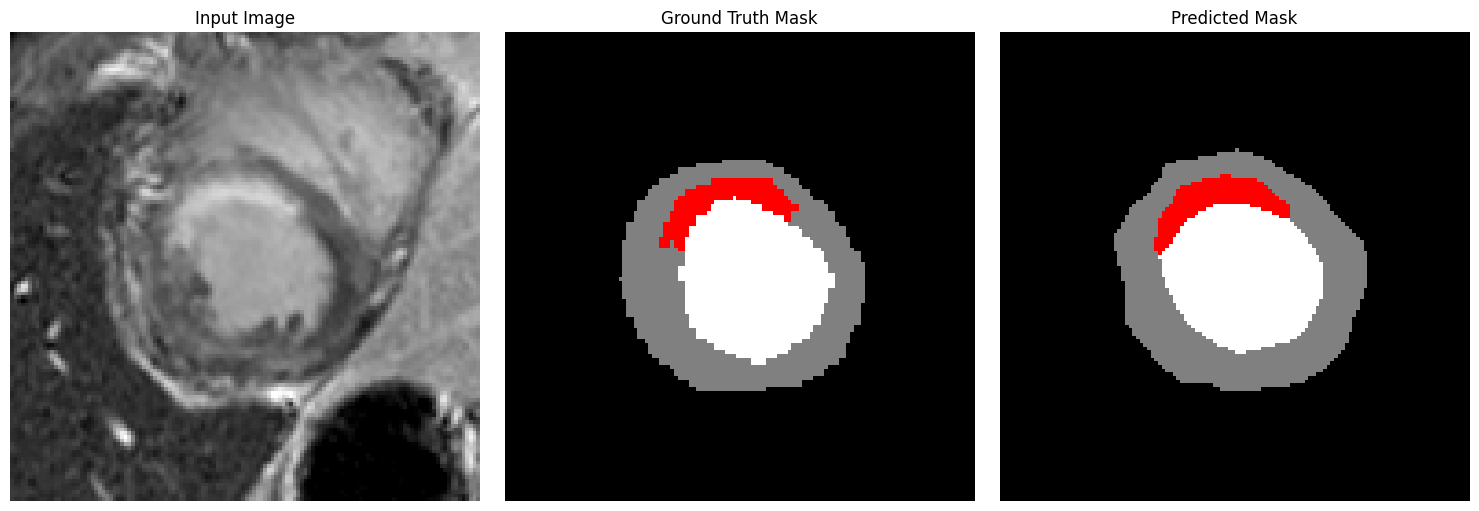


Per-class Dice scores:
  Class 0: Dice = 0.9802
  Class 1: Dice = 0.9092
  Class 2: Dice = 0.7966
  Class 3: Dice = 0.5439
  Class 4: Dice = 0.3591

Epoch 8: Mean Dice = 0.7178
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 309s 216ms/step - loss: 0.6848 - sparse_categorical_accuracy: 0.9540 - val_loss: 0.9841 - val_sparse_categorical_accuracy: 0.9449
Epoch 9/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.6370 - sparse_categorical_accuracy: 0.9566Generating predictions at epoch 9


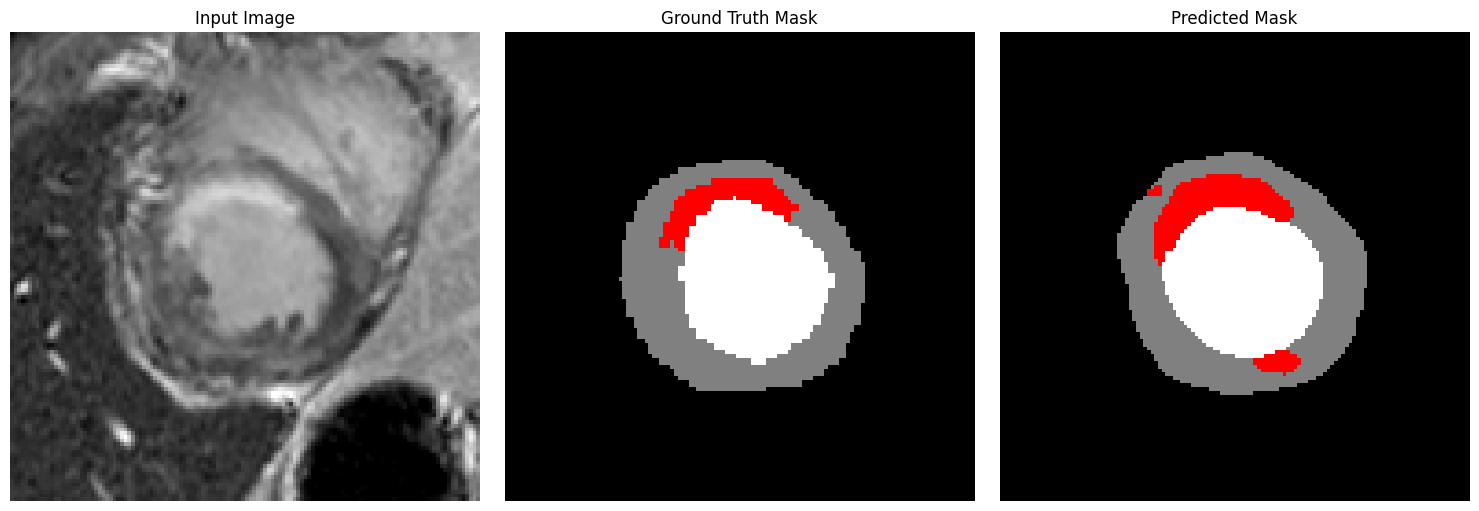


Per-class Dice scores:
  Class 0: Dice = 0.9788
  Class 1: Dice = 0.9116
  Class 2: Dice = 0.7764
  Class 3: Dice = 0.5371
  Class 4: Dice = 0.3405

Epoch 9: Mean Dice = 0.7089
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 216ms/step - loss: 0.6370 - sparse_categorical_accuracy: 0.9566 - val_loss: 1.0424 - val_sparse_categorical_accuracy: 0.9409
Epoch 10/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.6038 - sparse_categorical_accuracy: 0.9582Saved checkpoint: /content/drive/MyDrive/Original_Data_Only_Augmented_10000/ckpt/ckpt-epoch10.weights.h5
Generating predictions at epoch 10


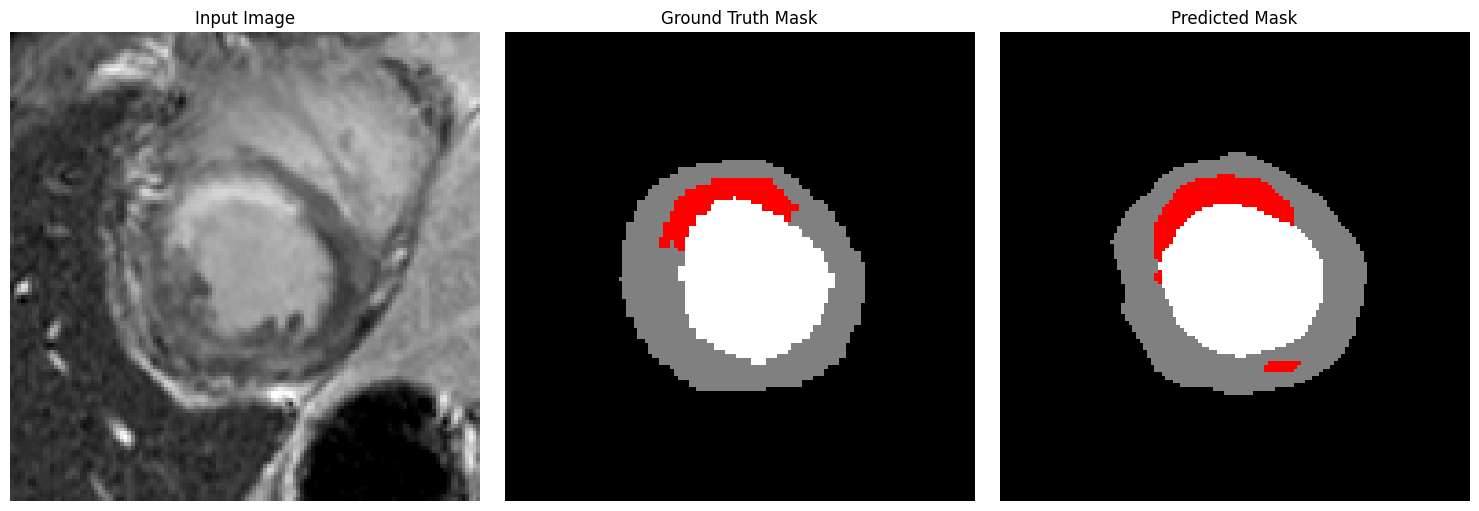


Per-class Dice scores:
  Class 0: Dice = 0.9809
  Class 1: Dice = 0.9169
  Class 2: Dice = 0.7878
  Class 3: Dice = 0.5643
  Class 4: Dice = 0.3775

Epoch 10: Mean Dice = 0.7255
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 324s 218ms/step - loss: 0.6038 - sparse_categorical_accuracy: 0.9582 - val_loss: 0.9665 - val_sparse_categorical_accuracy: 0.9454
Epoch 11/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - loss: 0.5966 - sparse_categorical_accuracy: 0.9585Generating predictions at epoch 11


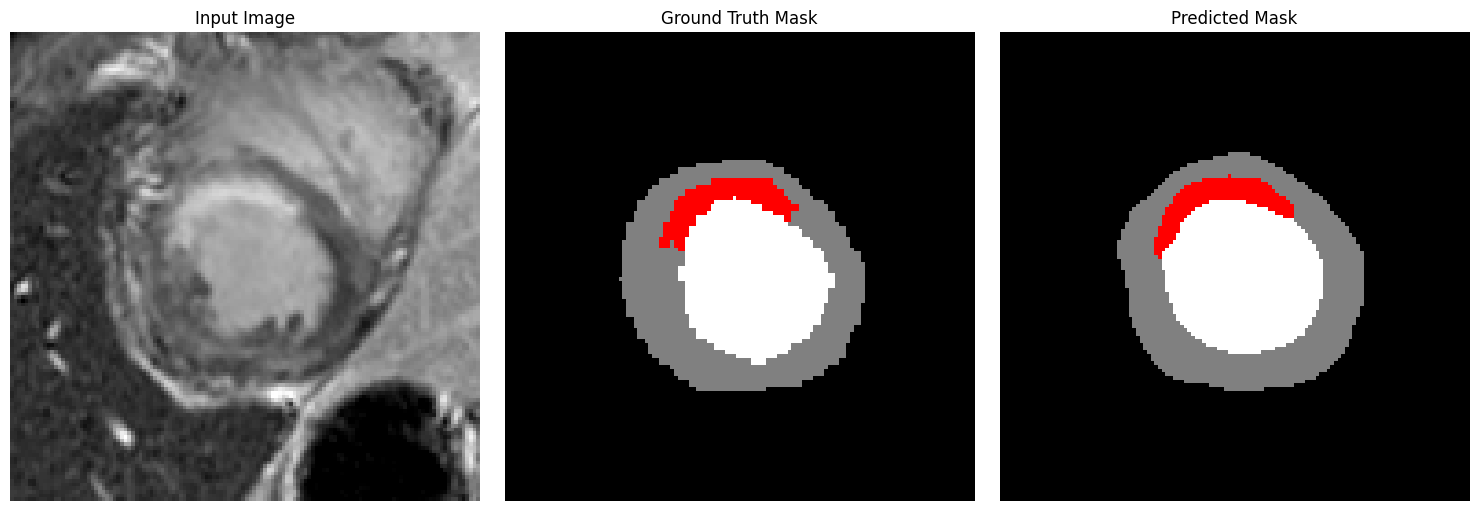


Per-class Dice scores:
  Class 0: Dice = 0.9835
  Class 1: Dice = 0.9193
  Class 2: Dice = 0.8054
  Class 3: Dice = 0.5874
  Class 4: Dice = 0.4407

Epoch 11: Mean Dice = 0.7473
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 320s 216ms/step - loss: 0.5966 - sparse_categorical_accuracy: 0.9585 - val_loss: 1.1893 - val_sparse_categorical_accuracy: 0.9521
Epoch 12/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.5563 - sparse_categorical_accuracy: 0.9611Generating predictions at epoch 12


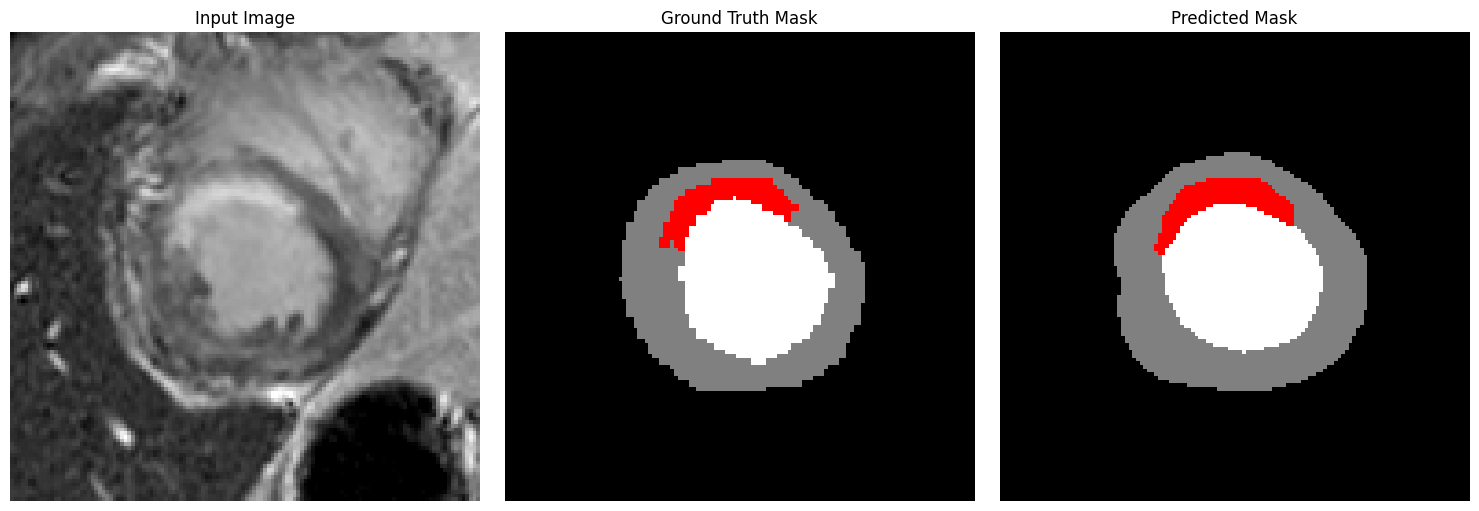


Per-class Dice scores:
  Class 0: Dice = 0.9805
  Class 1: Dice = 0.9181
  Class 2: Dice = 0.7945
  Class 3: Dice = 0.6022
  Class 4: Dice = 0.4649

Epoch 12: Mean Dice = 0.7521
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 217ms/step - loss: 0.5563 - sparse_categorical_accuracy: 0.9611 - val_loss: 1.0456 - val_sparse_categorical_accuracy: 0.9477
Epoch 13/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.5242 - sparse_categorical_accuracy: 0.9628Generating predictions at epoch 13


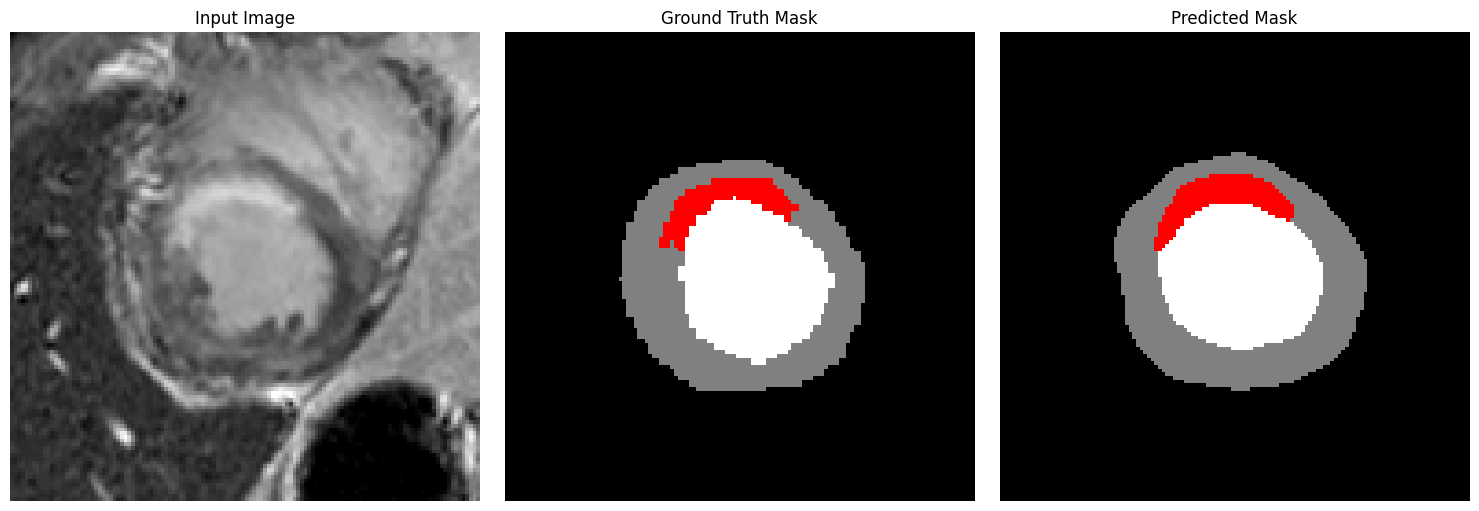


Per-class Dice scores:
  Class 0: Dice = 0.9850
  Class 1: Dice = 0.9180
  Class 2: Dice = 0.8122
  Class 3: Dice = 0.6101
  Class 4: Dice = 0.4874

Epoch 13: Mean Dice = 0.7626
✅ New best Dice score! Model saved to /content/drive/MyDrive/Original_Data_Only_Augmented_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 283s 226ms/step - loss: 0.5242 - sparse_categorical_accuracy: 0.9628 - val_loss: 1.1092 - val_sparse_categorical_accuracy: 0.9541
Epoch 14/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.4966 - sparse_categorical_accuracy: 0.9645Generating predictions at epoch 14


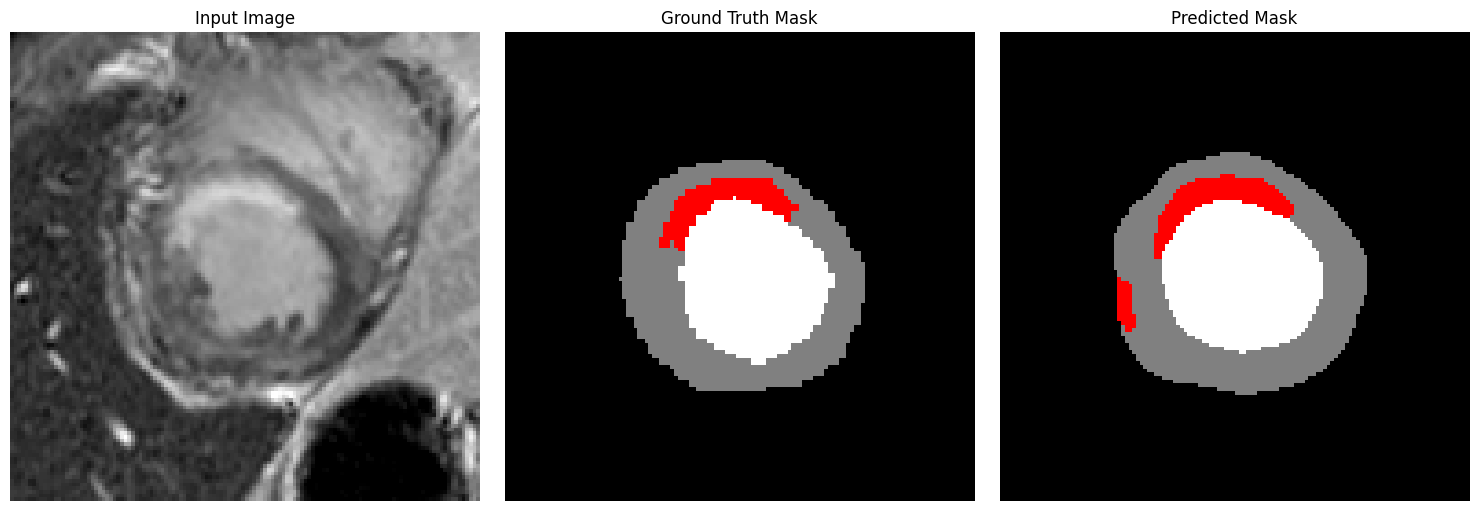


Per-class Dice scores:
  Class 0: Dice = 0.9791
  Class 1: Dice = 0.9233
  Class 2: Dice = 0.7903
  Class 3: Dice = 0.5580
  Class 4: Dice = 0.5257

Epoch 14: Mean Dice = 0.7553
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 311s 217ms/step - loss: 0.4966 - sparse_categorical_accuracy: 0.9645 - val_loss: 1.0889 - val_sparse_categorical_accuracy: 0.9455
Epoch 15/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.4800 - sparse_categorical_accuracy: 0.9656Generating predictions at epoch 15


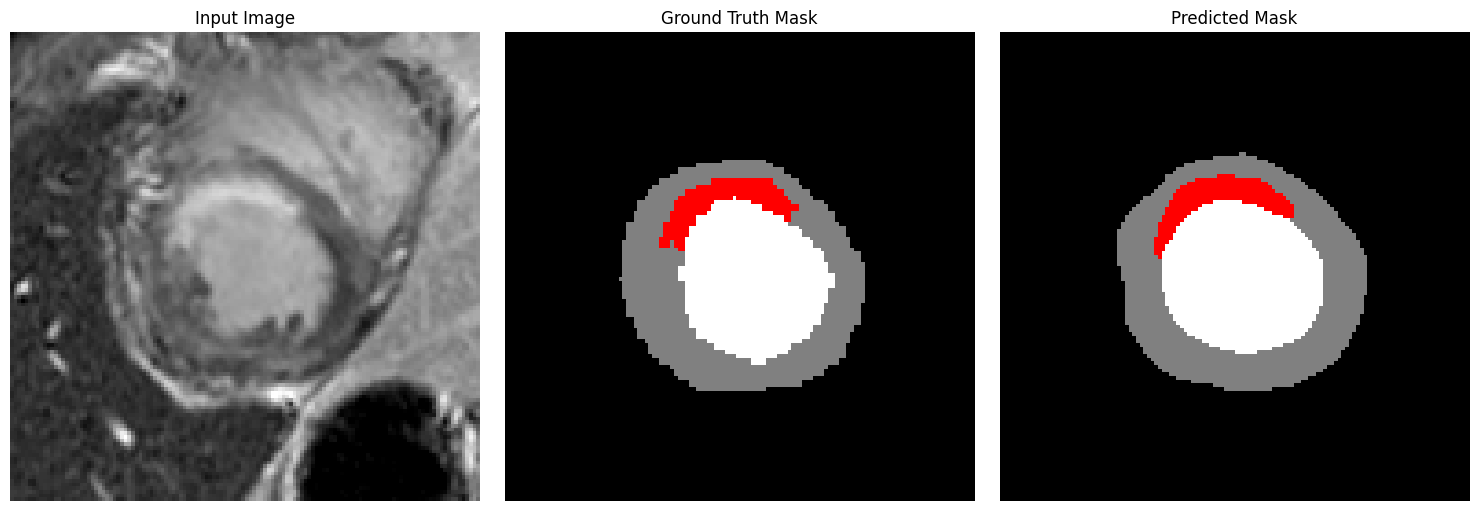


Per-class Dice scores:
  Class 0: Dice = 0.9818
  Class 1: Dice = 0.9217
  Class 2: Dice = 0.7980
  Class 3: Dice = 0.6084
  Class 4: Dice = 0.4343

Epoch 15: Mean Dice = 0.7488
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 271s 217ms/step - loss: 0.4800 - sparse_categorical_accuracy: 0.9656 - val_loss: 1.1591 - val_sparse_categorical_accuracy: 0.9501
Epoch 16/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.4533 - sparse_categorical_accuracy: 0.9669Generating predictions at epoch 16


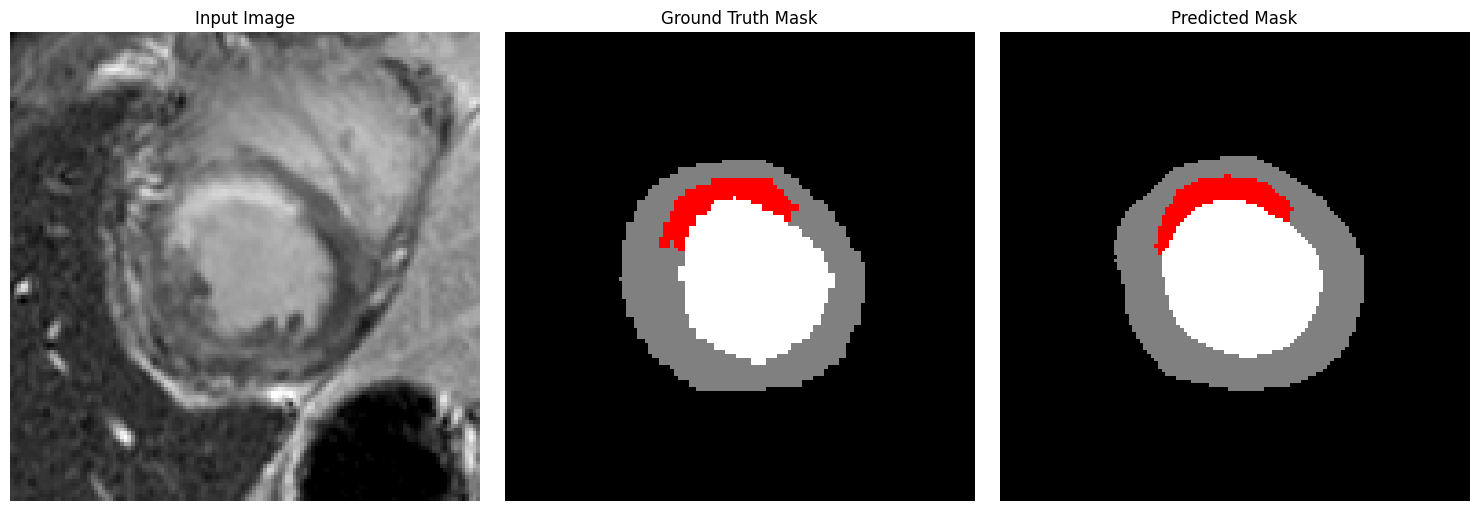


Per-class Dice scores:
  Class 0: Dice = 0.9842
  Class 1: Dice = 0.9176
  Class 2: Dice = 0.8094
  Class 3: Dice = 0.5863
  Class 4: Dice = 0.4753

Epoch 16: Mean Dice = 0.7546
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 217ms/step - loss: 0.4534 - sparse_categorical_accuracy: 0.9669 - val_loss: 1.3119 - val_sparse_categorical_accuracy: 0.9531
Epoch 17/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.4417 - sparse_categorical_accuracy: 0.9675Generating predictions at epoch 17


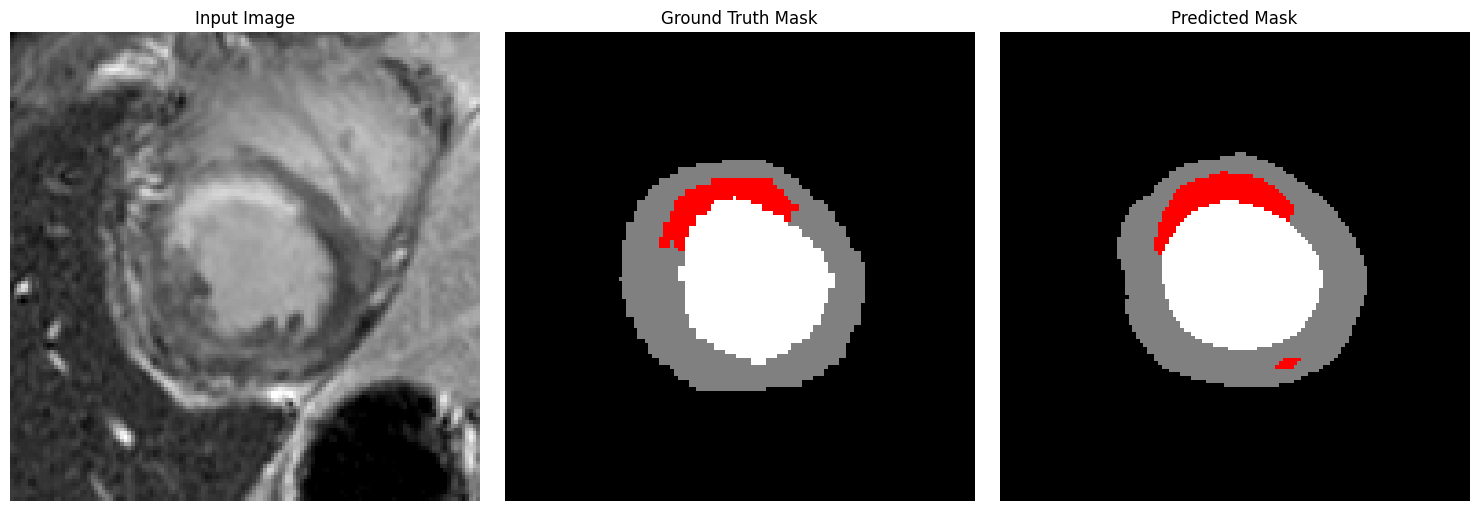


Per-class Dice scores:
  Class 0: Dice = 0.9839
  Class 1: Dice = 0.9242
  Class 2: Dice = 0.8086
  Class 3: Dice = 0.6167
  Class 4: Dice = 0.4006

Epoch 17: Mean Dice = 0.7468
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 270s 216ms/step - loss: 0.4417 - sparse_categorical_accuracy: 0.9675 - val_loss: 1.1922 - val_sparse_categorical_accuracy: 0.9534
Epoch 18/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.4329 - sparse_categorical_accuracy: 0.9684Generating predictions at epoch 18


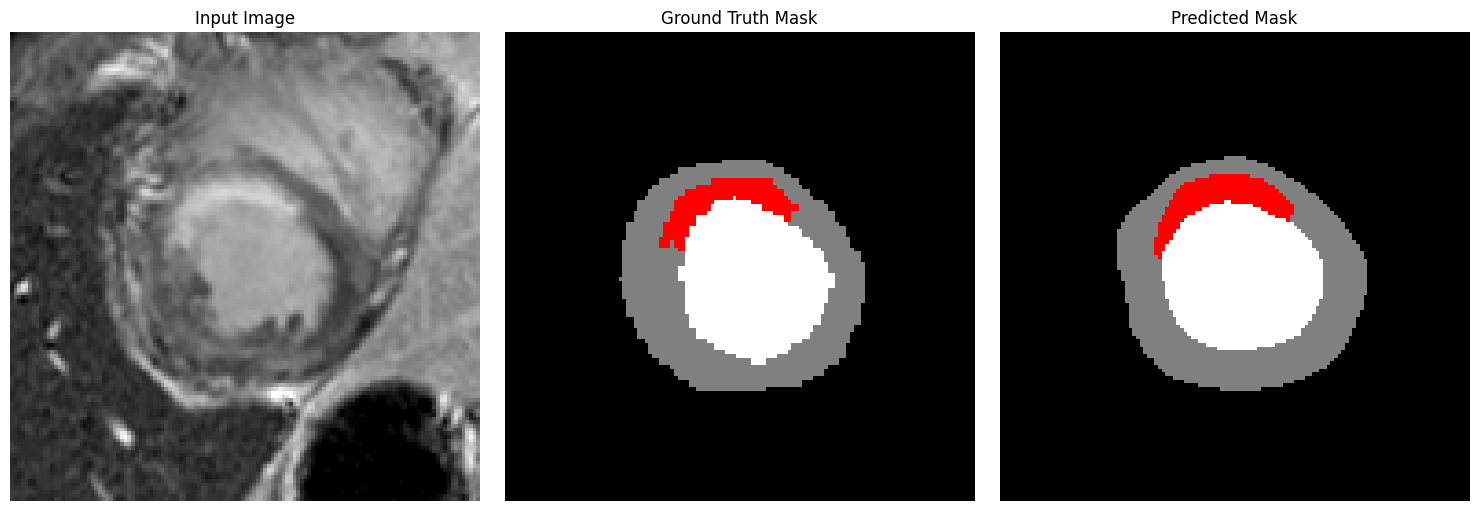


Per-class Dice scores:
  Class 0: Dice = 0.9837
  Class 1: Dice = 0.9262
  Class 2: Dice = 0.8087
  Class 3: Dice = 0.6015
  Class 4: Dice = 0.4730

Epoch 18: Mean Dice = 0.7586
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 323s 217ms/step - loss: 0.4329 - sparse_categorical_accuracy: 0.9684 - val_loss: 1.2515 - val_sparse_categorical_accuracy: 0.9535
Epoch 19/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.4046 - sparse_categorical_accuracy: 0.9701Generating predictions at epoch 19


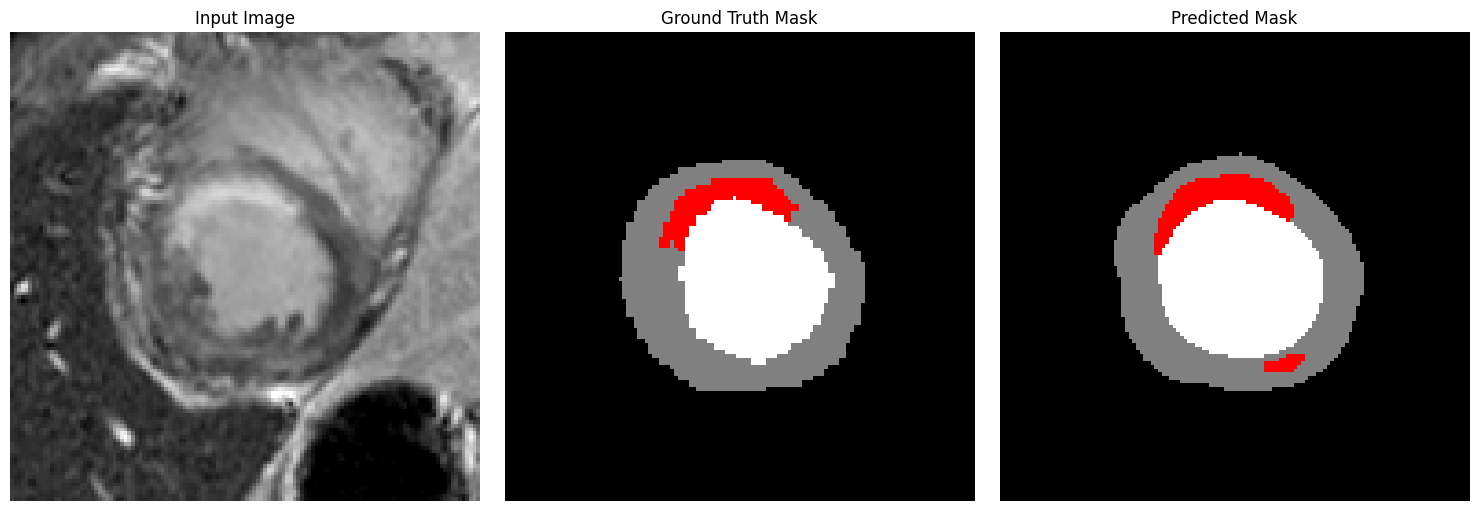


Per-class Dice scores:
  Class 0: Dice = 0.9844
  Class 1: Dice = 0.9279
  Class 2: Dice = 0.8073
  Class 3: Dice = 0.6075
  Class 4: Dice = 0.4980

Epoch 19: Mean Dice = 0.7650
✅ New best Dice score! Model saved to /content/drive/MyDrive/Original_Data_Only_Augmented_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 343s 233ms/step - loss: 0.4046 - sparse_categorical_accuracy: 0.9701 - val_loss: 1.2326 - val_sparse_categorical_accuracy: 0.9544
Epoch 20/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.3991 - sparse_categorical_accuracy: 0.9704Saved checkpoint: /content/drive/MyDrive/Original_Data_Only_Augmented_10000/ckpt/ckpt-epoch20.weights.h5
Generating predictions at epoch 20


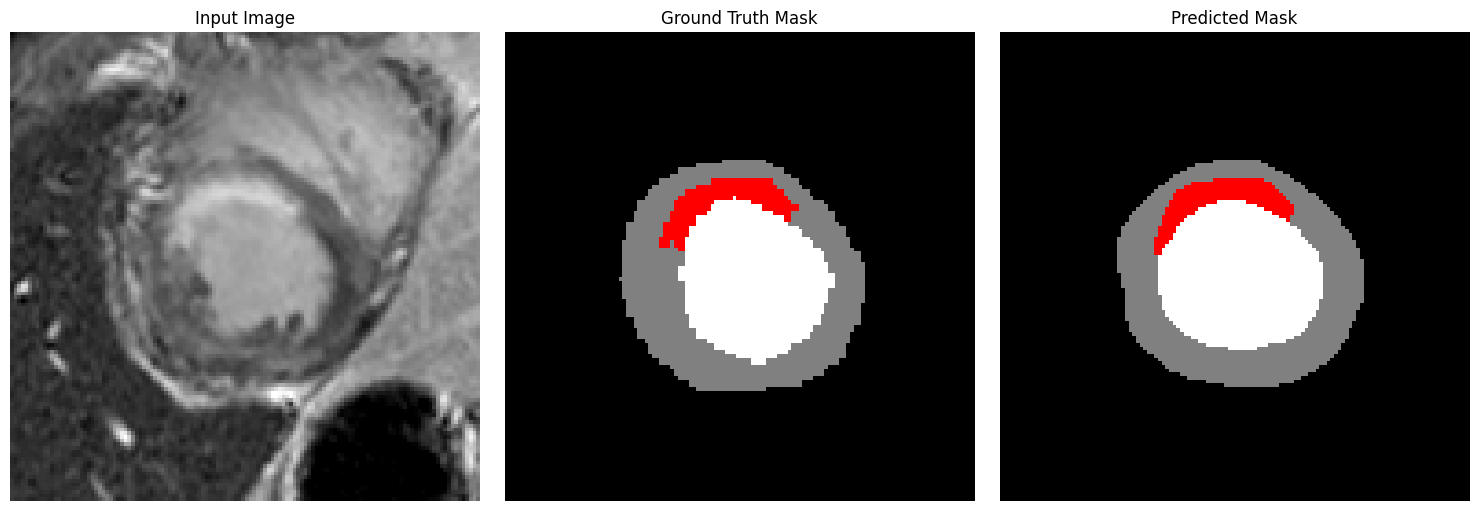


Per-class Dice scores:
  Class 0: Dice = 0.9857
  Class 1: Dice = 0.9282
  Class 2: Dice = 0.8199
  Class 3: Dice = 0.6273
  Class 4: Dice = 0.4881

Epoch 20: Mean Dice = 0.7698
✅ New best Dice score! Model saved to /content/drive/MyDrive/Original_Data_Only_Augmented_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 317s 229ms/step - loss: 0.3991 - sparse_categorical_accuracy: 0.9704 - val_loss: 1.3231 - val_sparse_categorical_accuracy: 0.9577
Epoch 21/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - loss: 0.3824 - sparse_categorical_accuracy: 0.9718Generating predictions at epoch 21


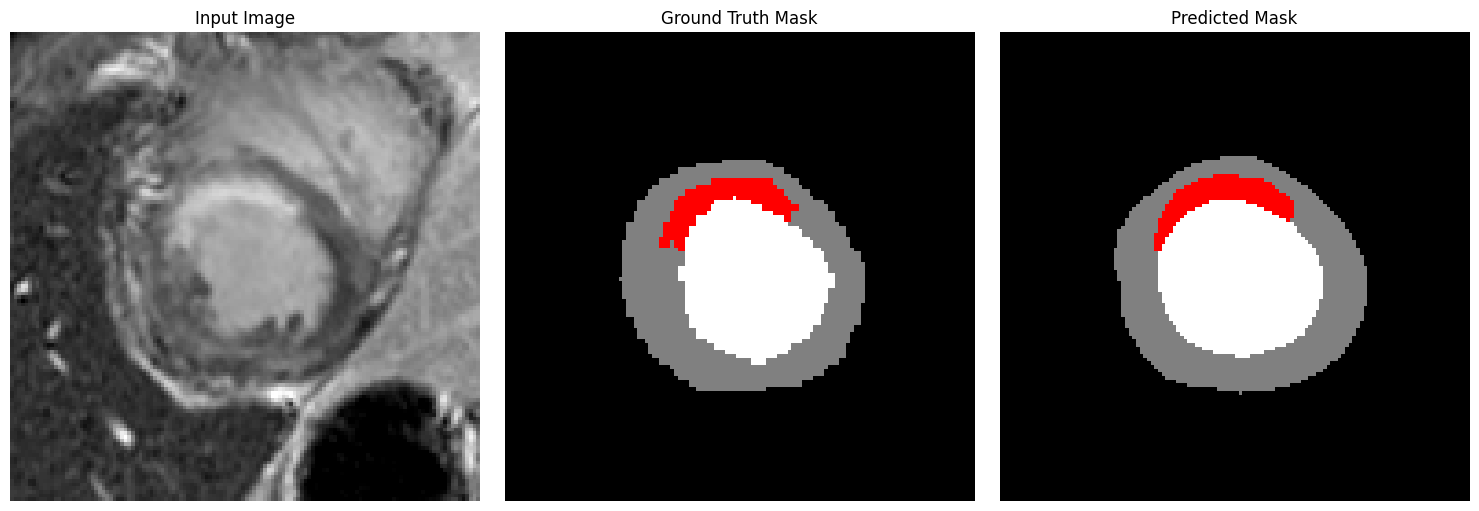


Per-class Dice scores:
  Class 0: Dice = 0.9833
  Class 1: Dice = 0.9285
  Class 2: Dice = 0.8062
  Class 3: Dice = 0.6195
  Class 4: Dice = 0.4886

Epoch 21: Mean Dice = 0.7652
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 273s 218ms/step - loss: 0.3824 - sparse_categorical_accuracy: 0.9718 - val_loss: 1.3528 - val_sparse_categorical_accuracy: 0.9537
Epoch 22/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.3767 - sparse_categorical_accuracy: 0.9722Generating predictions at epoch 22


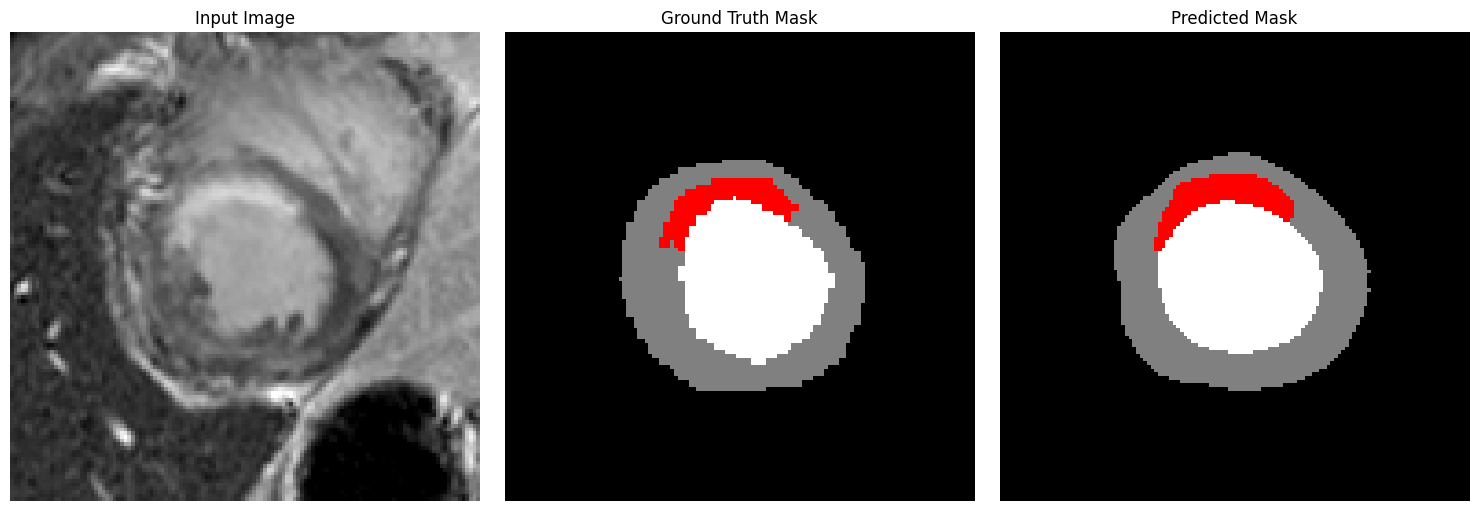


Per-class Dice scores:
  Class 0: Dice = 0.9830
  Class 1: Dice = 0.9267
  Class 2: Dice = 0.8015
  Class 3: Dice = 0.6108
  Class 4: Dice = 0.4476

Epoch 22: Mean Dice = 0.7539
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 320s 217ms/step - loss: 0.3767 - sparse_categorical_accuracy: 0.9722 - val_loss: 1.3153 - val_sparse_categorical_accuracy: 0.9522
Epoch 23/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.3606 - sparse_categorical_accuracy: 0.9730Generating predictions at epoch 23


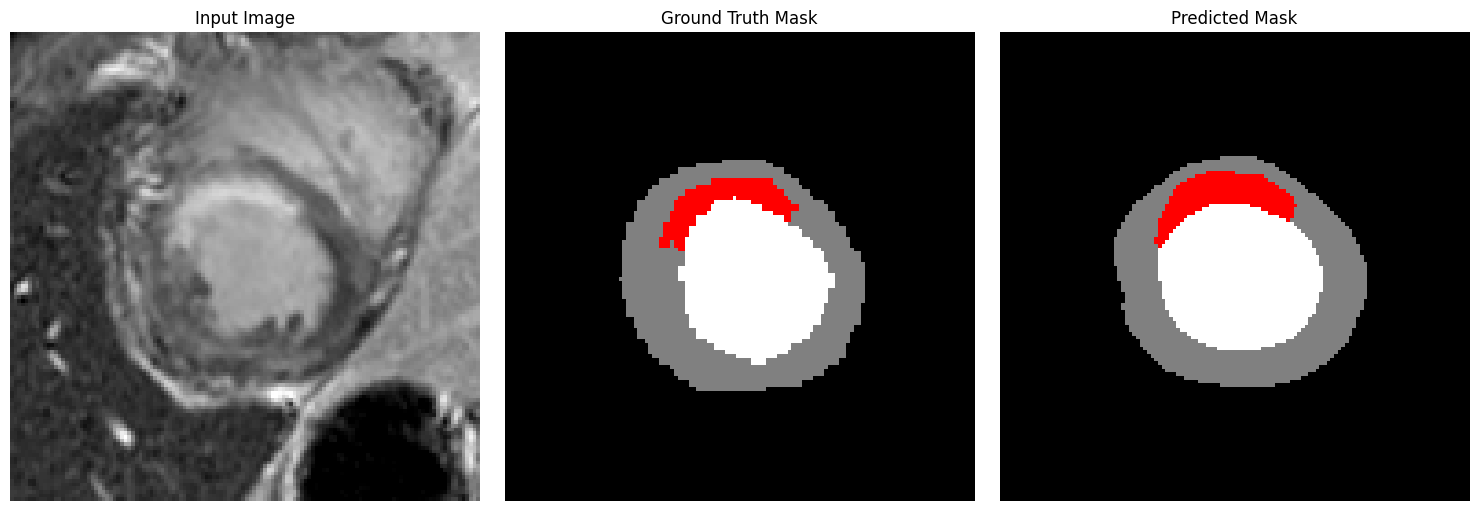


Per-class Dice scores:
  Class 0: Dice = 0.9844
  Class 1: Dice = 0.9222
  Class 2: Dice = 0.8144
  Class 3: Dice = 0.5885
  Class 4: Dice = 0.3899

Epoch 23: Mean Dice = 0.7399
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 323s 217ms/step - loss: 0.3606 - sparse_categorical_accuracy: 0.9730 - val_loss: 1.5384 - val_sparse_categorical_accuracy: 0.9543
Epoch 24/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - loss: 0.3435 - sparse_categorical_accuracy: 0.9742Generating predictions at epoch 24


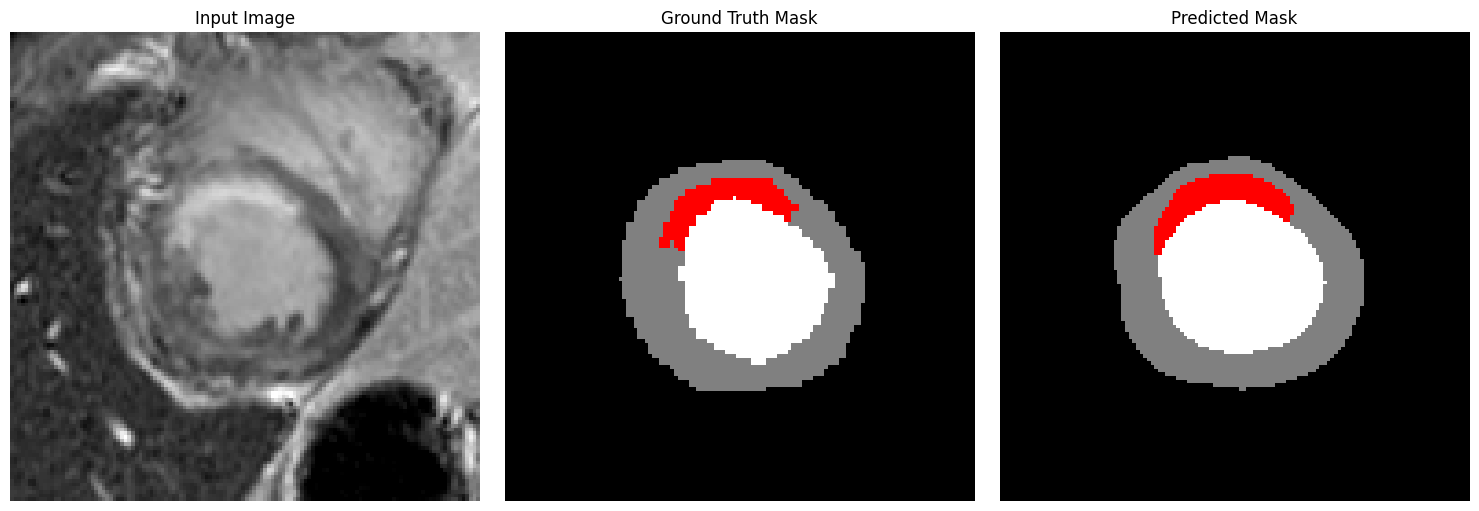


Per-class Dice scores:
  Class 0: Dice = 0.9857
  Class 1: Dice = 0.9244
  Class 2: Dice = 0.8217
  Class 3: Dice = 0.6234
  Class 4: Dice = 0.4044

Epoch 24: Mean Dice = 0.7519
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 272s 218ms/step - loss: 0.3435 - sparse_categorical_accuracy: 0.9742 - val_loss: 1.4446 - val_sparse_categorical_accuracy: 0.9571
Epoch 25/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.3394 - sparse_categorical_accuracy: 0.9747Generating predictions at epoch 25


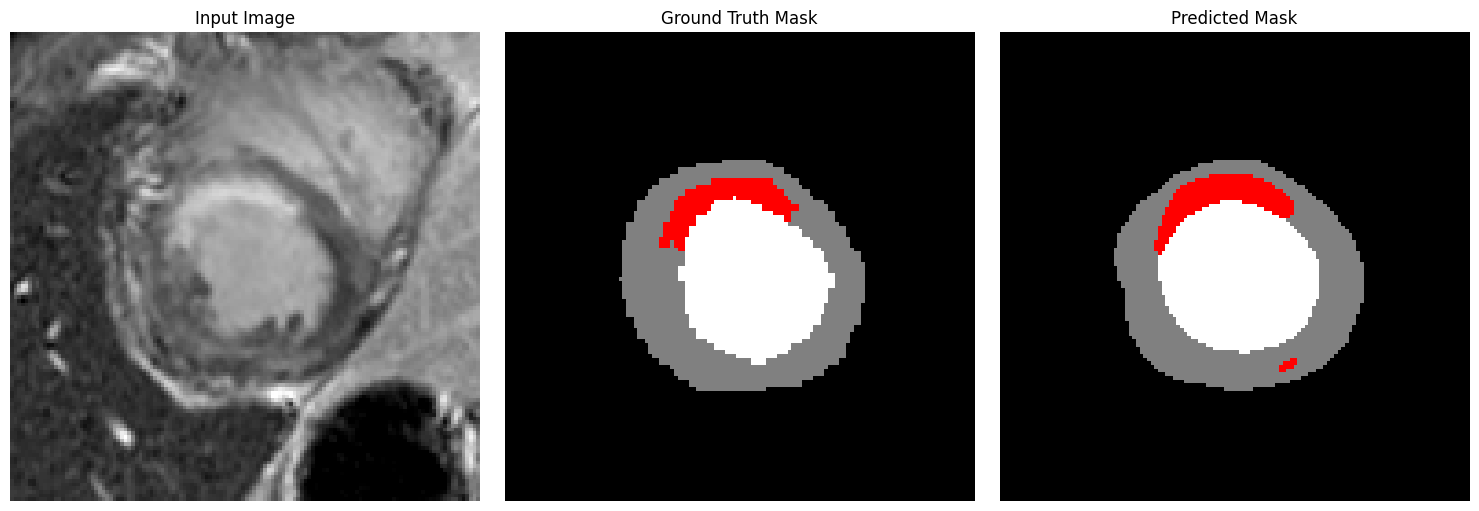


Per-class Dice scores:
  Class 0: Dice = 0.9861
  Class 1: Dice = 0.9263
  Class 2: Dice = 0.8218
  Class 3: Dice = 0.6242
  Class 4: Dice = 0.4637

Epoch 25: Mean Dice = 0.7644
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 217ms/step - loss: 0.3394 - sparse_categorical_accuracy: 0.9747 - val_loss: 1.5386 - val_sparse_categorical_accuracy: 0.9579
Epoch 26/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.3278 - sparse_categorical_accuracy: 0.9753Generating predictions at epoch 26


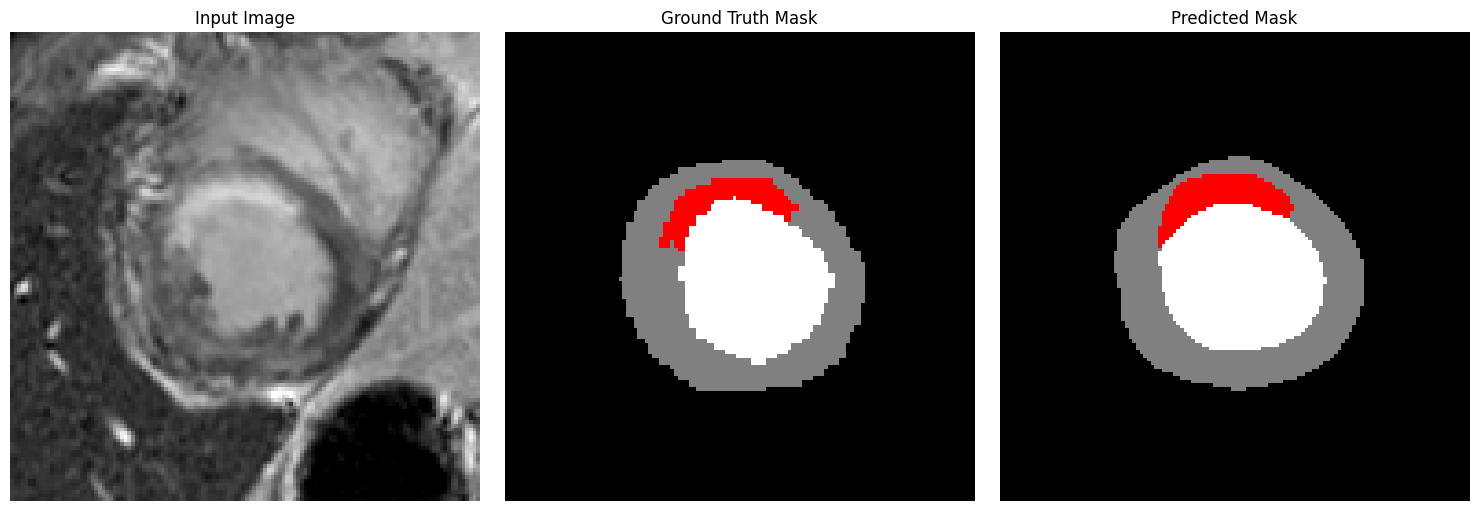


Per-class Dice scores:
  Class 0: Dice = 0.9869
  Class 1: Dice = 0.9260
  Class 2: Dice = 0.8282
  Class 3: Dice = 0.6367
  Class 4: Dice = 0.4606

Epoch 26: Mean Dice = 0.7677
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 217ms/step - loss: 0.3278 - sparse_categorical_accuracy: 0.9753 - val_loss: 1.4546 - val_sparse_categorical_accuracy: 0.9594
Epoch 27/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.3418 - sparse_categorical_accuracy: 0.9748Generating predictions at epoch 27


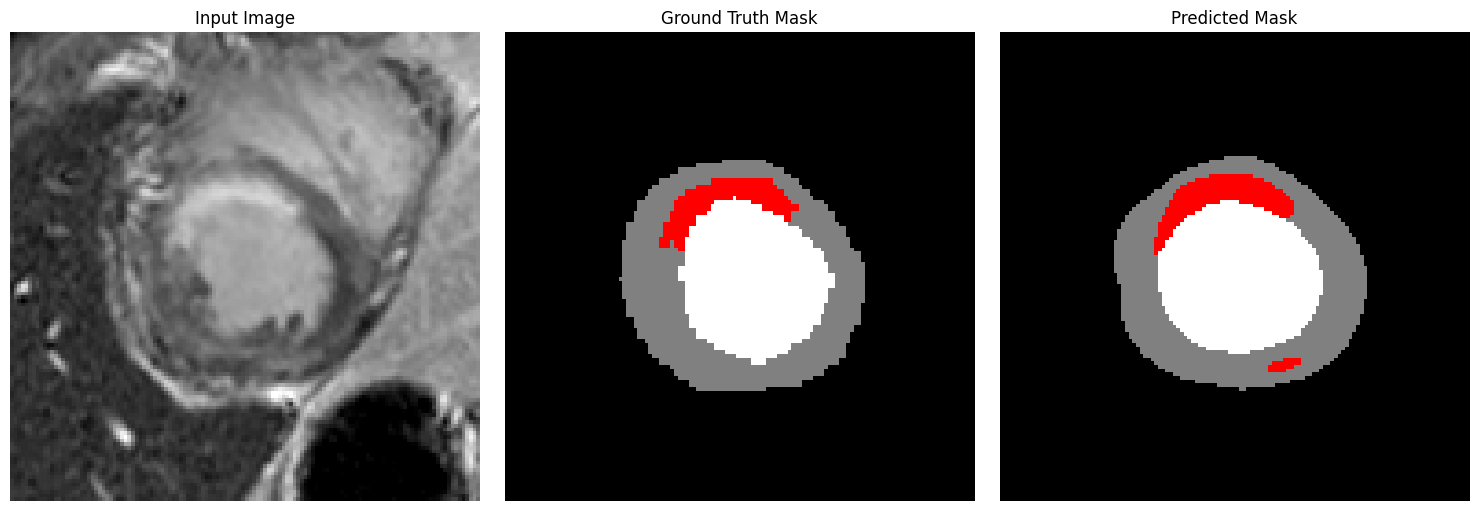


Per-class Dice scores:
  Class 0: Dice = 0.9860
  Class 1: Dice = 0.9283
  Class 2: Dice = 0.8201
  Class 3: Dice = 0.6250
  Class 4: Dice = 0.4231

Epoch 27: Mean Dice = 0.7565
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 217ms/step - loss: 0.3418 - sparse_categorical_accuracy: 0.9748 - val_loss: 1.4945 - val_sparse_categorical_accuracy: 0.9576
Epoch 28/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.3158 - sparse_categorical_accuracy: 0.9764Generating predictions at epoch 28


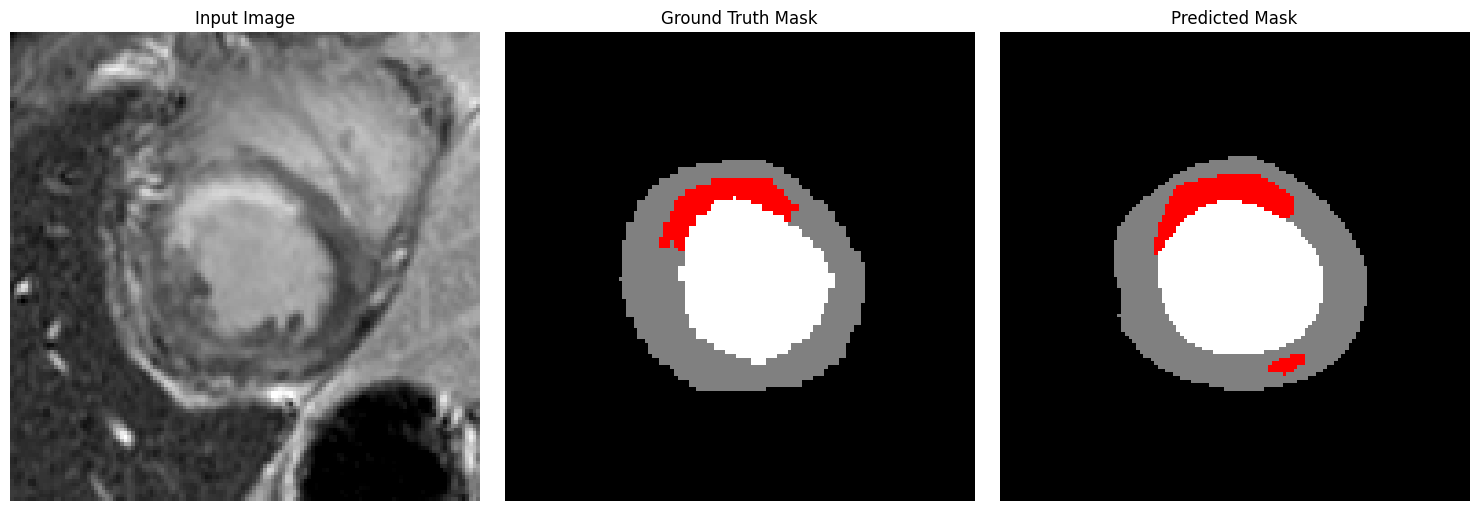


Per-class Dice scores:
  Class 0: Dice = 0.9854
  Class 1: Dice = 0.9305
  Class 2: Dice = 0.8143
  Class 3: Dice = 0.6256
  Class 4: Dice = 0.3850

Epoch 28: Mean Dice = 0.7481
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 271s 217ms/step - loss: 0.3158 - sparse_categorical_accuracy: 0.9764 - val_loss: 1.4503 - val_sparse_categorical_accuracy: 0.9564
Epoch 29/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.3115 - sparse_categorical_accuracy: 0.9766Generating predictions at epoch 29


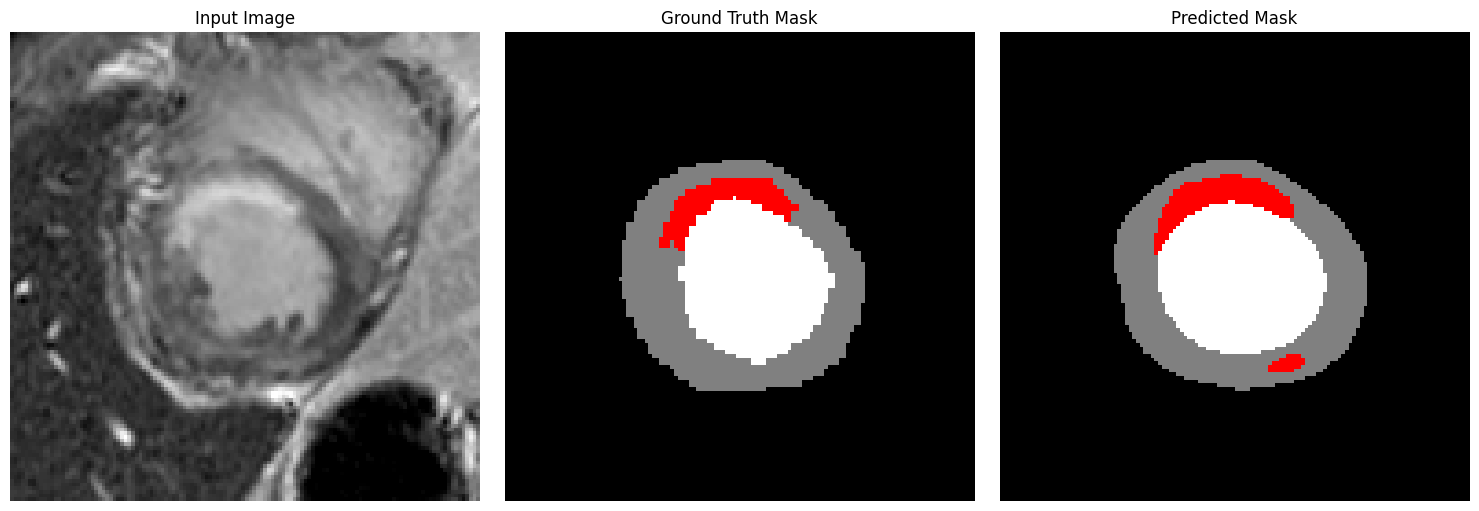


Per-class Dice scores:
  Class 0: Dice = 0.9851
  Class 1: Dice = 0.9249
  Class 2: Dice = 0.8126
  Class 3: Dice = 0.6217
  Class 4: Dice = 0.4975

Epoch 29: Mean Dice = 0.7684
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 217ms/step - loss: 0.3115 - sparse_categorical_accuracy: 0.9766 - val_loss: 1.4878 - val_sparse_categorical_accuracy: 0.9558
Epoch 30/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.3095 - sparse_categorical_accuracy: 0.9768Saved checkpoint: /content/drive/MyDrive/Original_Data_Only_Augmented_10000/ckpt/ckpt-epoch30.weights.h5
Generating predictions at epoch 30


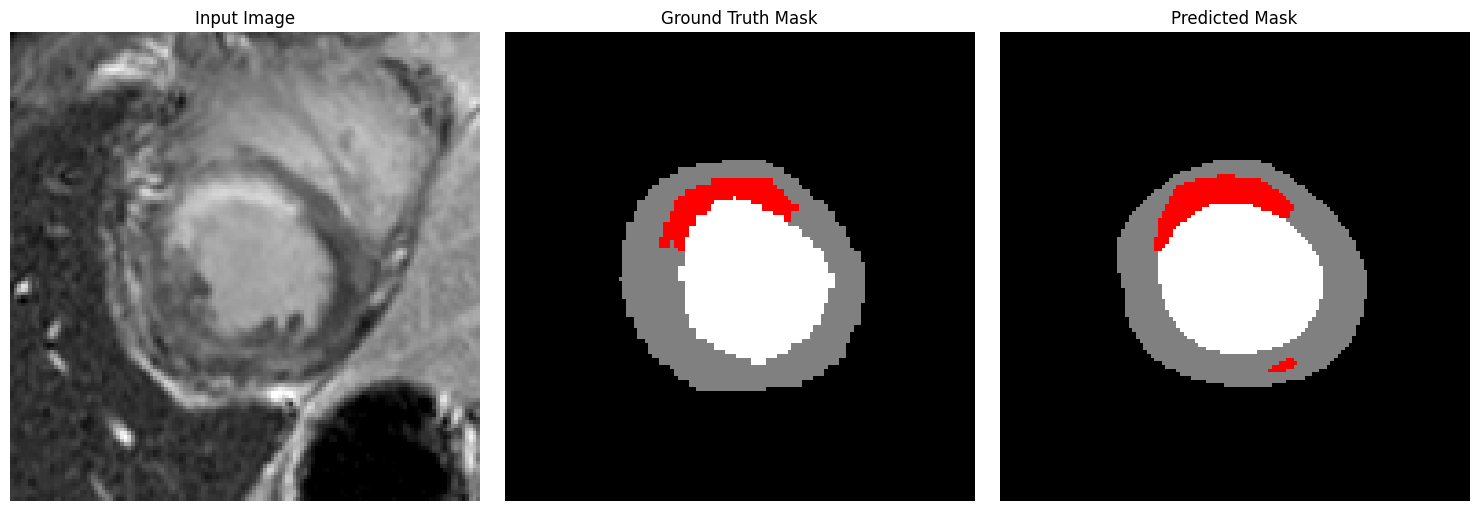


Per-class Dice scores:
  Class 0: Dice = 0.9861
  Class 1: Dice = 0.9269
  Class 2: Dice = 0.8203
  Class 3: Dice = 0.6345
  Class 4: Dice = 0.4399

Epoch 30: Mean Dice = 0.7616
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 276s 221ms/step - loss: 0.3095 - sparse_categorical_accuracy: 0.9768 - val_loss: 1.6092 - val_sparse_categorical_accuracy: 0.9580
Epoch 31/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.3004 - sparse_categorical_accuracy: 0.9773Generating predictions at epoch 31


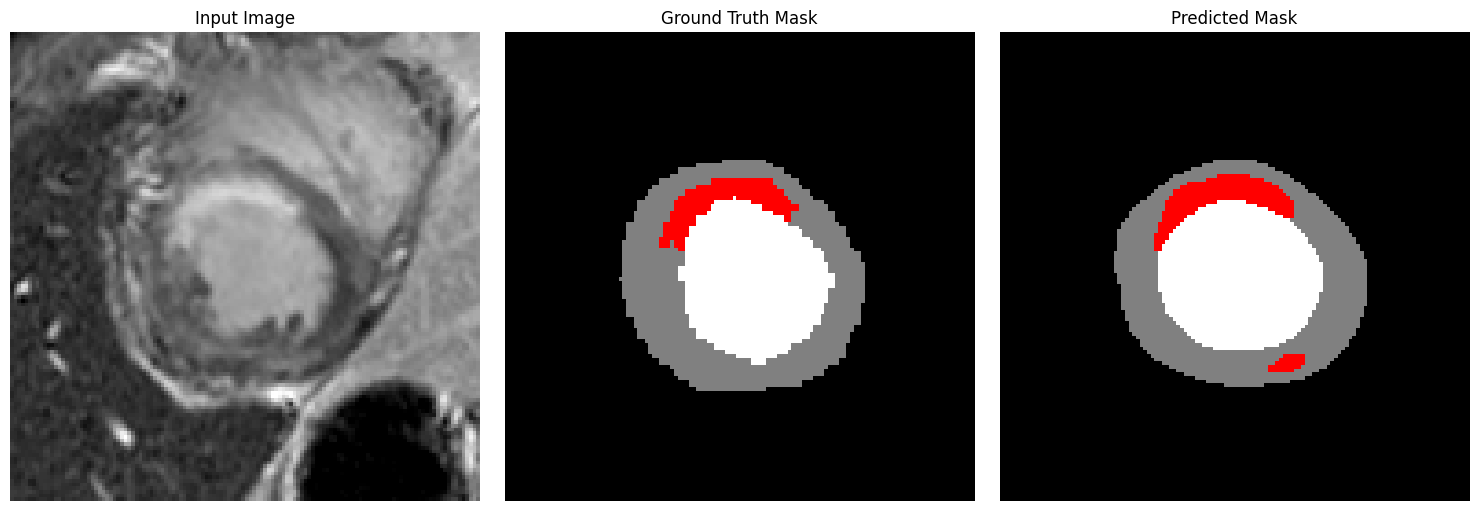


Per-class Dice scores:
  Class 0: Dice = 0.9850
  Class 1: Dice = 0.9234
  Class 2: Dice = 0.8188
  Class 3: Dice = 0.6235
  Class 4: Dice = 0.4788

Epoch 31: Mean Dice = 0.7659
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 317s 216ms/step - loss: 0.3004 - sparse_categorical_accuracy: 0.9773 - val_loss: 1.6144 - val_sparse_categorical_accuracy: 0.9564
Epoch 32/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.3028 - sparse_categorical_accuracy: 0.9770Generating predictions at epoch 32


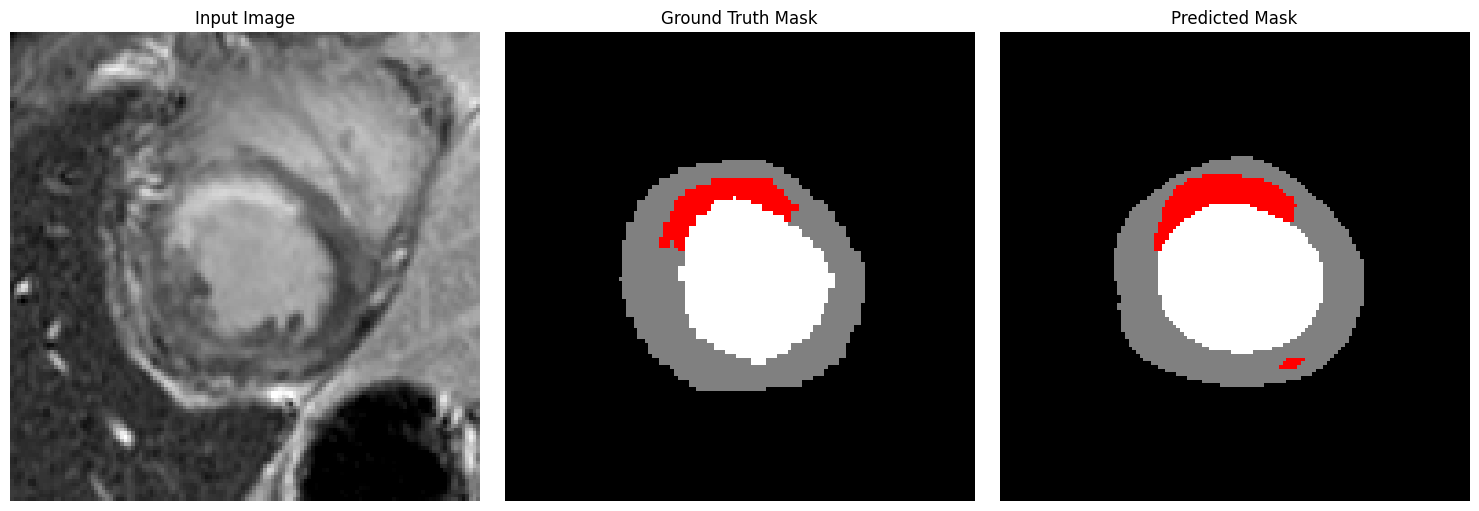


Per-class Dice scores:
  Class 0: Dice = 0.9855
  Class 1: Dice = 0.9240
  Class 2: Dice = 0.8146
  Class 3: Dice = 0.6124
  Class 4: Dice = 0.3559

Epoch 32: Mean Dice = 0.7385
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 216ms/step - loss: 0.3028 - sparse_categorical_accuracy: 0.9770 - val_loss: 1.6552 - val_sparse_categorical_accuracy: 0.9556
Epoch 33/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.2892 - sparse_categorical_accuracy: 0.9780Generating predictions at epoch 33


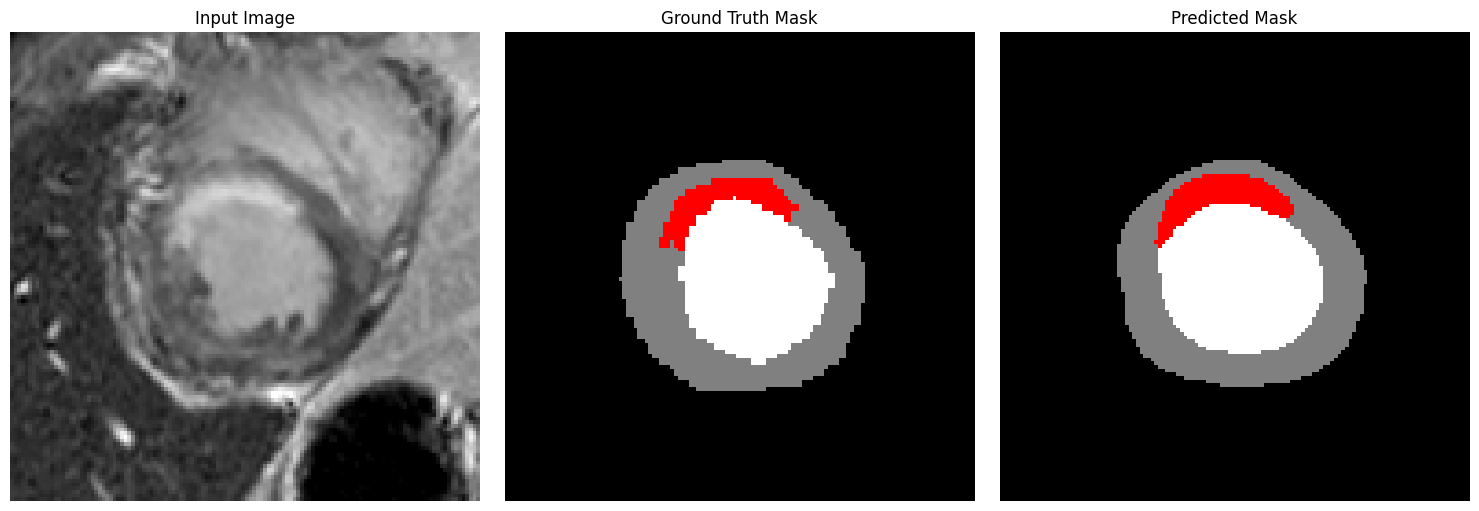


Per-class Dice scores:
  Class 0: Dice = 0.9859
  Class 1: Dice = 0.9262
  Class 2: Dice = 0.8209
  Class 3: Dice = 0.6290
  Class 4: Dice = 0.4587

Epoch 33: Mean Dice = 0.7641
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 323s 217ms/step - loss: 0.2892 - sparse_categorical_accuracy: 0.9780 - val_loss: 1.6122 - val_sparse_categorical_accuracy: 0.9576
Epoch 34/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.2881 - sparse_categorical_accuracy: 0.9782Generating predictions at epoch 34


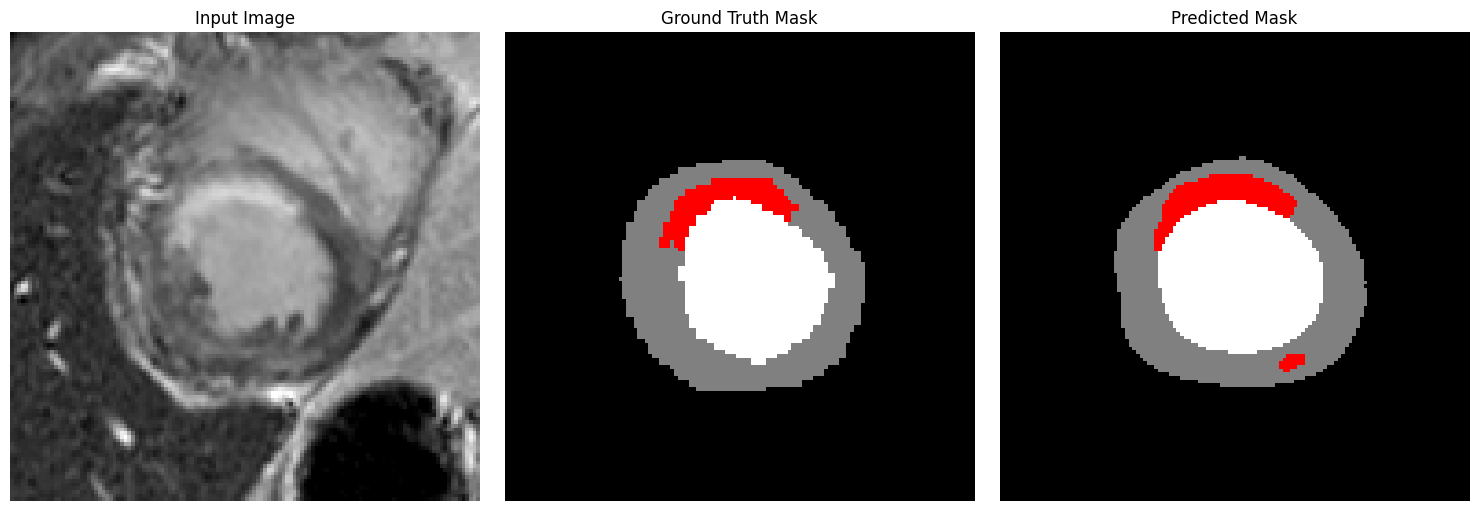


Per-class Dice scores:
  Class 0: Dice = 0.9855
  Class 1: Dice = 0.9276
  Class 2: Dice = 0.8168
  Class 3: Dice = 0.6272
  Class 4: Dice = 0.4603

Epoch 34: Mean Dice = 0.7635
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 217ms/step - loss: 0.2881 - sparse_categorical_accuracy: 0.9782 - val_loss: 1.6538 - val_sparse_categorical_accuracy: 0.9570
Epoch 35/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.2794 - sparse_categorical_accuracy: 0.9787Generating predictions at epoch 35


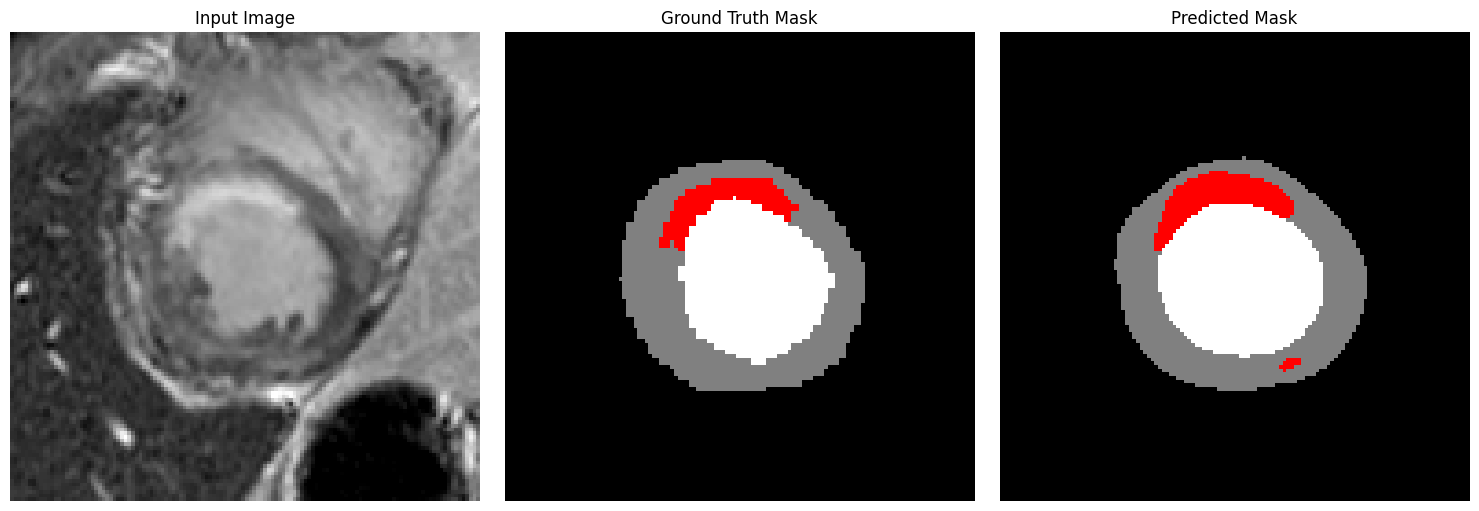


Per-class Dice scores:
  Class 0: Dice = 0.9861
  Class 1: Dice = 0.9286
  Class 2: Dice = 0.8220
  Class 3: Dice = 0.6267
  Class 4: Dice = 0.4808

Epoch 35: Mean Dice = 0.7688
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 271s 217ms/step - loss: 0.2794 - sparse_categorical_accuracy: 0.9787 - val_loss: 1.7454 - val_sparse_categorical_accuracy: 0.9583
Epoch 36/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - loss: 0.2778 - sparse_categorical_accuracy: 0.9789Generating predictions at epoch 36


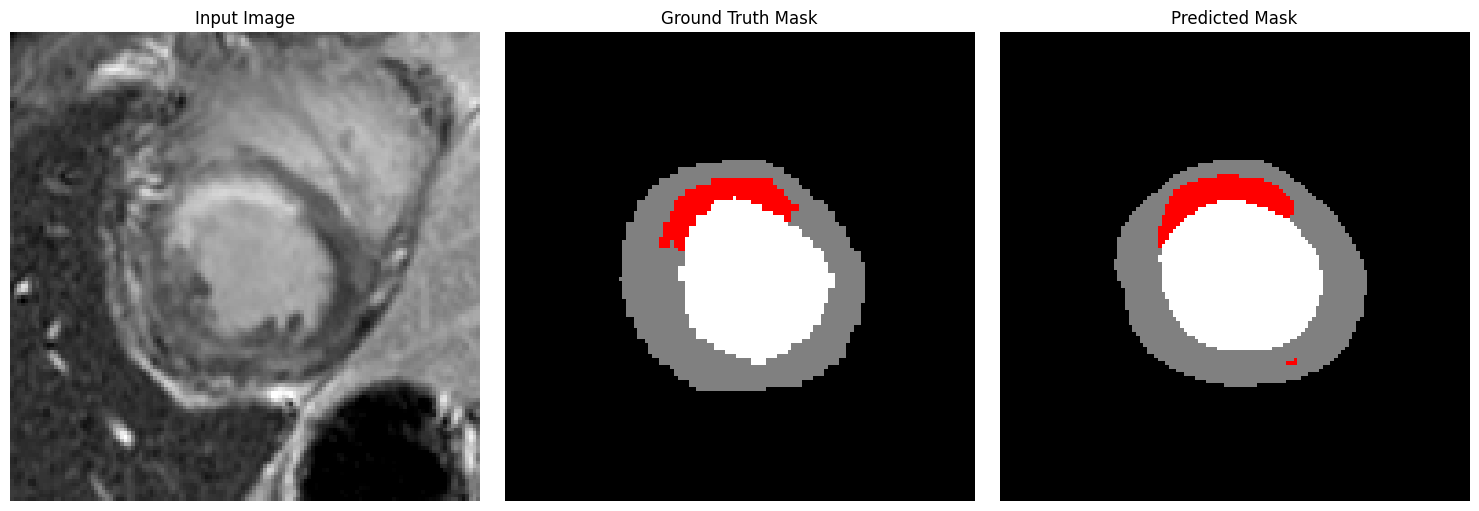


Per-class Dice scores:
  Class 0: Dice = 0.9867
  Class 1: Dice = 0.9292
  Class 2: Dice = 0.8250
  Class 3: Dice = 0.6358
  Class 4: Dice = 0.4505

Epoch 36: Mean Dice = 0.7654
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 270s 216ms/step - loss: 0.2778 - sparse_categorical_accuracy: 0.9789 - val_loss: 1.7893 - val_sparse_categorical_accuracy: 0.9595
Epoch 37/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.2690 - sparse_categorical_accuracy: 0.9795Generating predictions at epoch 37


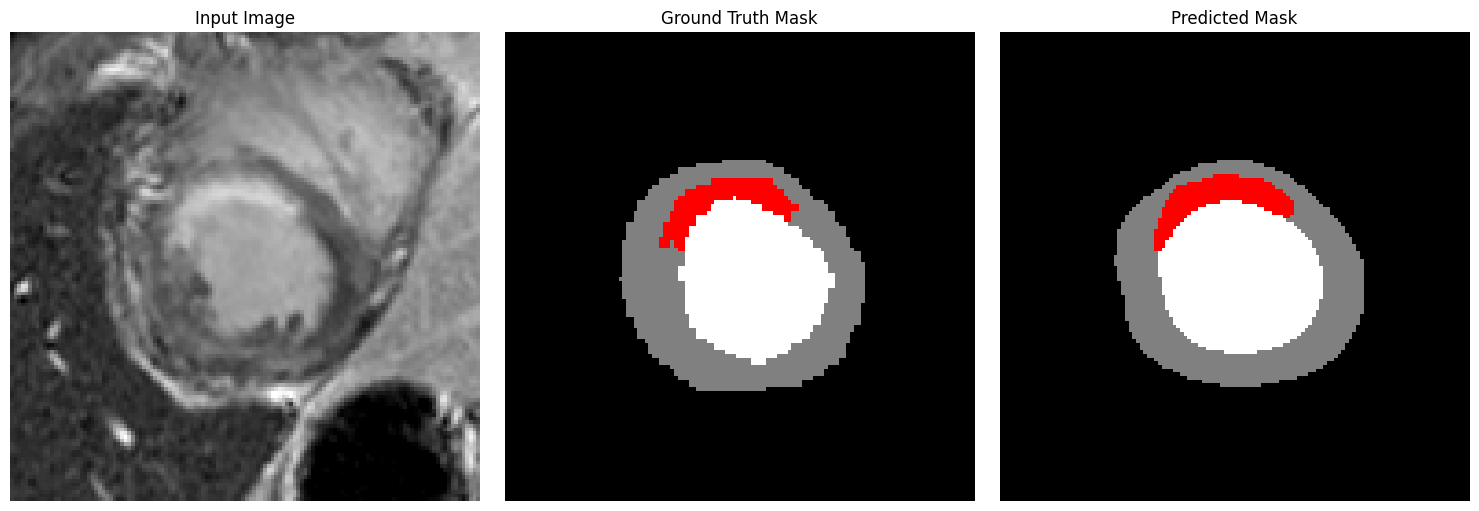


Per-class Dice scores:
  Class 0: Dice = 0.9868
  Class 1: Dice = 0.9255
  Class 2: Dice = 0.8261
  Class 3: Dice = 0.6257
  Class 4: Dice = 0.4352

Epoch 37: Mean Dice = 0.7599
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 323s 217ms/step - loss: 0.2690 - sparse_categorical_accuracy: 0.9795 - val_loss: 1.7942 - val_sparse_categorical_accuracy: 0.9589
Epoch 38/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - loss: 0.2704 - sparse_categorical_accuracy: 0.9794Generating predictions at epoch 38


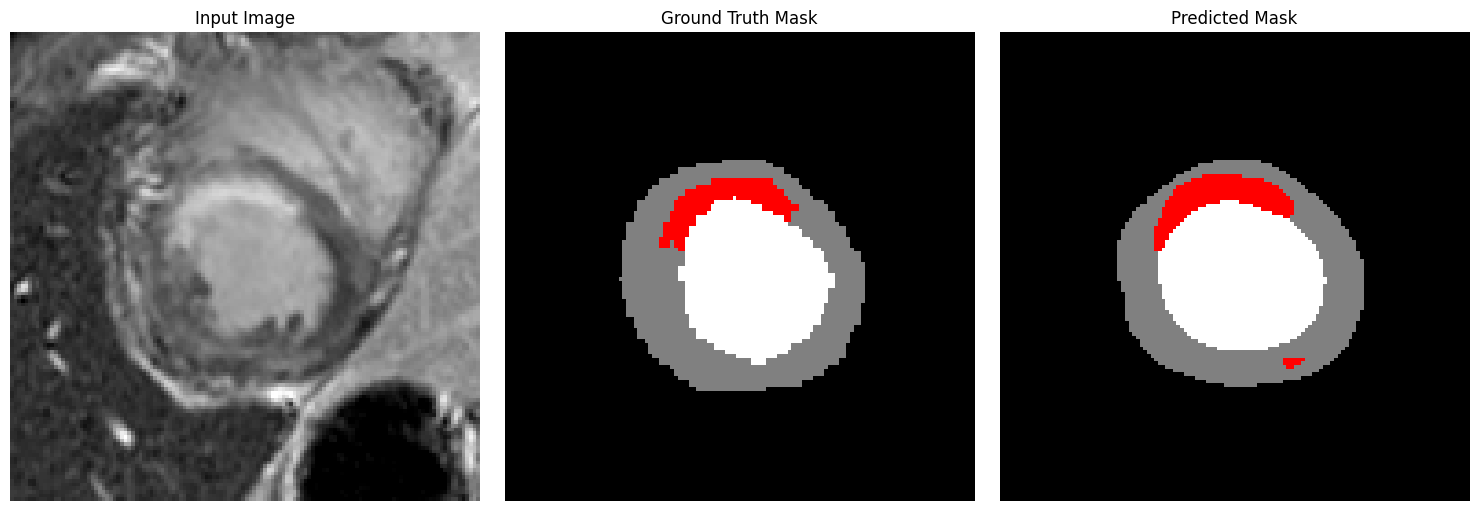


Per-class Dice scores:
  Class 0: Dice = 0.9859
  Class 1: Dice = 0.9288
  Class 2: Dice = 0.8167
  Class 3: Dice = 0.6132
  Class 4: Dice = 0.4288

Epoch 38: Mean Dice = 0.7547
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 270s 216ms/step - loss: 0.2704 - sparse_categorical_accuracy: 0.9794 - val_loss: 1.8415 - val_sparse_categorical_accuracy: 0.9574
Epoch 39/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.2646 - sparse_categorical_accuracy: 0.9797Generating predictions at epoch 39


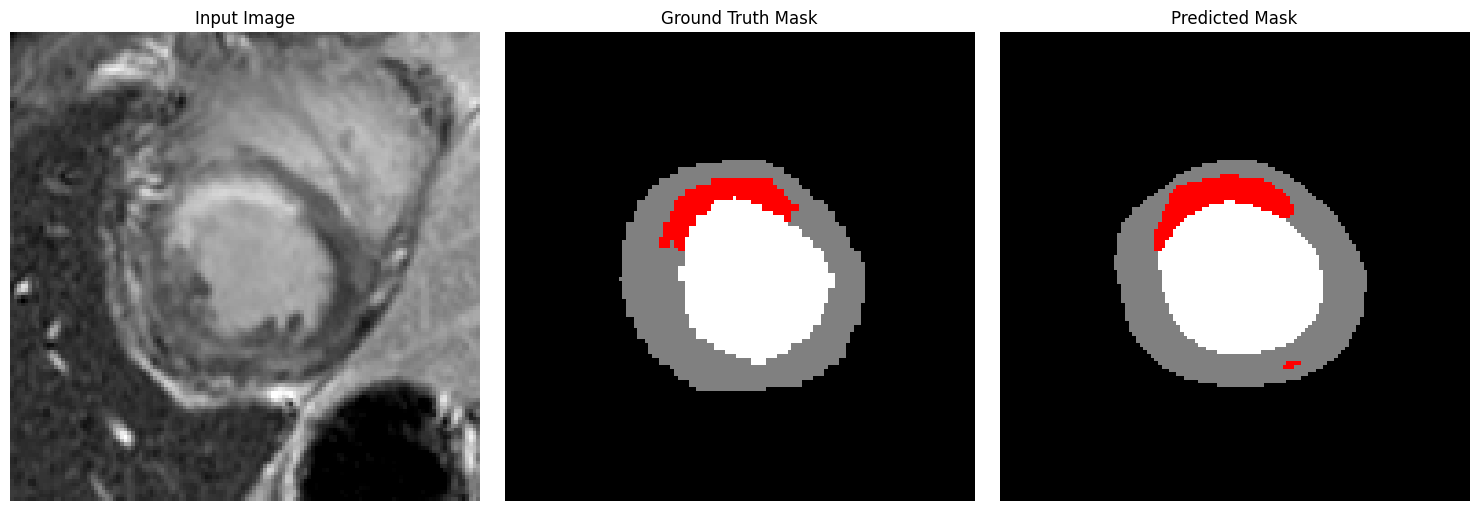


Per-class Dice scores:
  Class 0: Dice = 0.9866
  Class 1: Dice = 0.9295
  Class 2: Dice = 0.8269
  Class 3: Dice = 0.6399
  Class 4: Dice = 0.4302

Epoch 39: Mean Dice = 0.7626
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 216ms/step - loss: 0.2646 - sparse_categorical_accuracy: 0.9797 - val_loss: 1.6889 - val_sparse_categorical_accuracy: 0.9594
Epoch 40/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - loss: 0.2615 - sparse_categorical_accuracy: 0.9799Saved checkpoint: /content/drive/MyDrive/Original_Data_Only_Augmented_10000/ckpt/ckpt-epoch40.weights.h5
Generating predictions at epoch 40


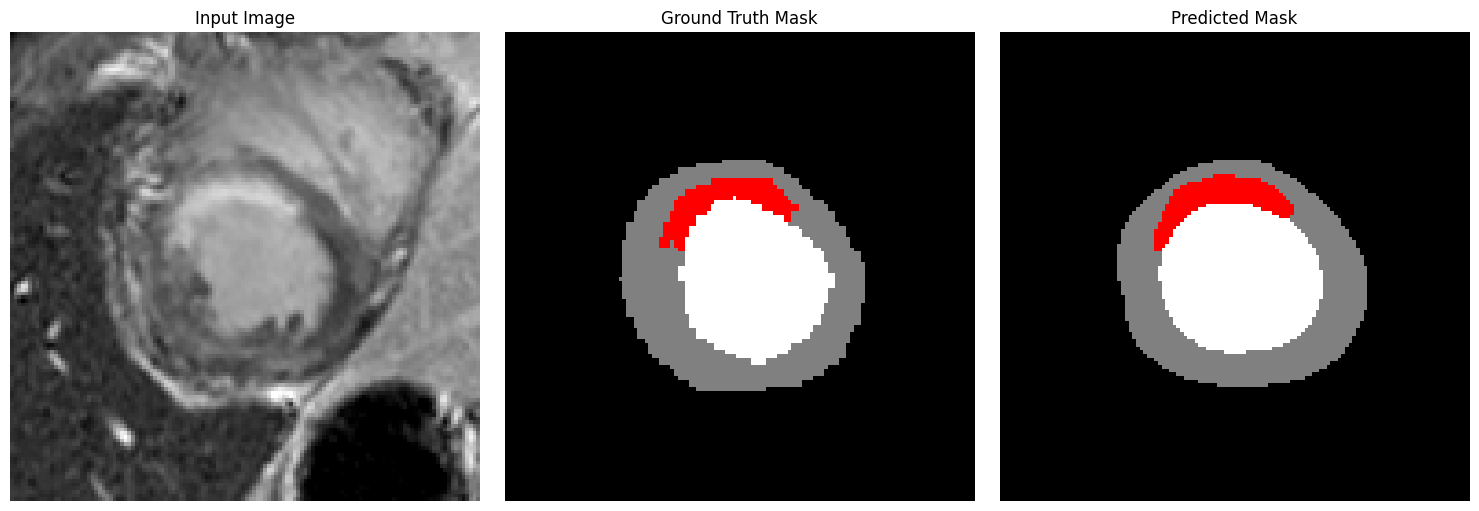


Per-class Dice scores:
  Class 0: Dice = 0.9867
  Class 1: Dice = 0.9292
  Class 2: Dice = 0.8275
  Class 3: Dice = 0.6343
  Class 4: Dice = 0.4336

Epoch 40: Mean Dice = 0.7623
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 276s 221ms/step - loss: 0.2615 - sparse_categorical_accuracy: 0.9799 - val_loss: 1.7504 - val_sparse_categorical_accuracy: 0.9595
Training time: 3:25:26.224640


In [ ]:
# Start training
start = datetime.now()

history = model.fit(
    x=train_images_tensor,
    y=train_masks_tensor,
    batch_size=batch_size,
    epochs=40,
    verbose=1,
    validation_data=(val_images_tensor, val_masks_tensor),
    shuffle=True,
    callbacks=callbacks
)

stop = datetime.now()
print("Training time:", stop - start)

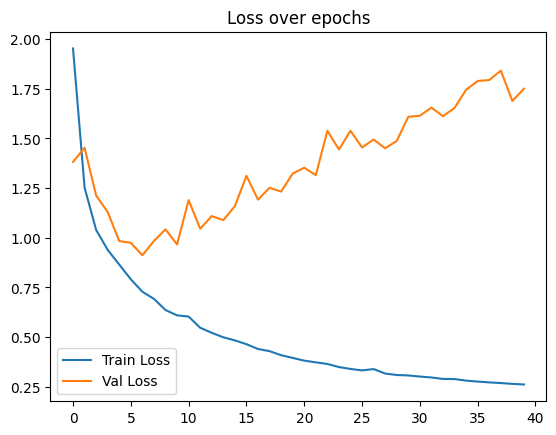

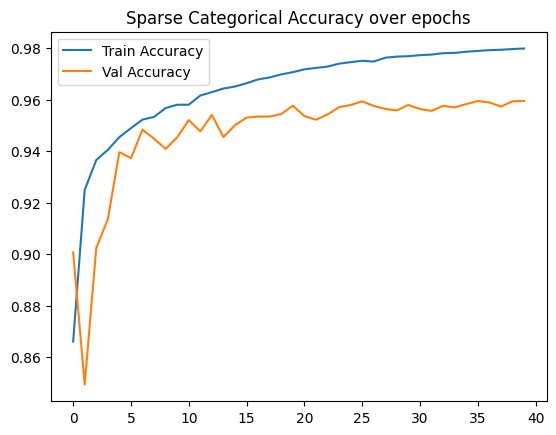

In [ ]:
# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss over epochs")
plt.legend()
plt.show()

# Plot accuracy
plt.plot(history.history['sparse_categorical_accuracy'], label='Train Accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='Val Accuracy')
plt.title("Sparse Categorical Accuracy over epochs")
plt.legend()
plt.show()

  0%|          | 0/80 [00:00<?, ?it/s]

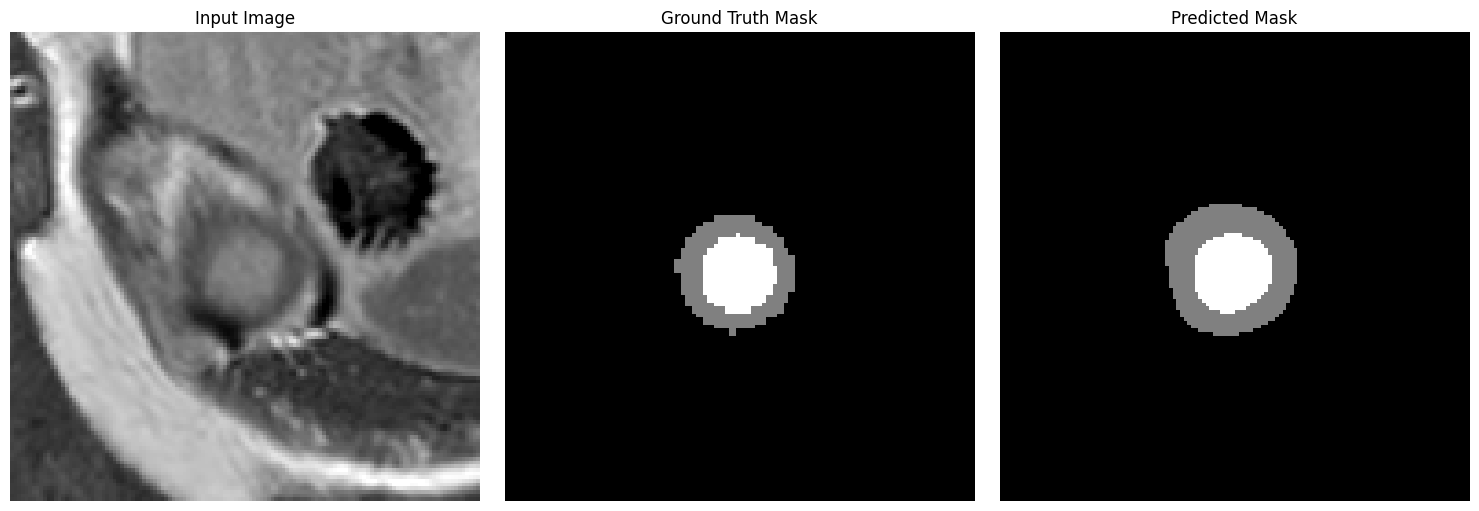

  1%|▏         | 1/80 [00:00<00:38,  2.06it/s]

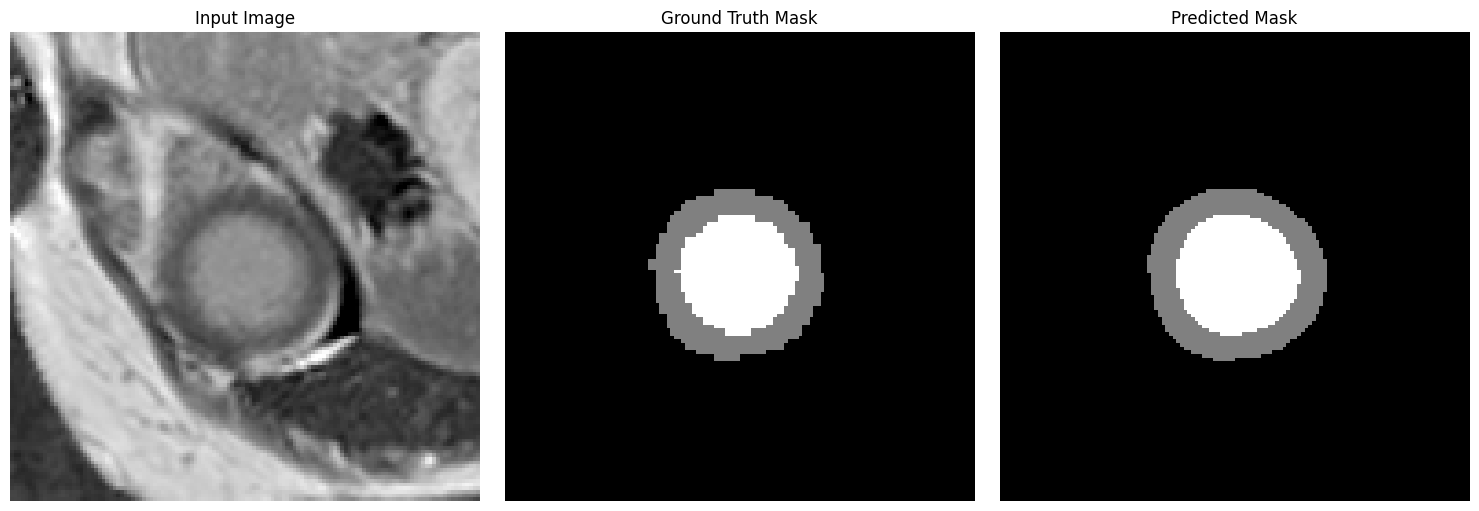

  2%|▎         | 2/80 [00:01<00:43,  1.77it/s]

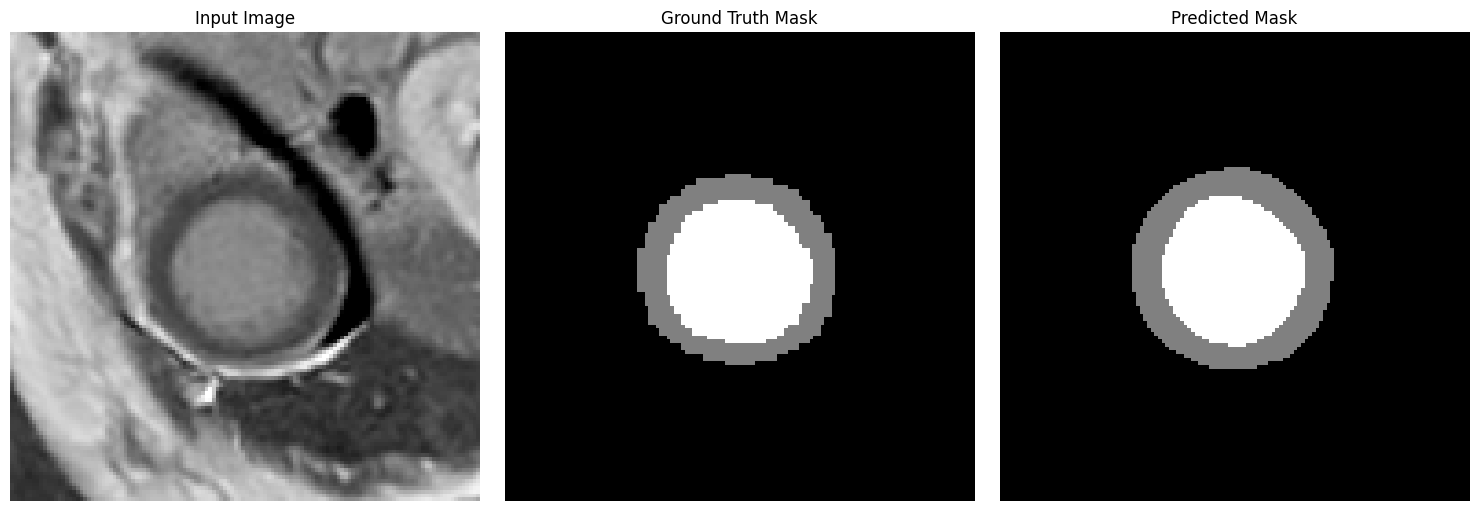

  4%|▍         | 3/80 [00:01<00:44,  1.73it/s]

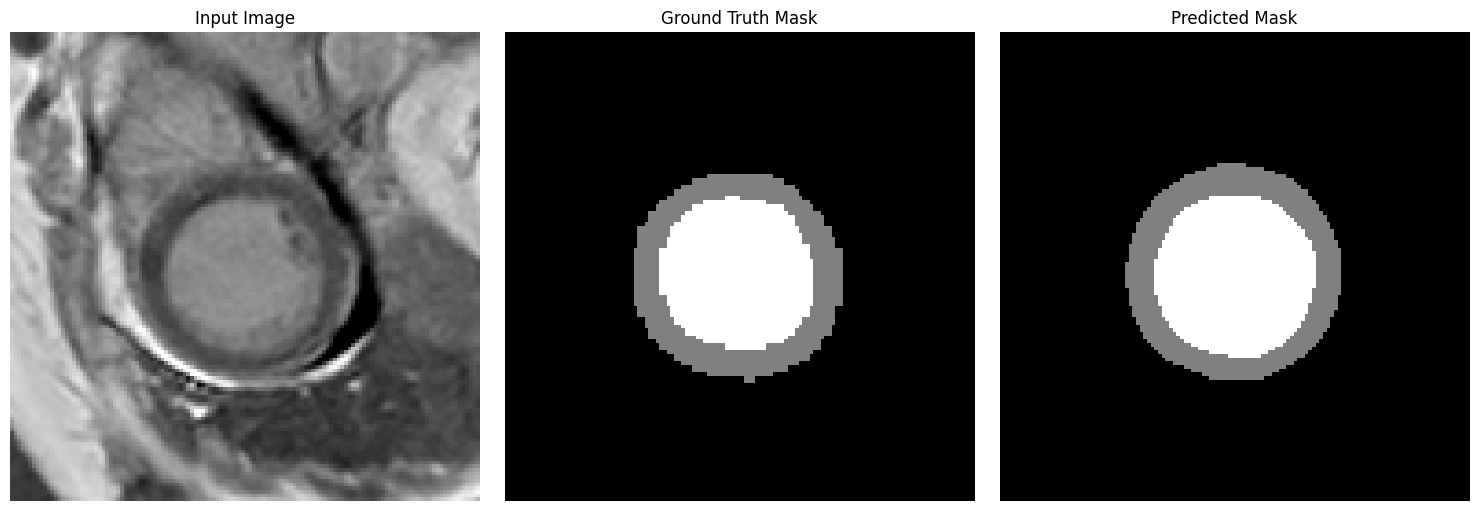

  5%|▌         | 4/80 [00:02<00:46,  1.63it/s]

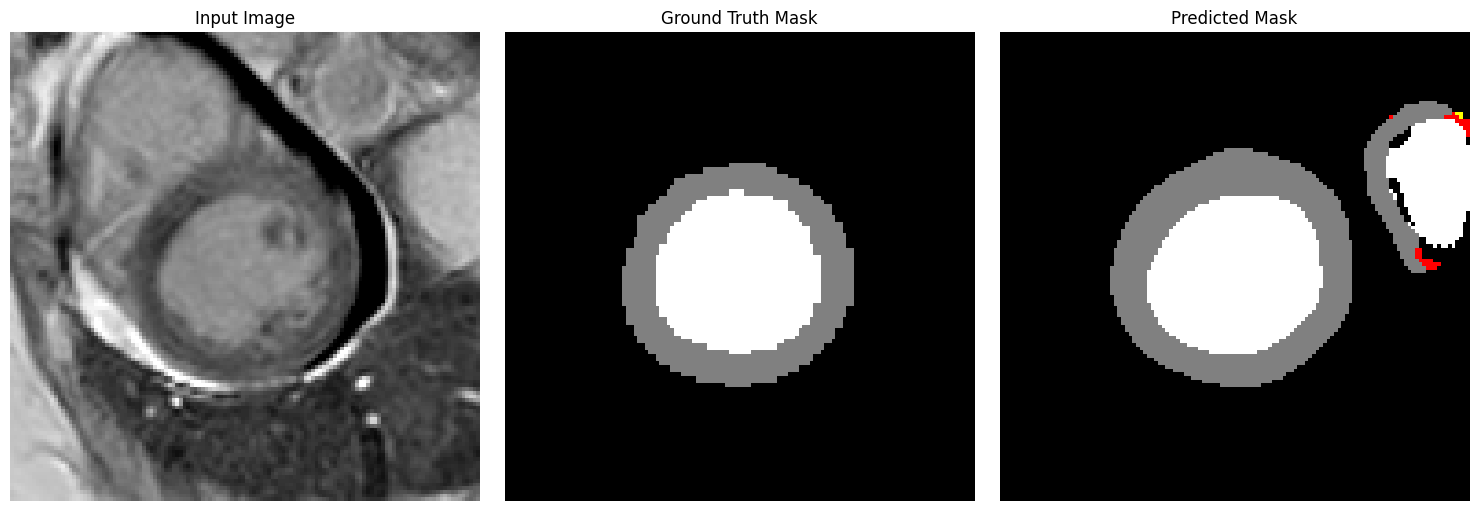

  6%|▋         | 5/80 [00:02<00:45,  1.66it/s]

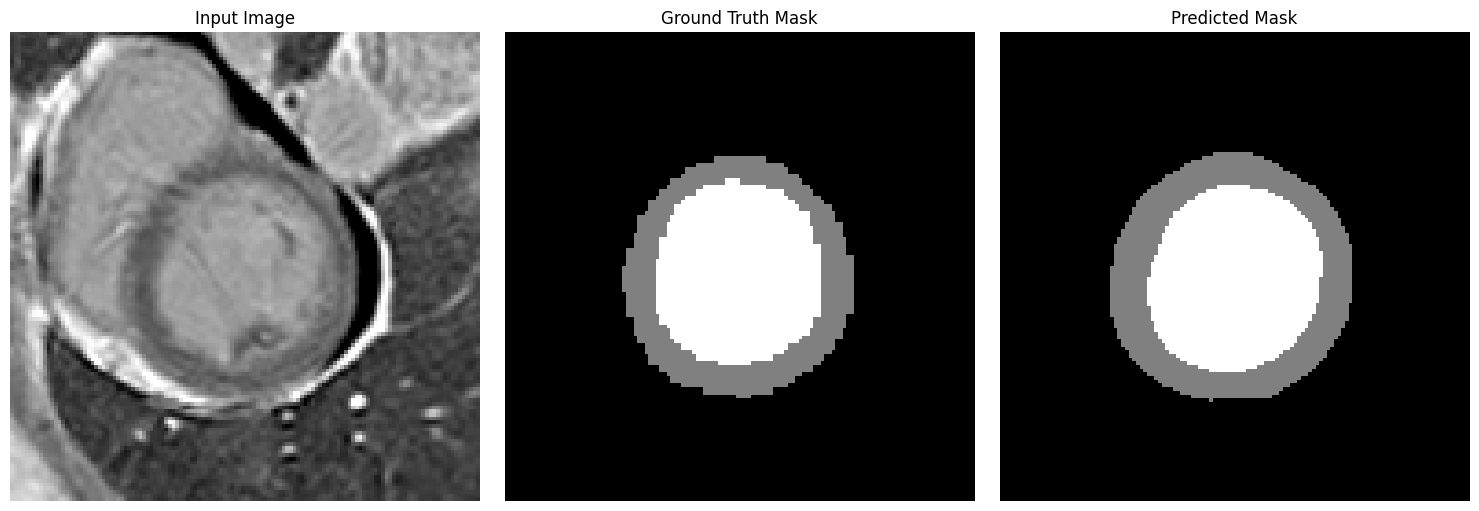

  8%|▊         | 6/80 [00:03<00:45,  1.63it/s]

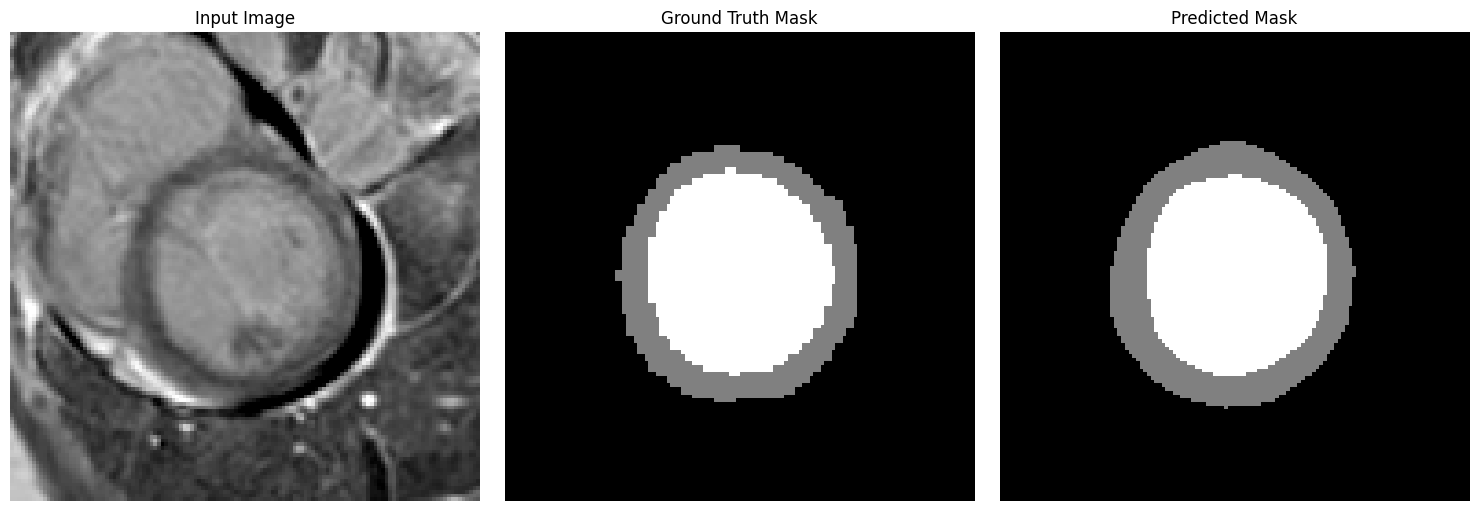

  9%|▉         | 7/80 [00:04<00:41,  1.78it/s]

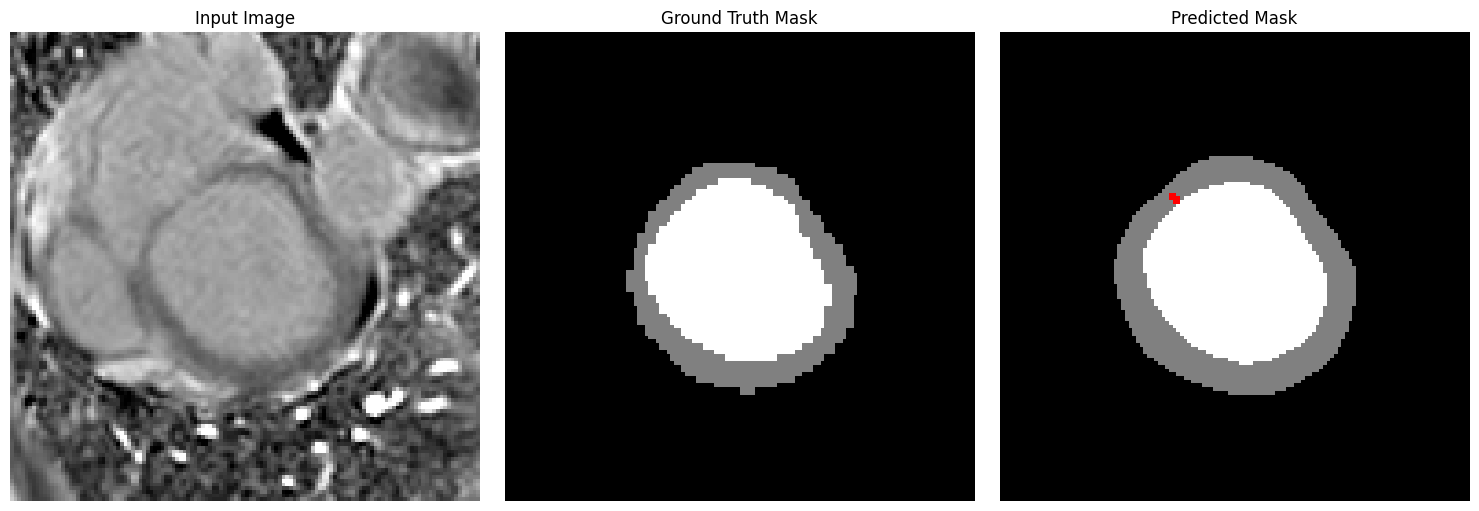

 10%|█         | 8/80 [00:04<00:38,  1.87it/s]

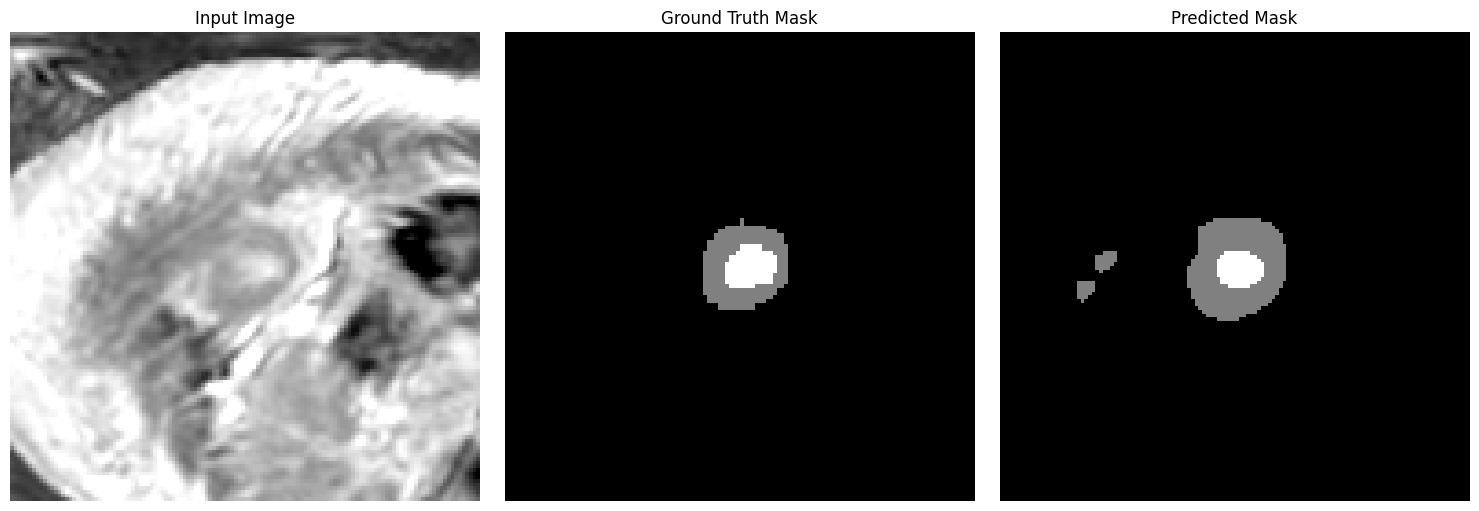

 11%|█▏        | 9/80 [00:04<00:34,  2.03it/s]

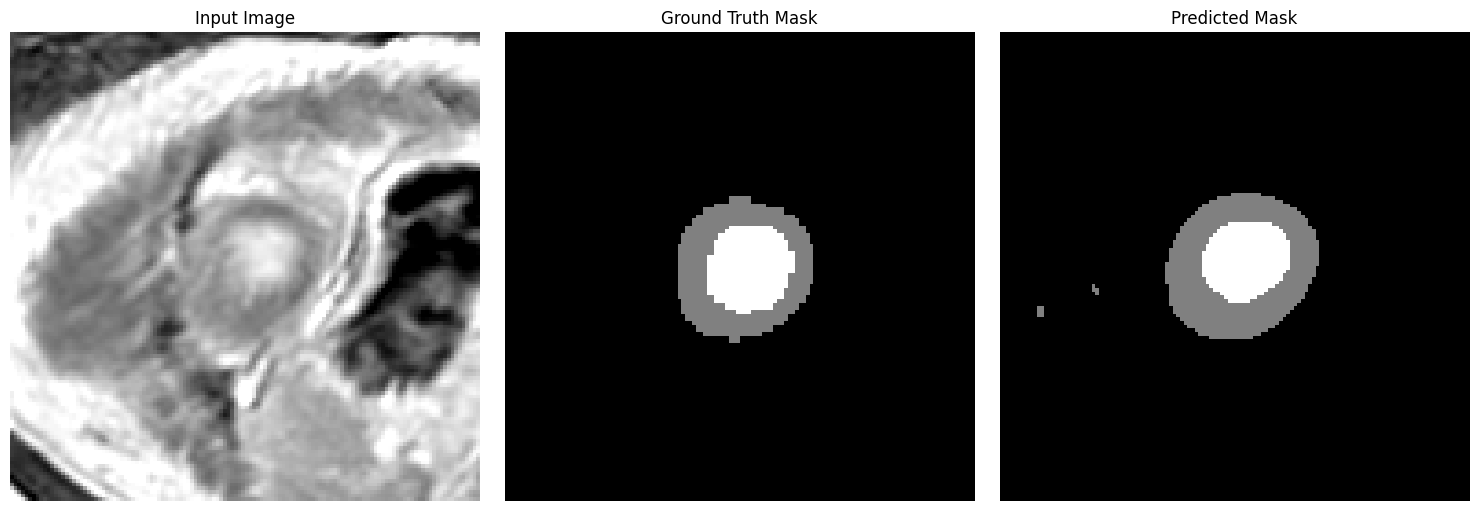

 12%|█▎        | 10/80 [00:05<00:32,  2.13it/s]

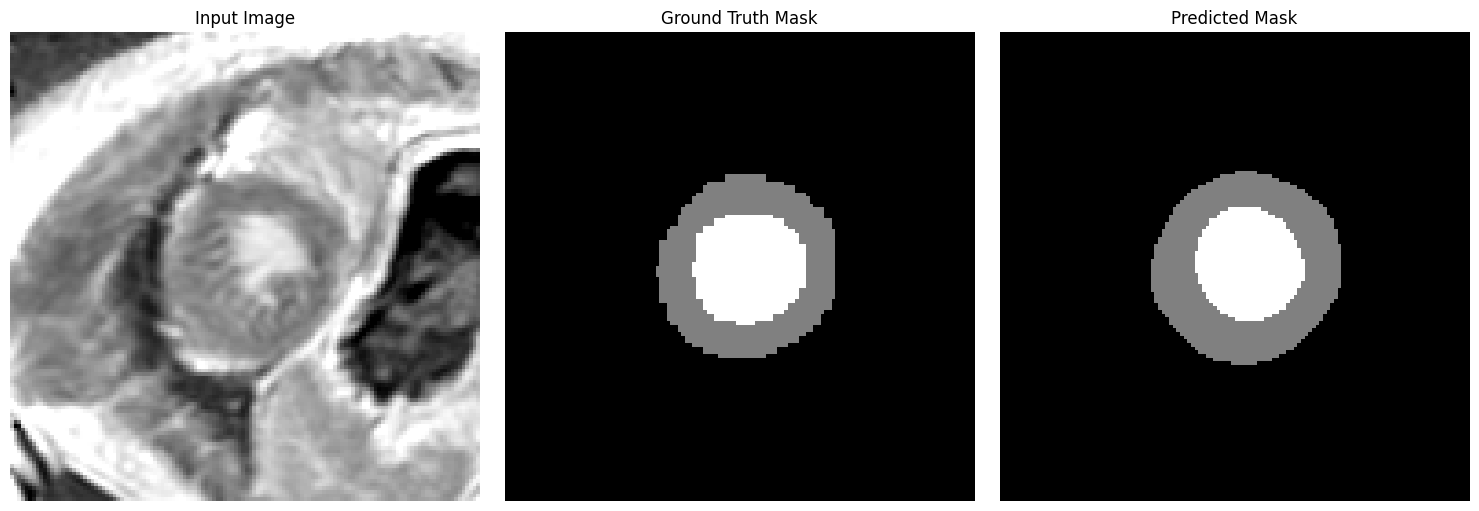

 14%|█▍        | 11/80 [00:05<00:31,  2.20it/s]

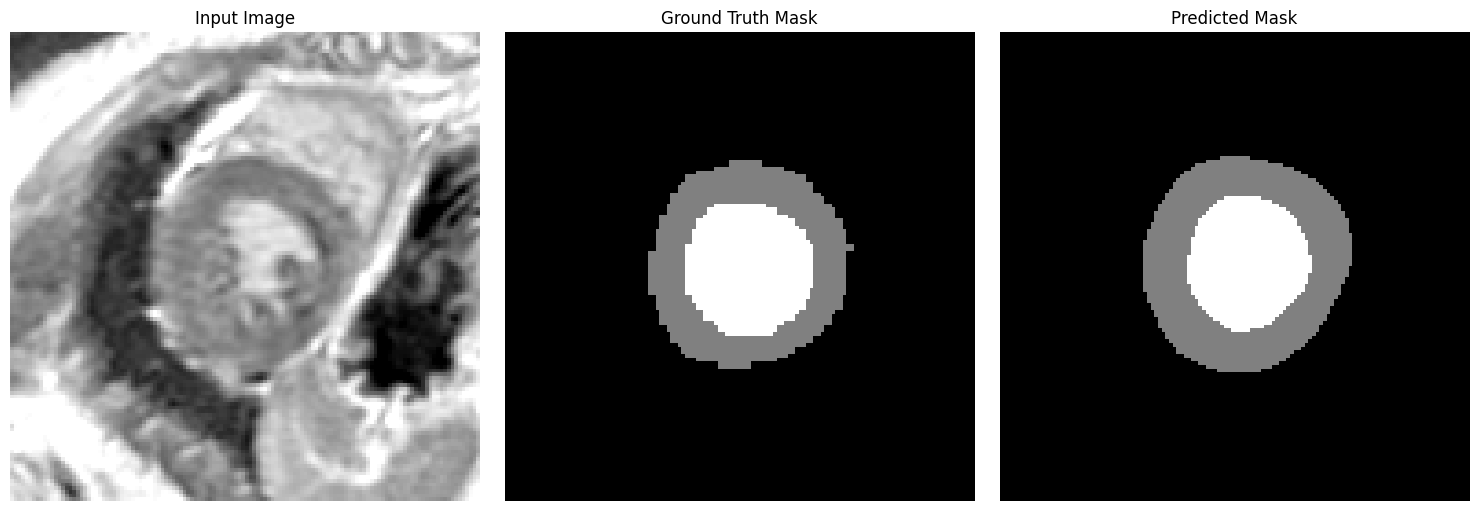

 15%|█▌        | 12/80 [00:06<00:32,  2.10it/s]

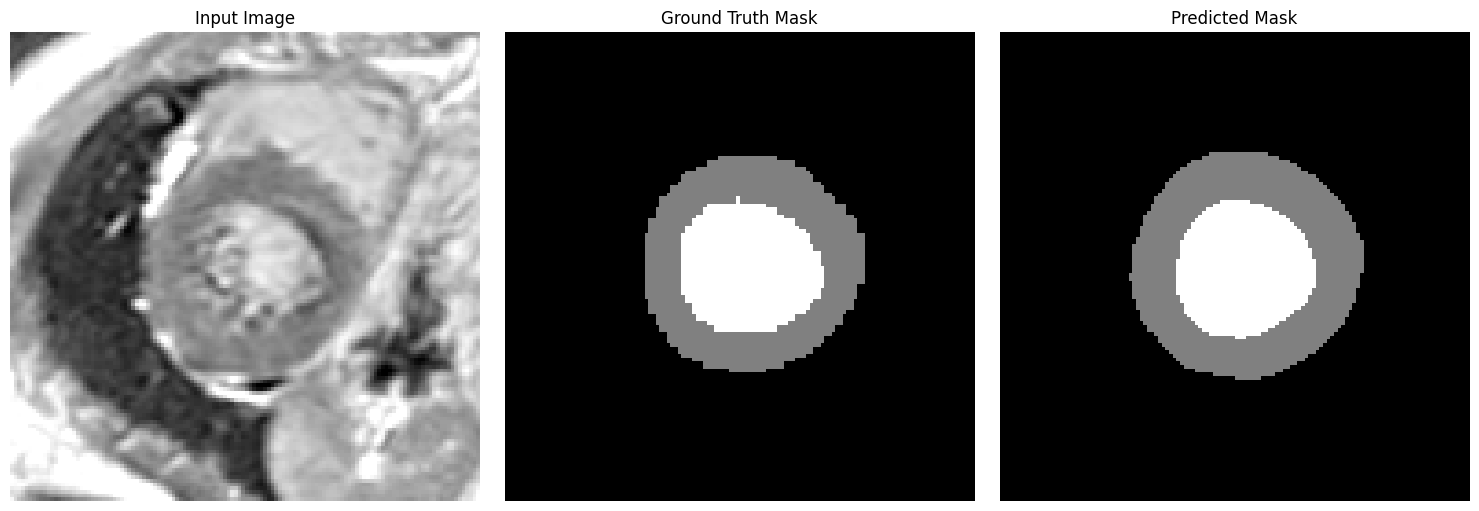

 16%|█▋        | 13/80 [00:06<00:34,  1.94it/s]

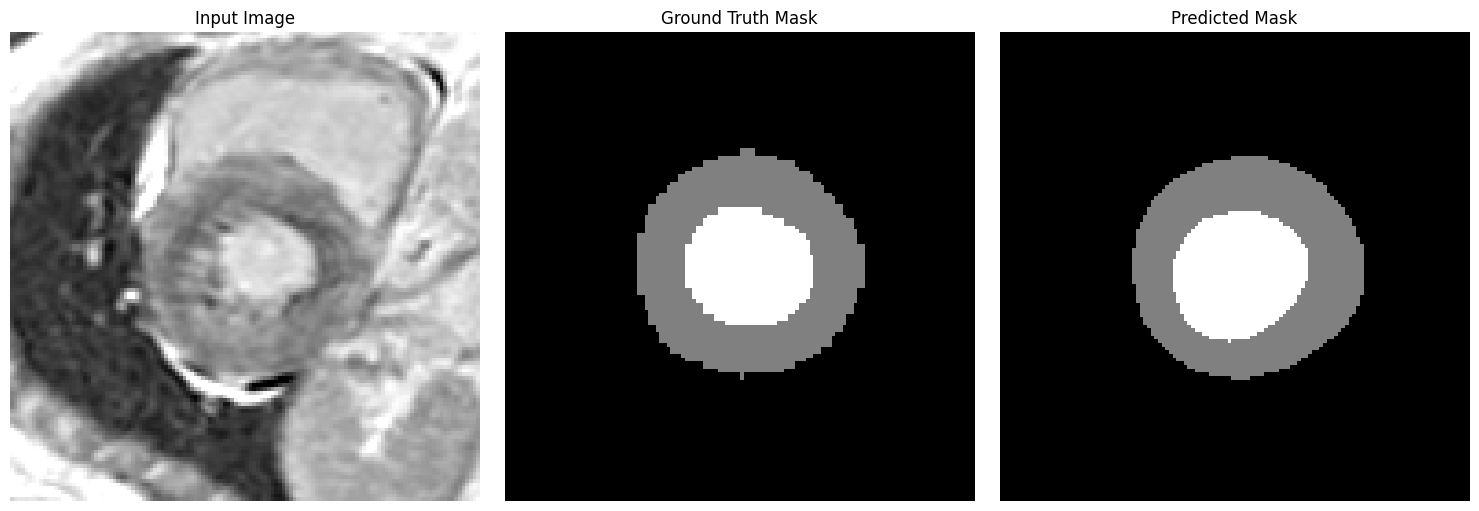

 18%|█▊        | 14/80 [00:07<00:36,  1.81it/s]

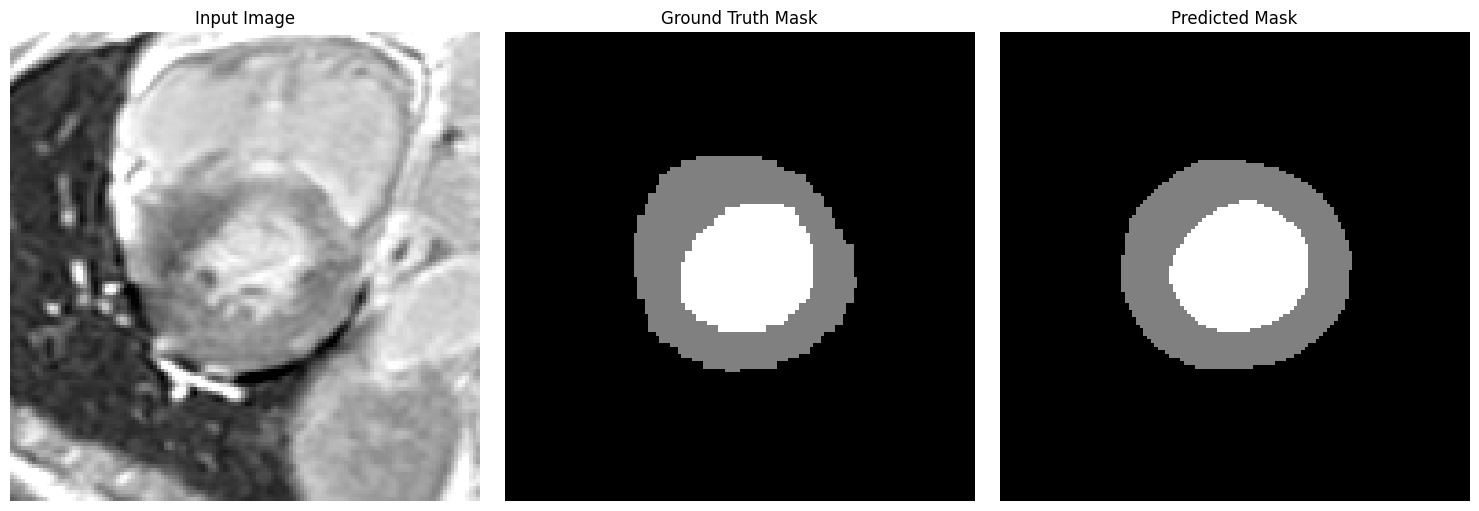

 19%|█▉        | 15/80 [00:08<00:37,  1.75it/s]

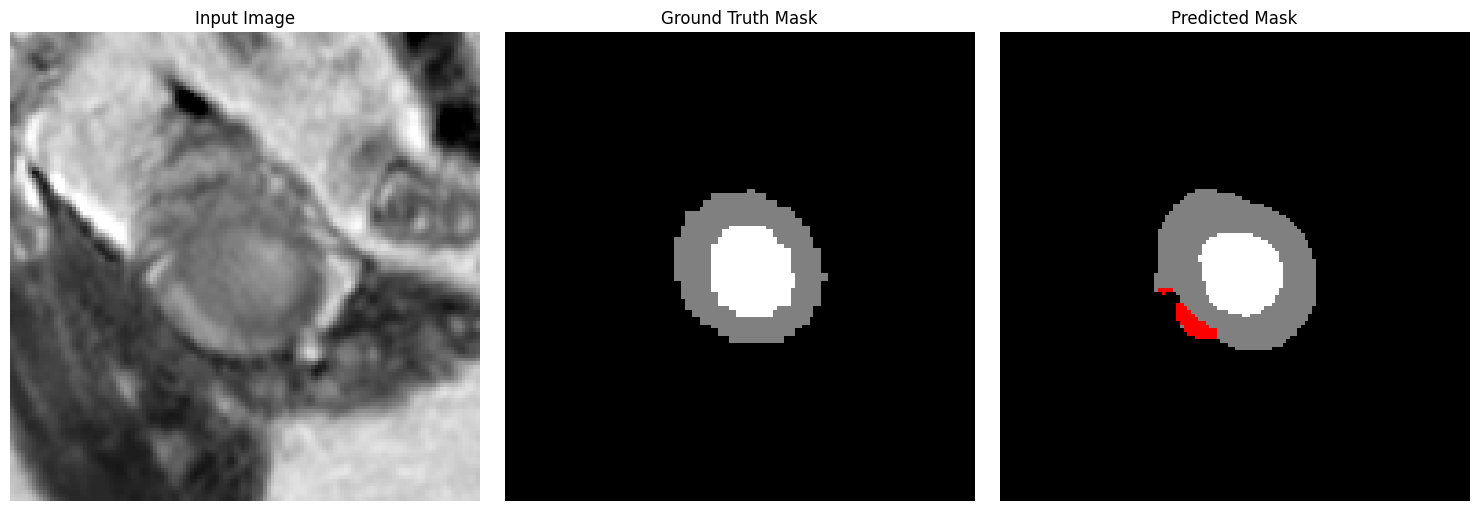

 20%|██        | 16/80 [00:08<00:36,  1.74it/s]

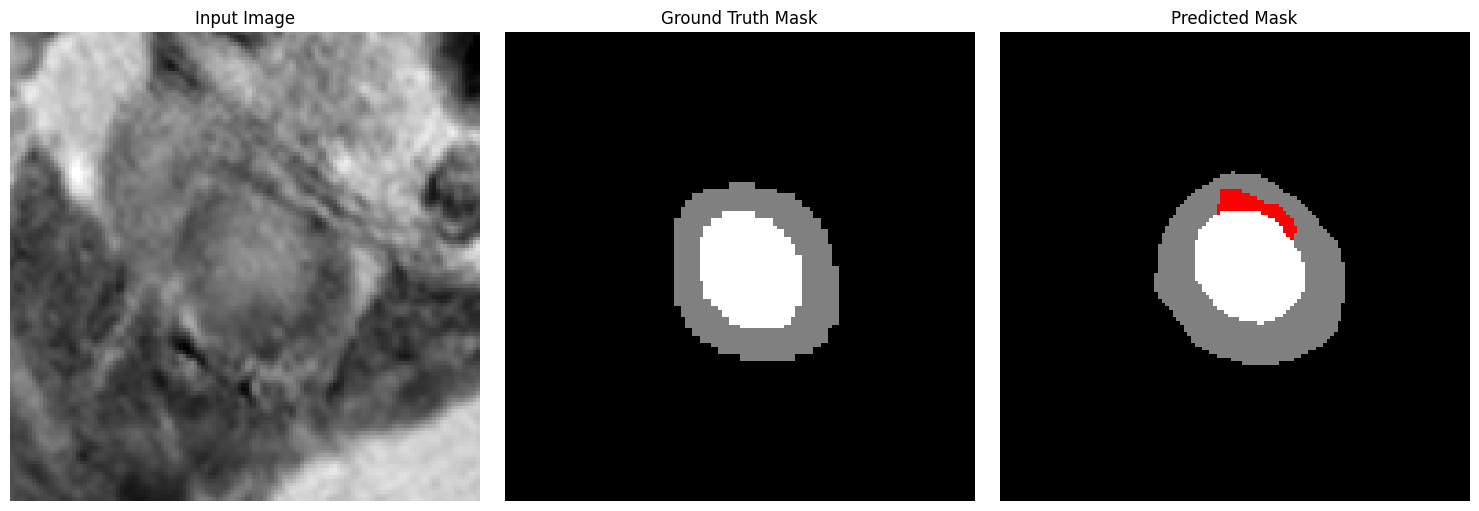

 21%|██▏       | 17/80 [00:09<00:35,  1.75it/s]

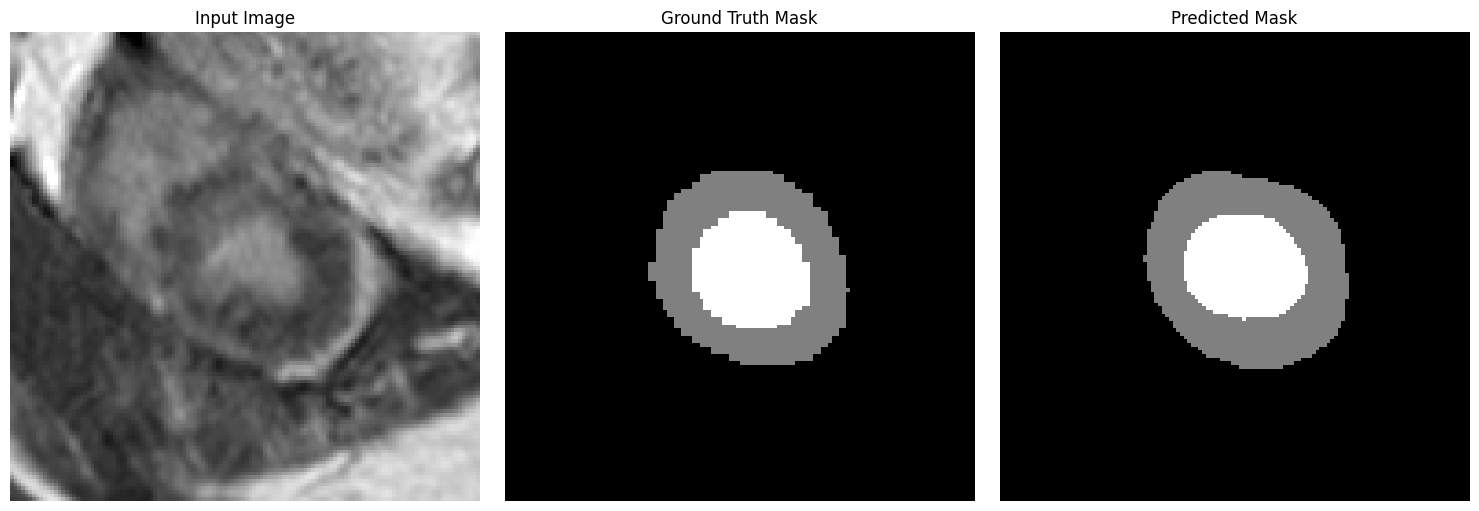

 22%|██▎       | 18/80 [00:09<00:36,  1.71it/s]

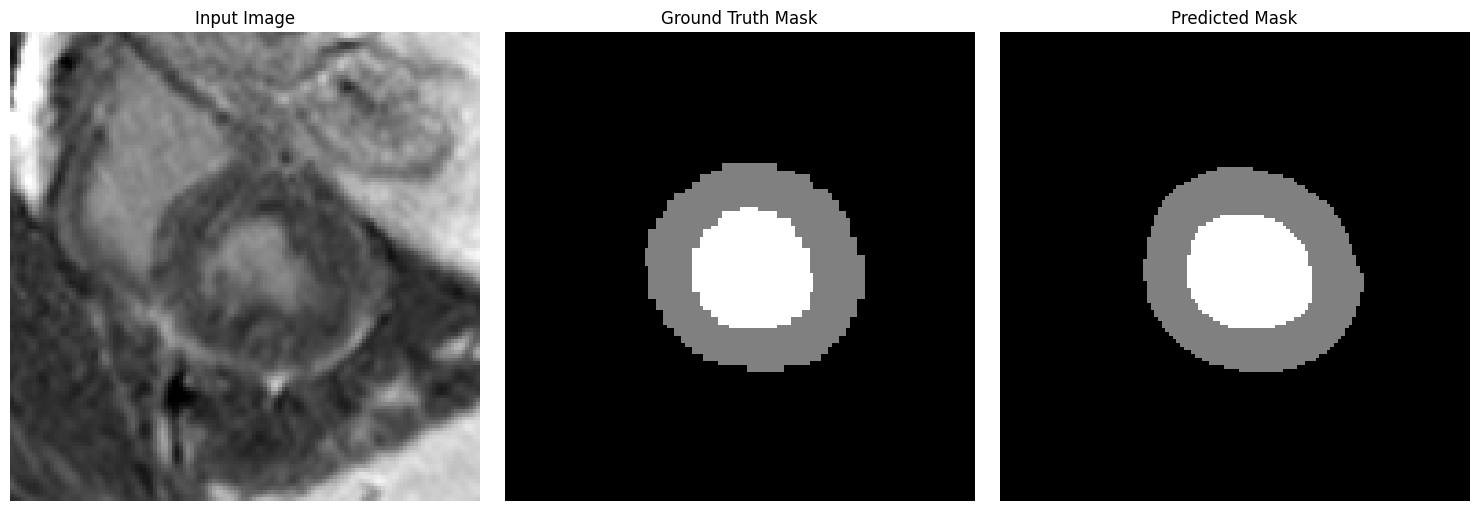

 24%|██▍       | 19/80 [00:11<00:46,  1.30it/s]

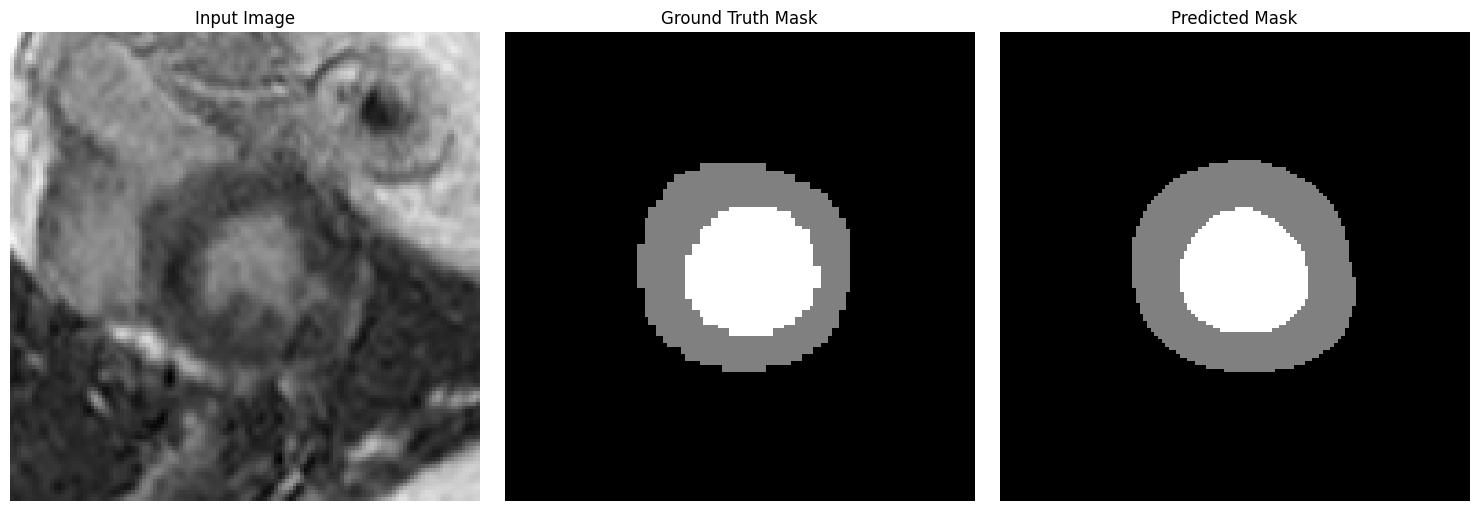

 25%|██▌       | 20/80 [00:11<00:39,  1.51it/s]

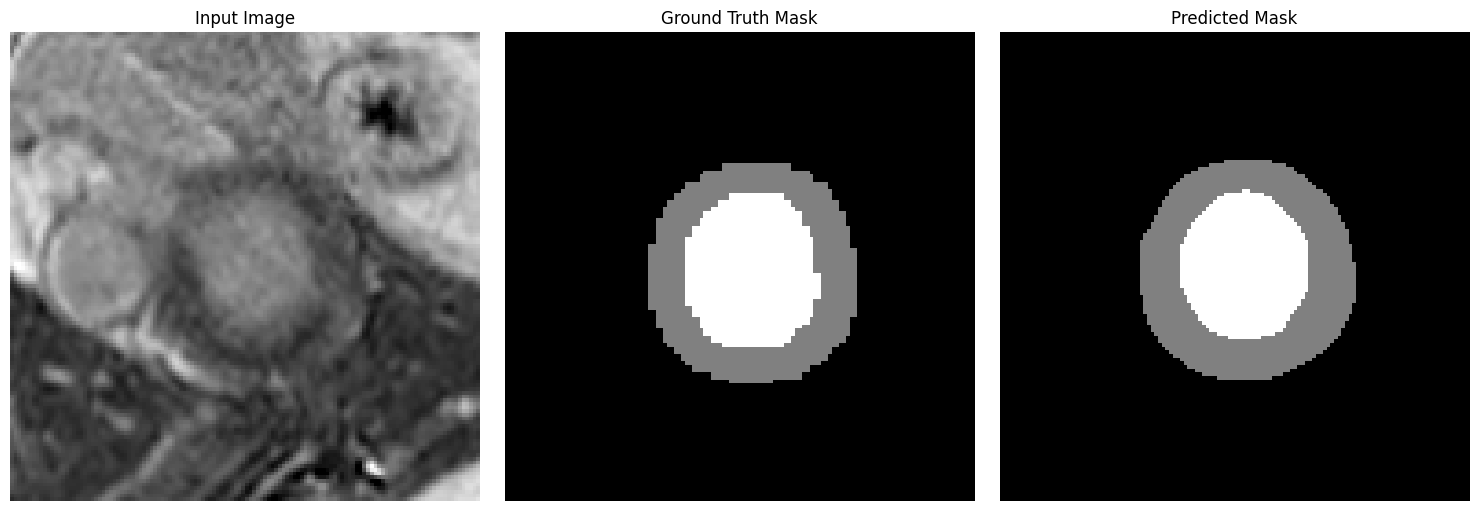

 26%|██▋       | 21/80 [00:11<00:34,  1.70it/s]

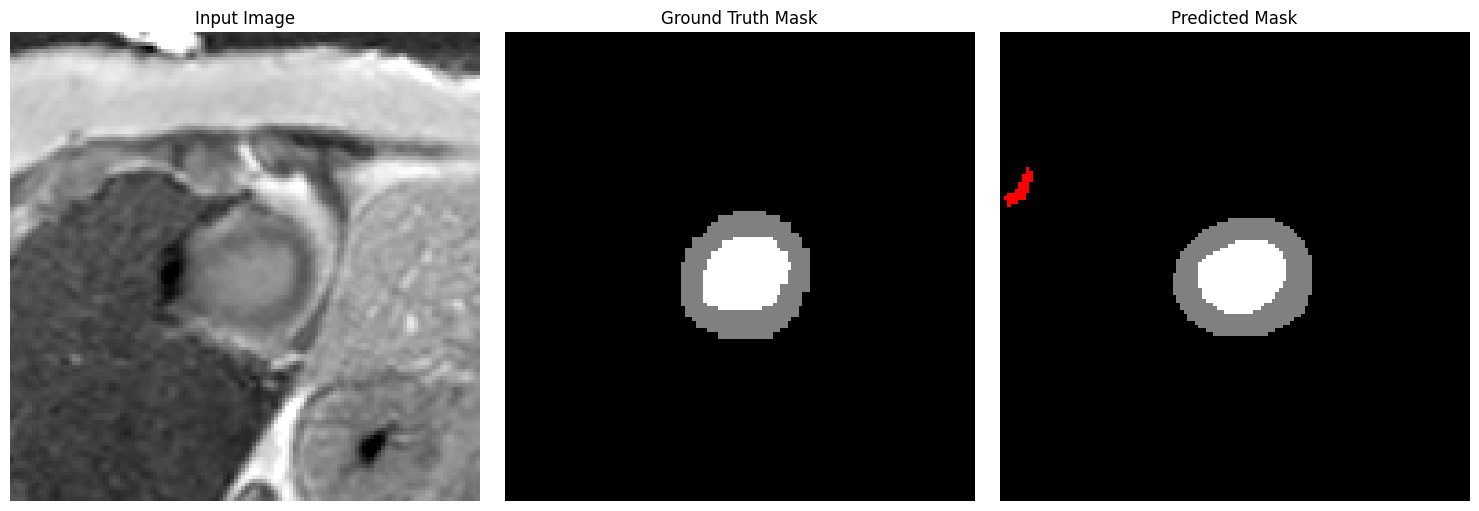

 28%|██▊       | 22/80 [00:12<00:31,  1.87it/s]

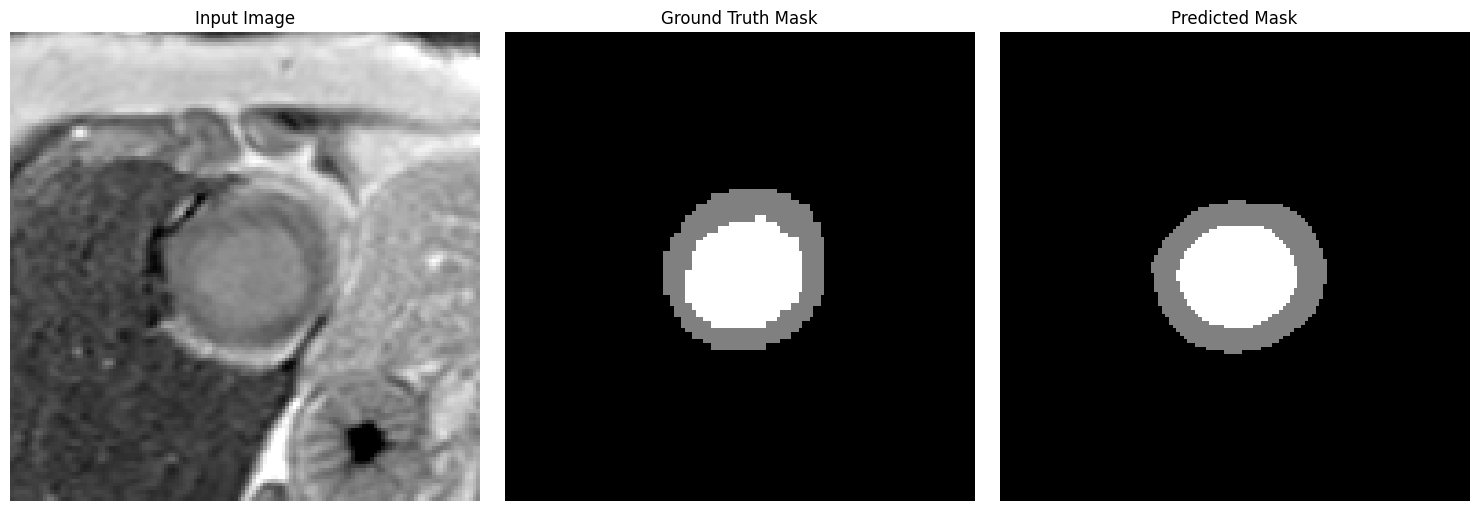

 29%|██▉       | 23/80 [00:12<00:28,  2.00it/s]

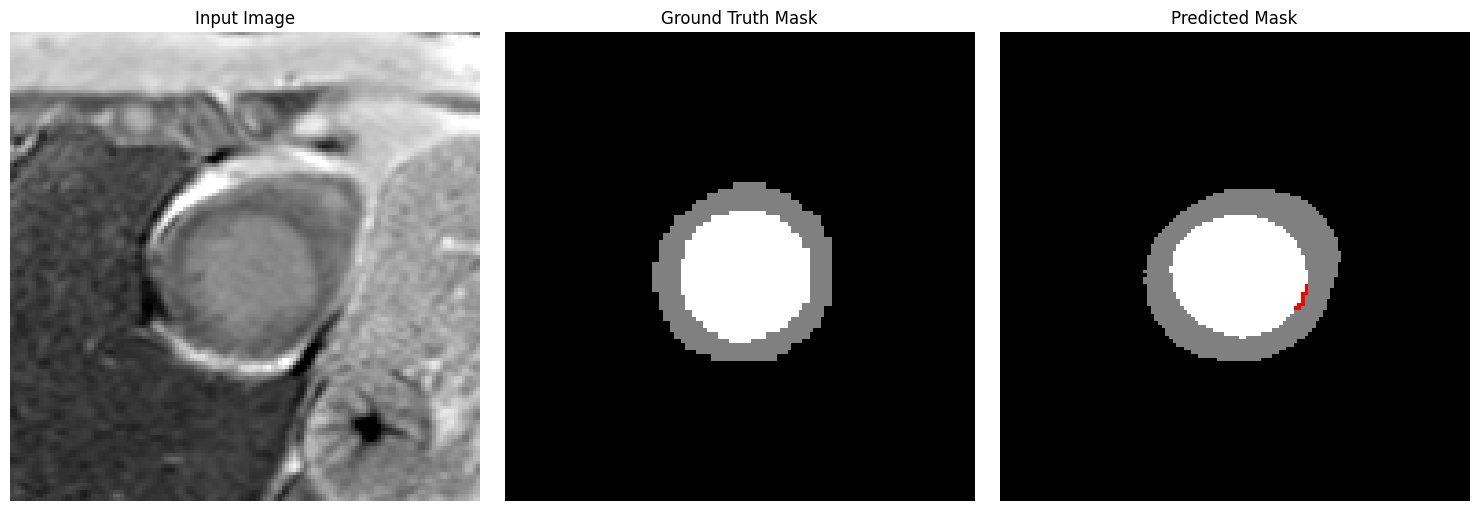

 30%|███       | 24/80 [00:13<00:26,  2.11it/s]

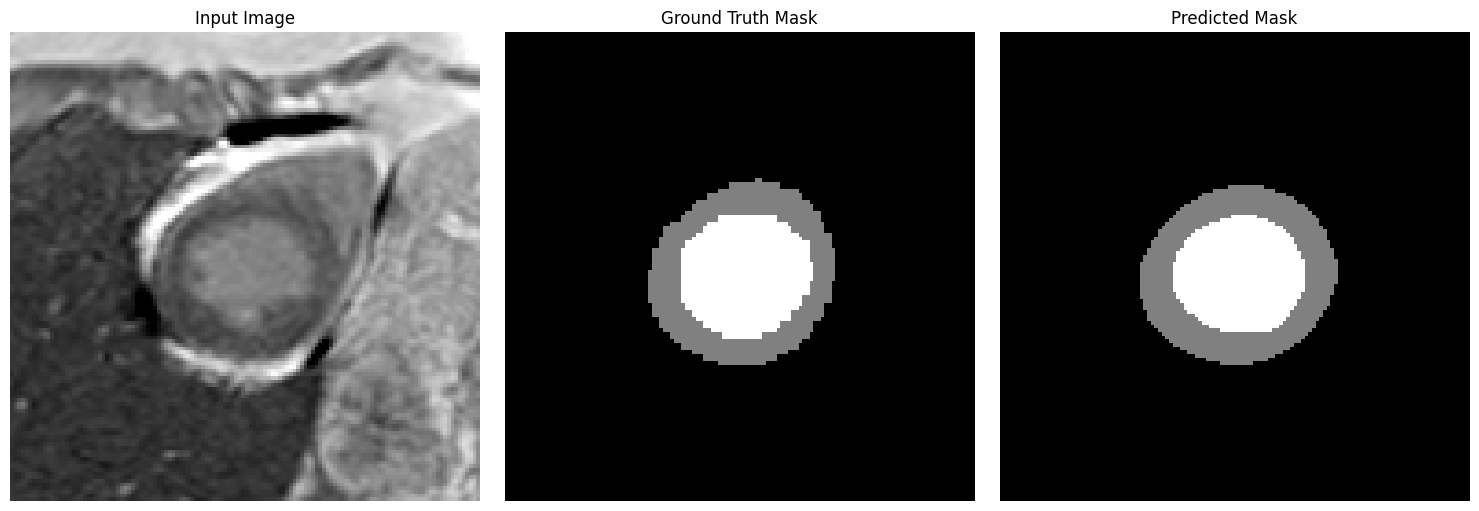

 31%|███▏      | 25/80 [00:13<00:24,  2.21it/s]

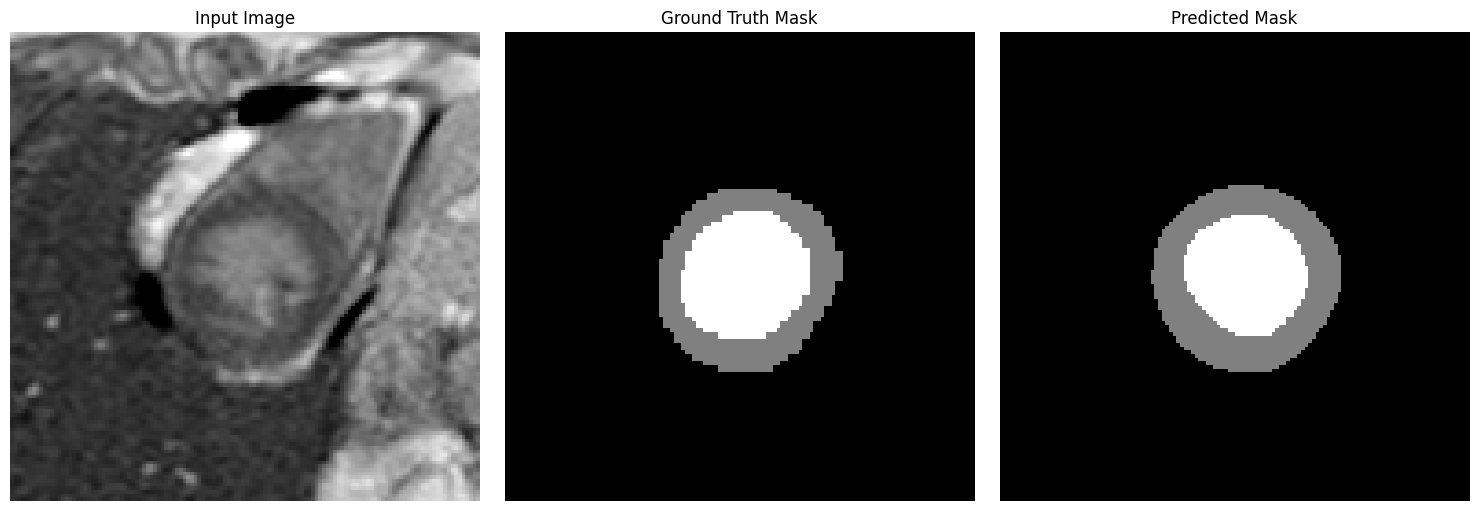

 32%|███▎      | 26/80 [00:14<00:25,  2.08it/s]

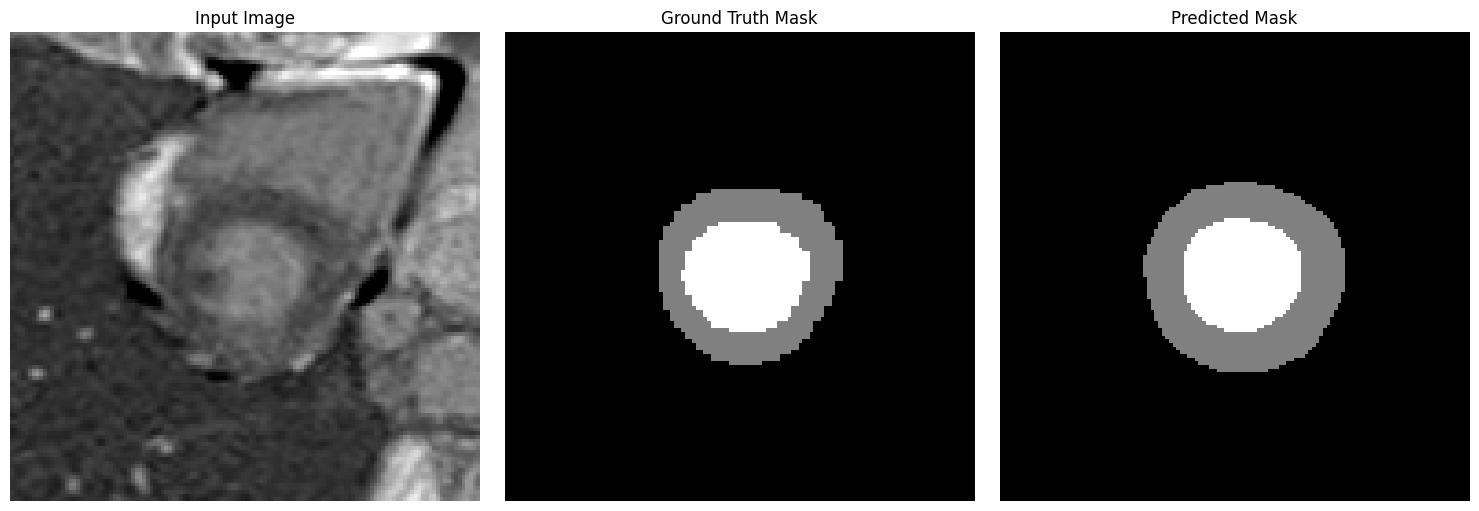

 34%|███▍      | 27/80 [00:14<00:26,  1.96it/s]

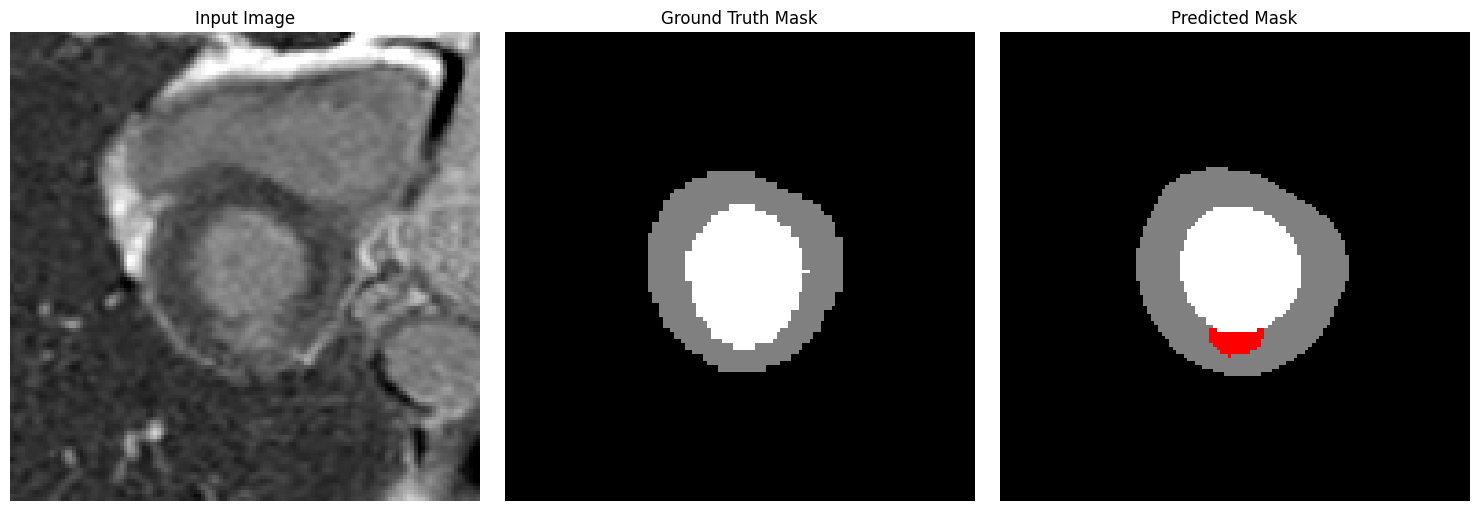

 35%|███▌      | 28/80 [00:15<00:28,  1.85it/s]

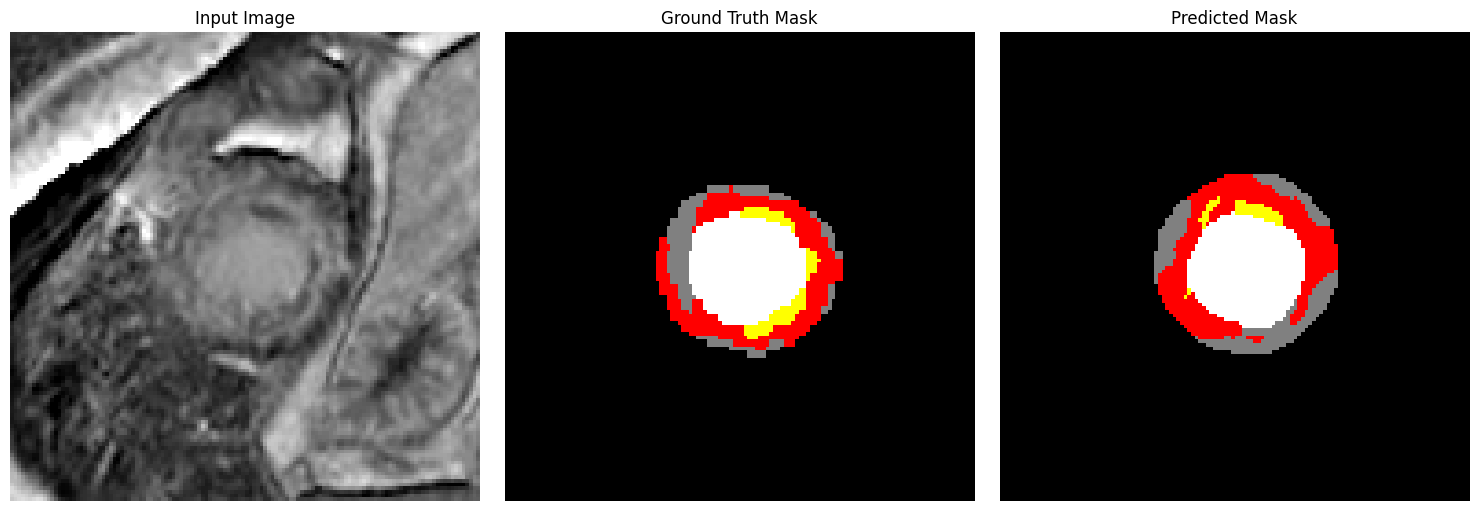

 36%|███▋      | 29/80 [00:15<00:28,  1.81it/s]

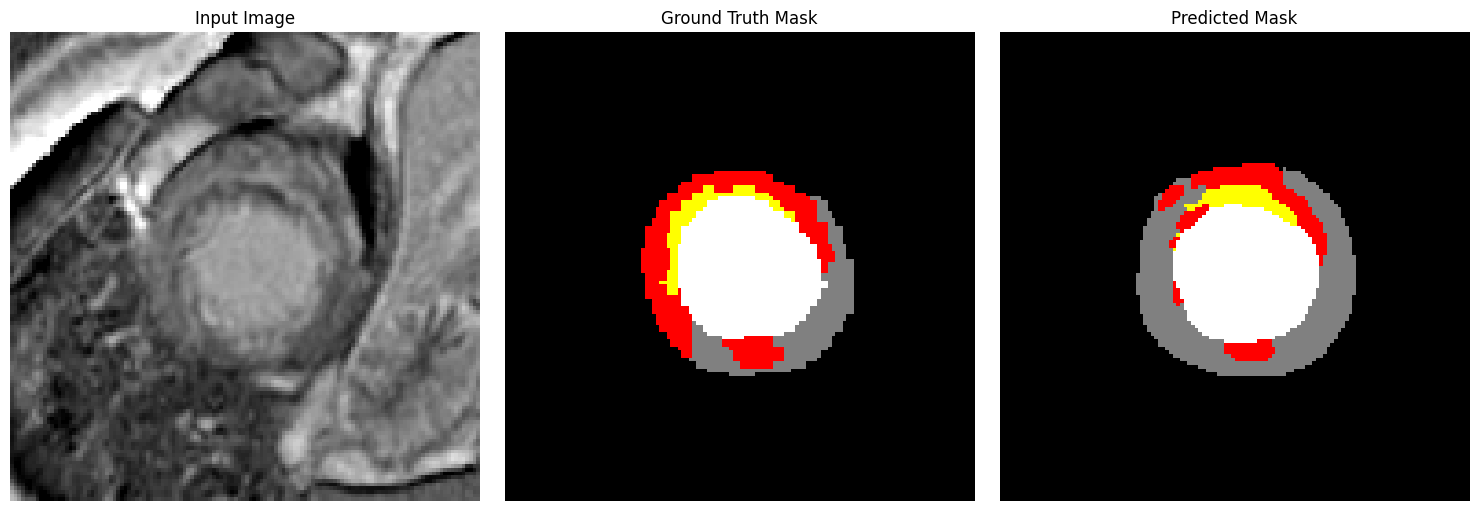

 38%|███▊      | 30/80 [00:16<00:27,  1.79it/s]

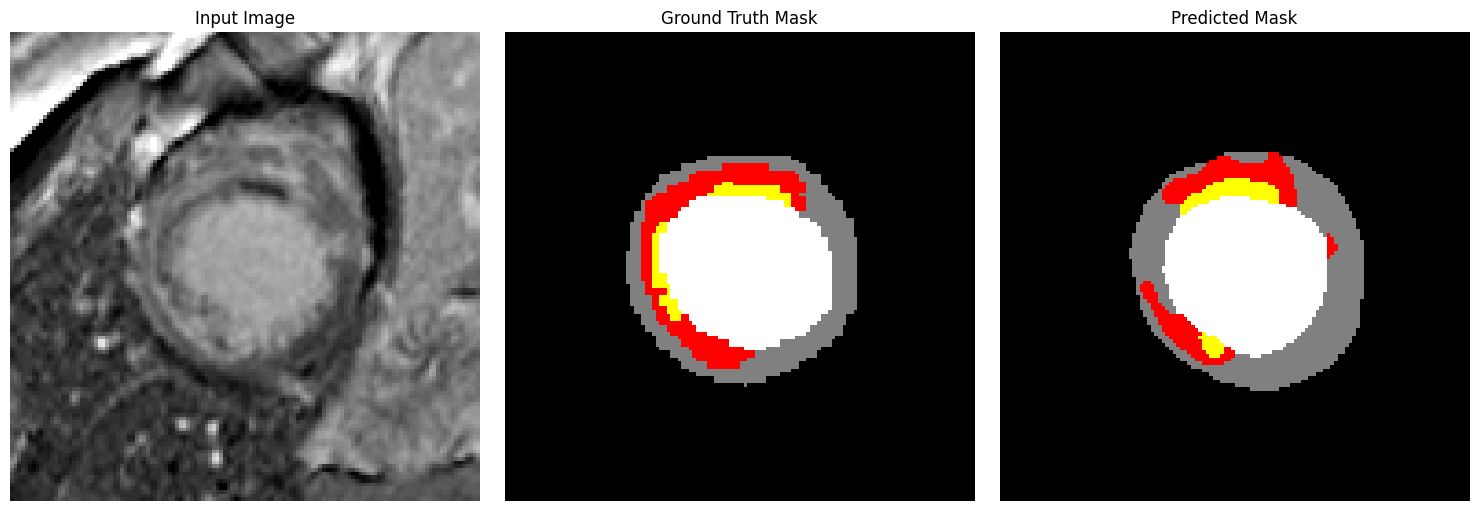

 39%|███▉      | 31/80 [00:17<00:28,  1.72it/s]

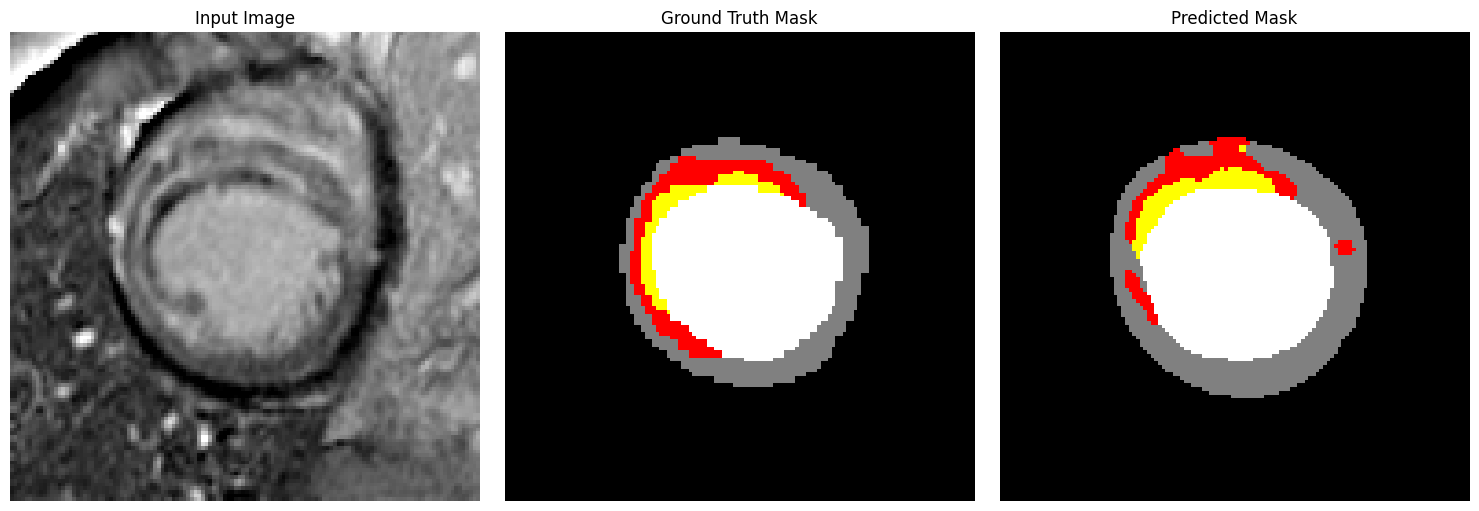

 40%|████      | 32/80 [00:17<00:26,  1.84it/s]

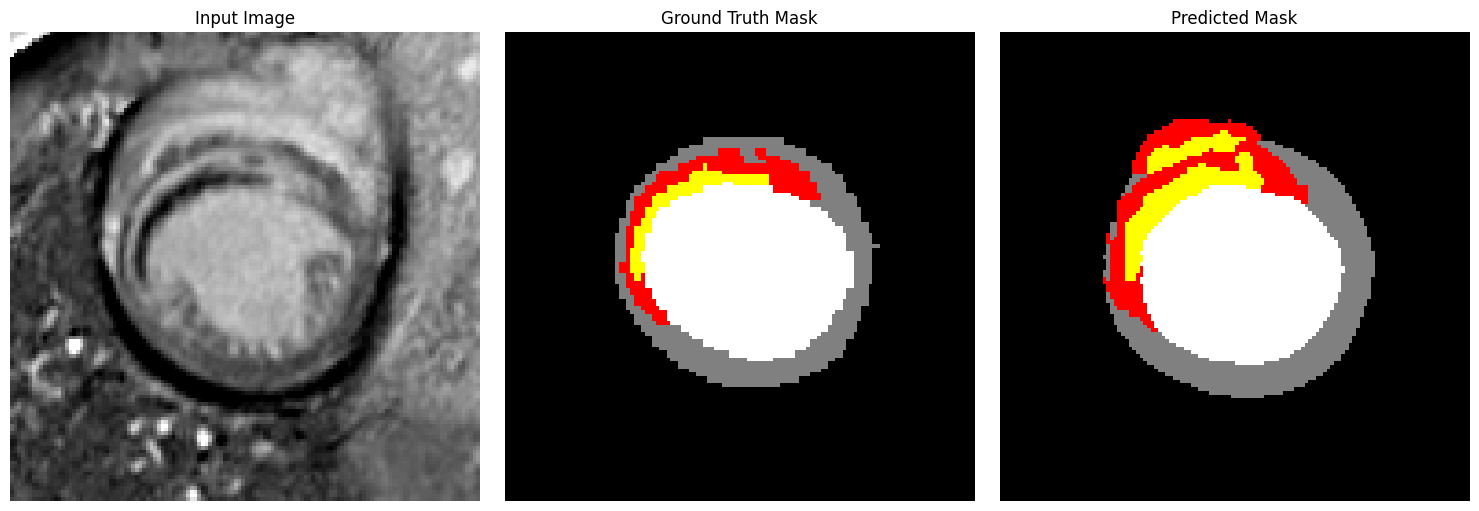

 41%|████▏     | 33/80 [00:17<00:23,  1.97it/s]

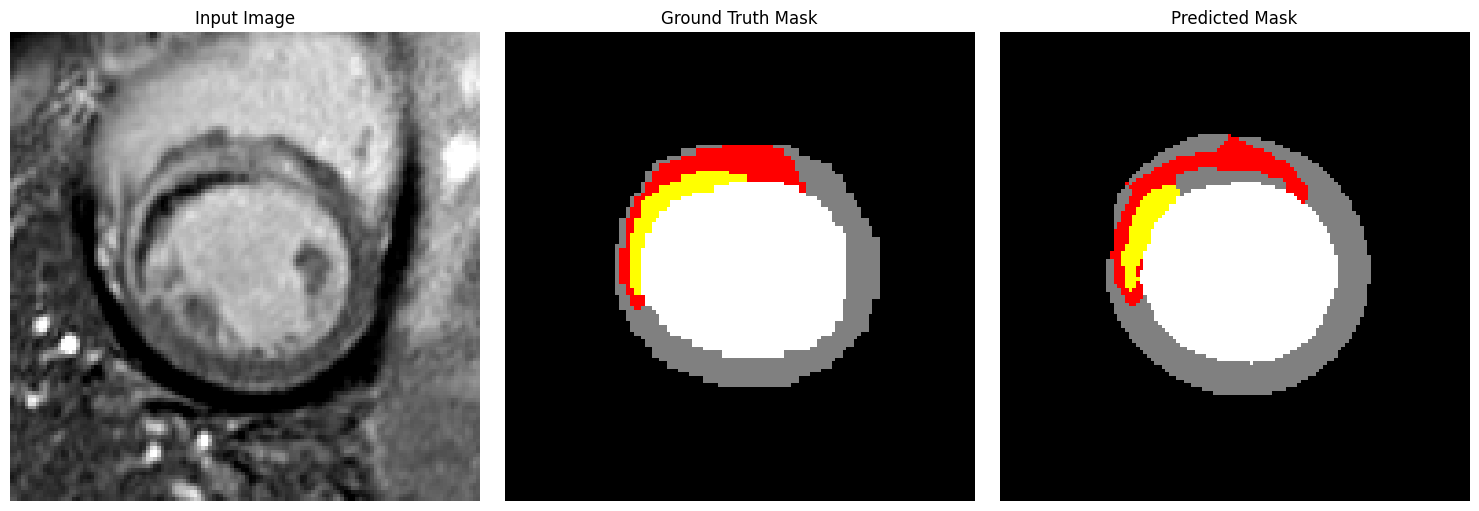

 42%|████▎     | 34/80 [00:18<00:22,  2.09it/s]

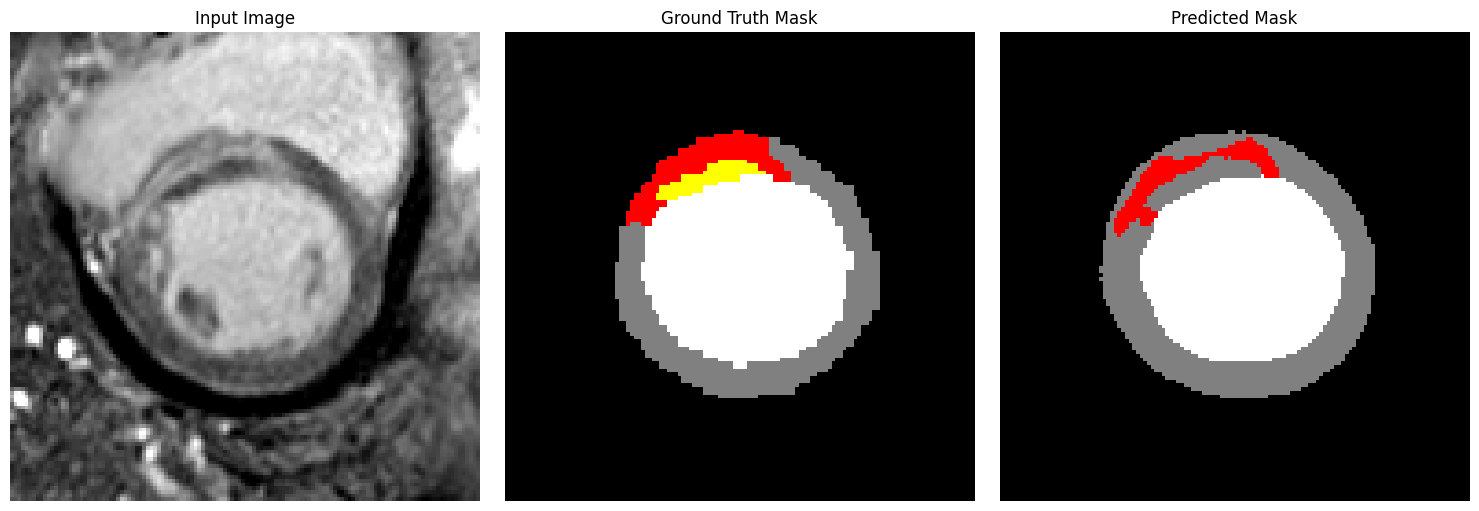

 44%|████▍     | 35/80 [00:18<00:20,  2.18it/s]

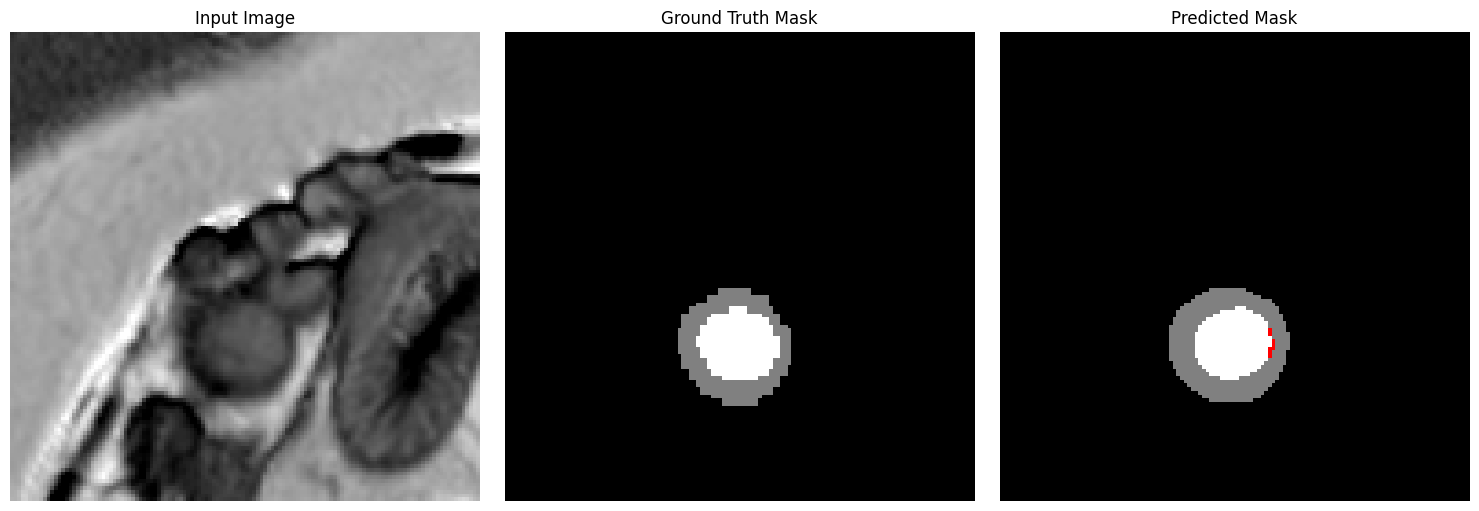

 45%|████▌     | 36/80 [00:19<00:19,  2.23it/s]

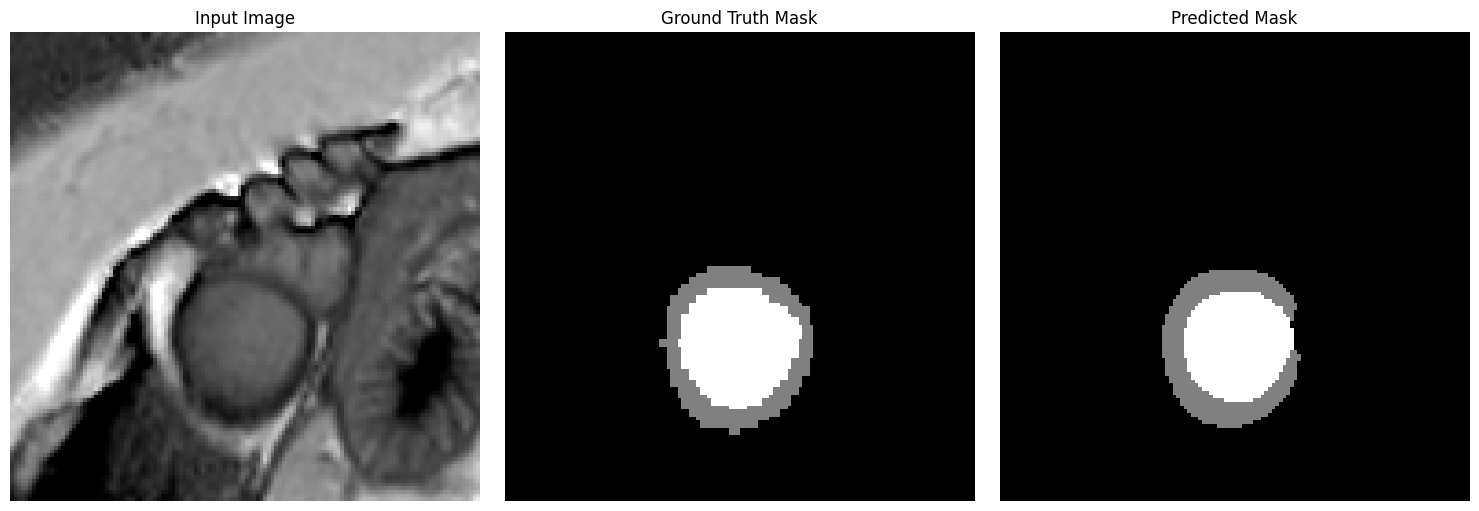

 46%|████▋     | 37/80 [00:19<00:18,  2.31it/s]

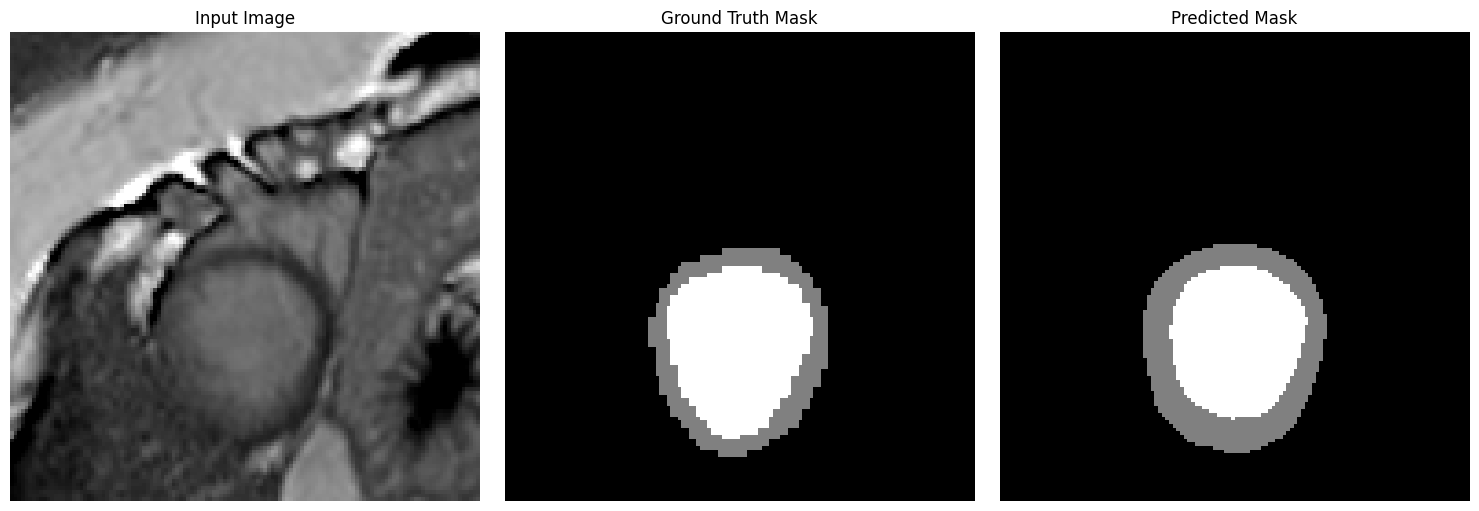

 48%|████▊     | 38/80 [00:20<00:18,  2.32it/s]

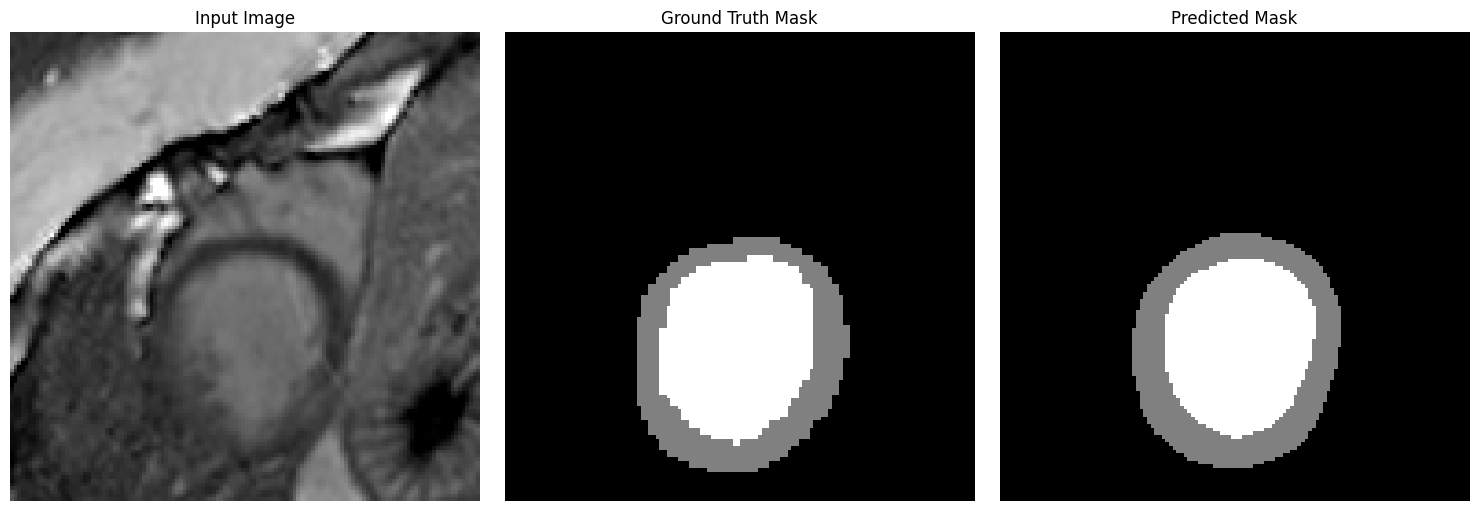

 49%|████▉     | 39/80 [00:20<00:17,  2.35it/s]

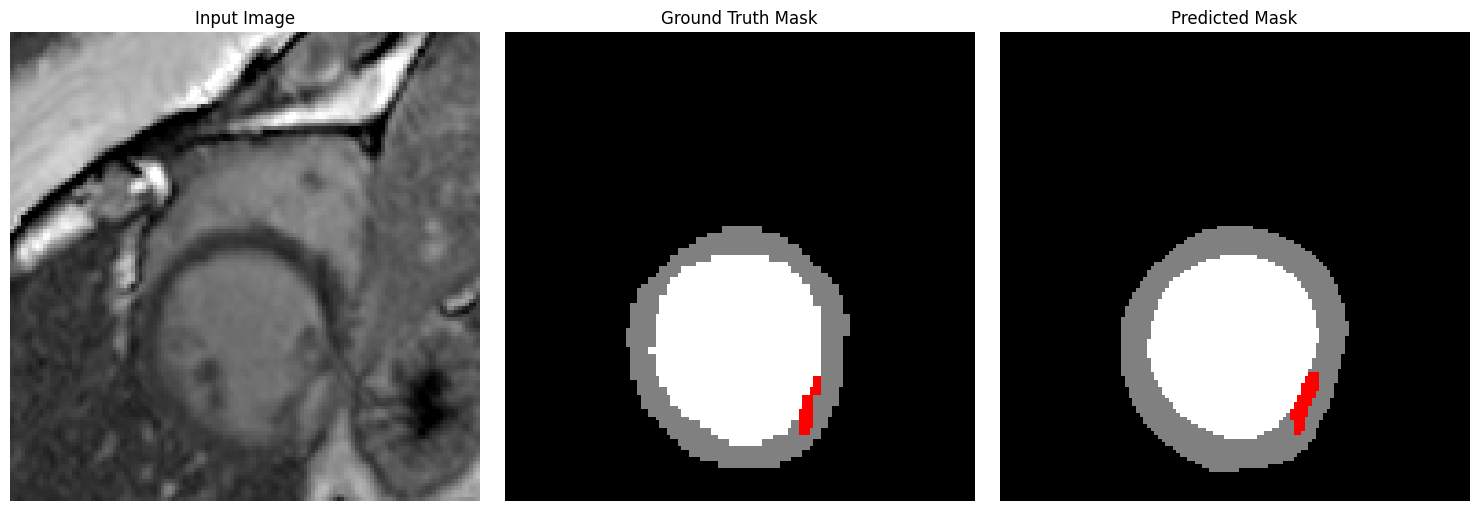

 50%|█████     | 40/80 [00:20<00:16,  2.36it/s]

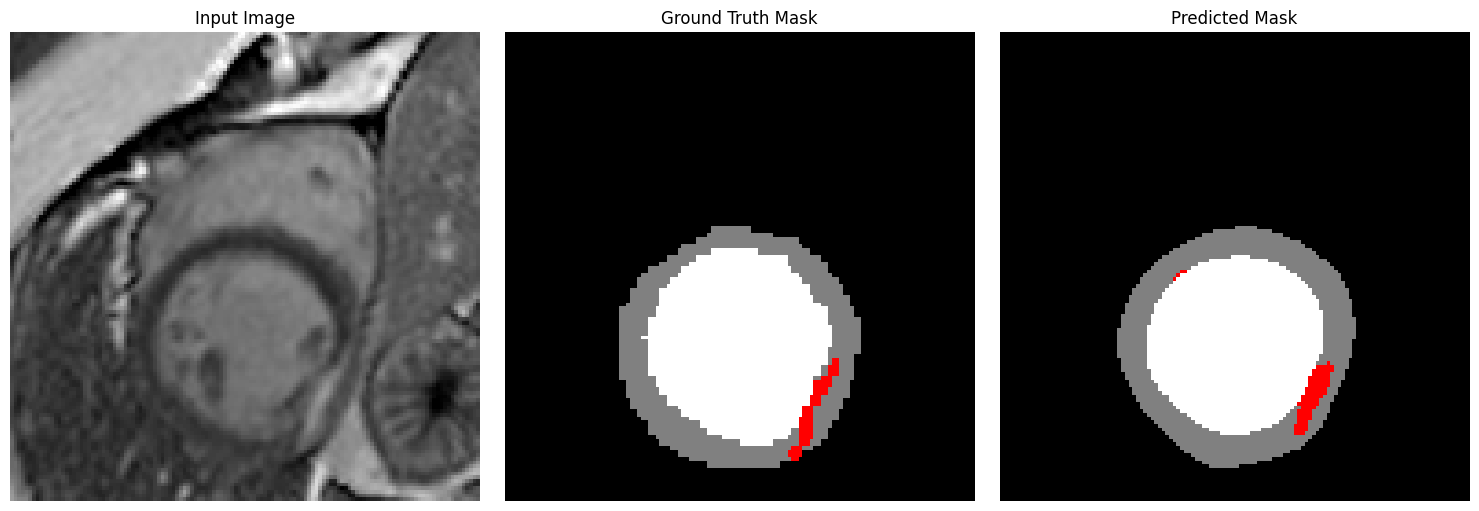

 51%|█████▏    | 41/80 [00:21<00:16,  2.34it/s]

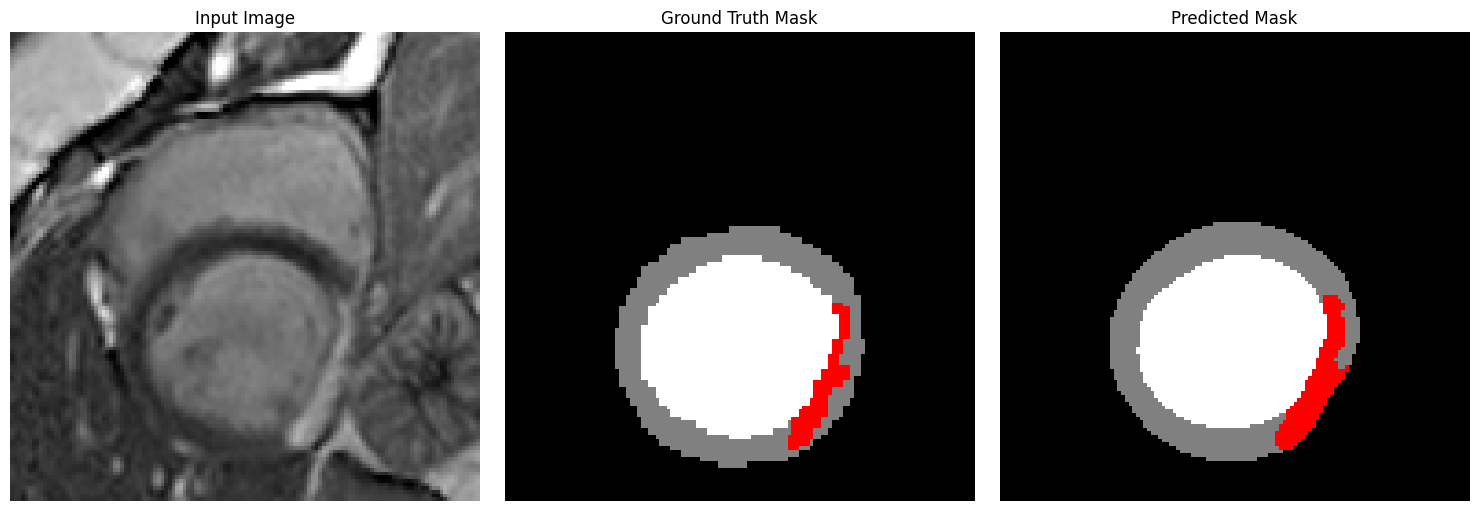

 52%|█████▎    | 42/80 [00:21<00:16,  2.36it/s]

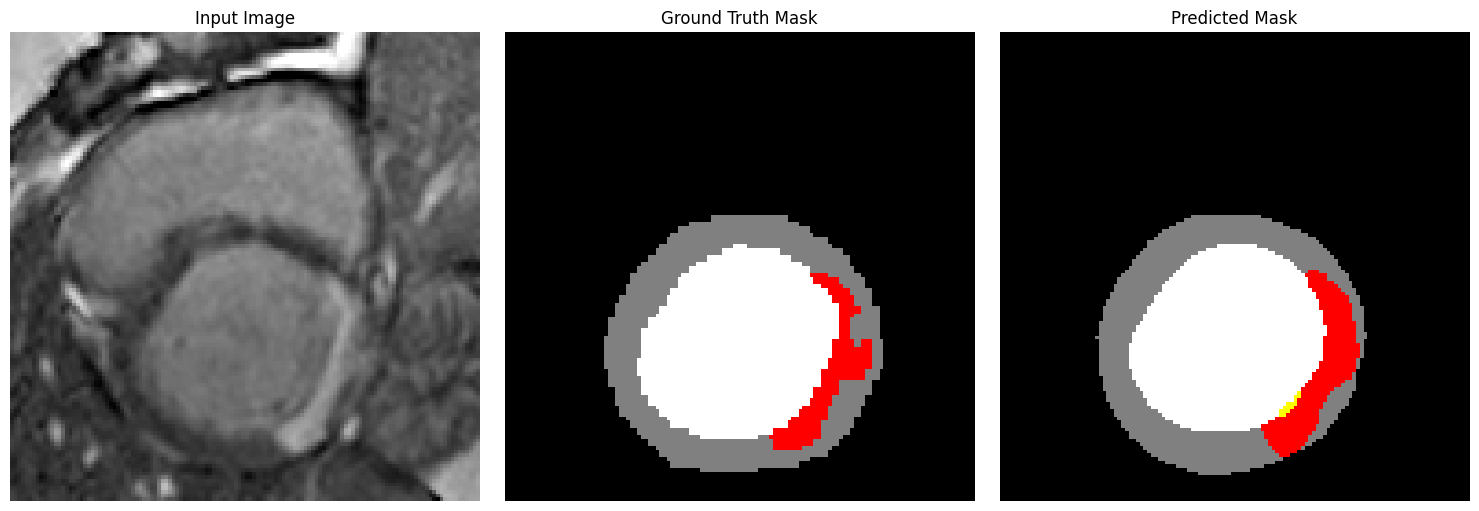

 54%|█████▍    | 43/80 [00:22<00:15,  2.36it/s]

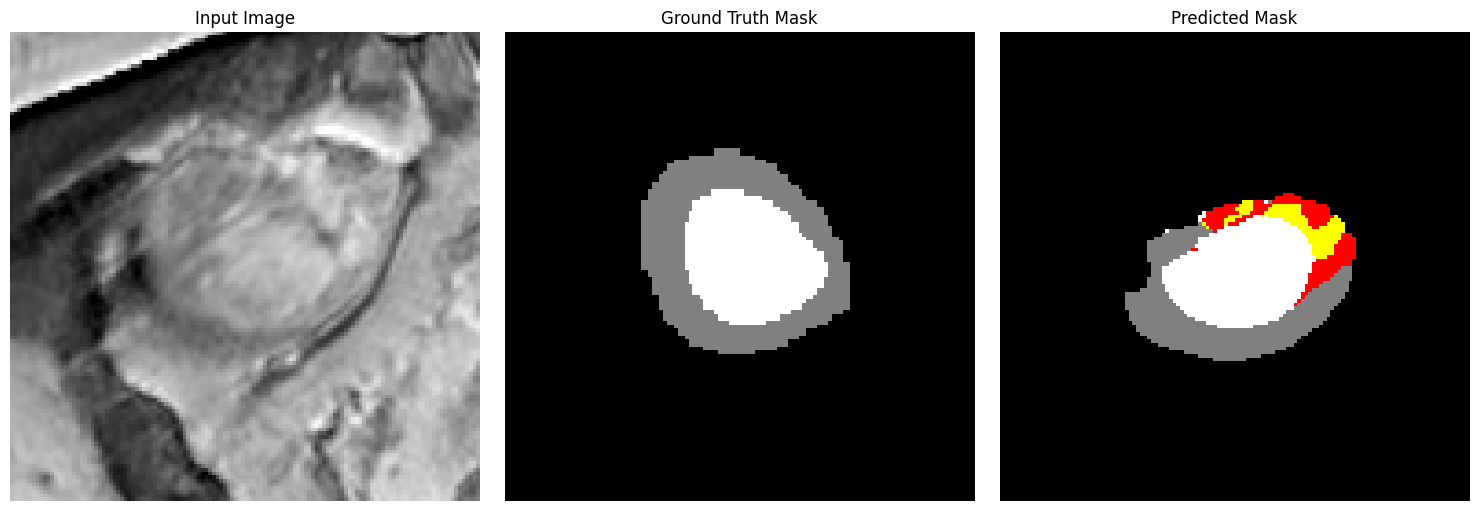

 55%|█████▌    | 44/80 [00:22<00:15,  2.39it/s]

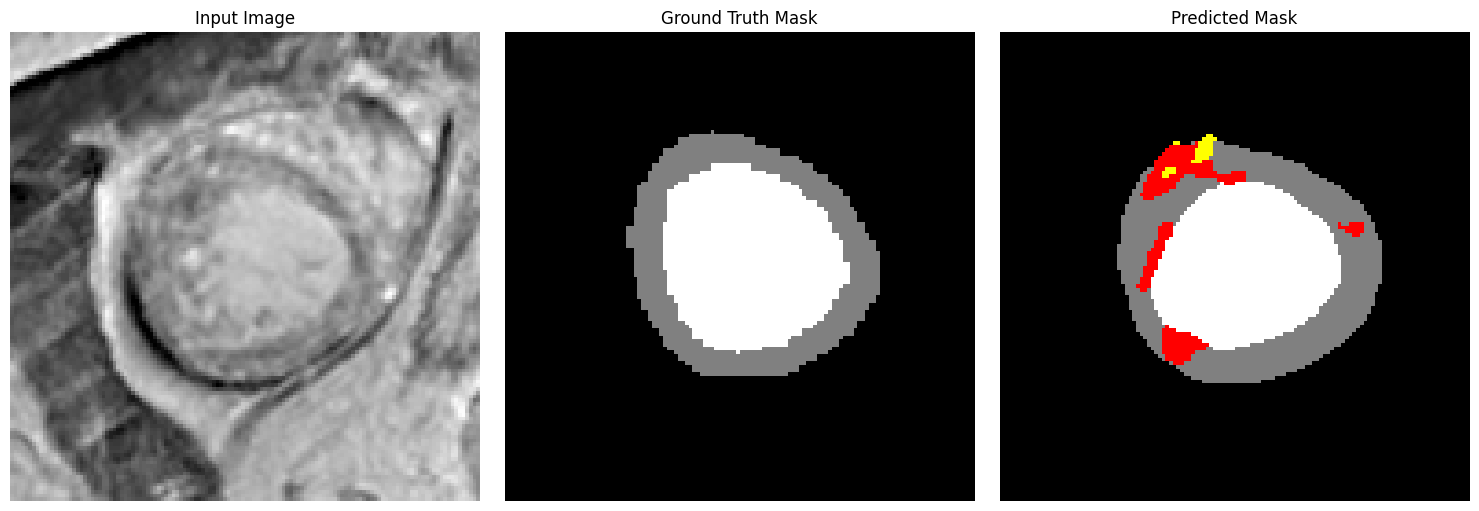

 56%|█████▋    | 45/80 [00:22<00:14,  2.39it/s]

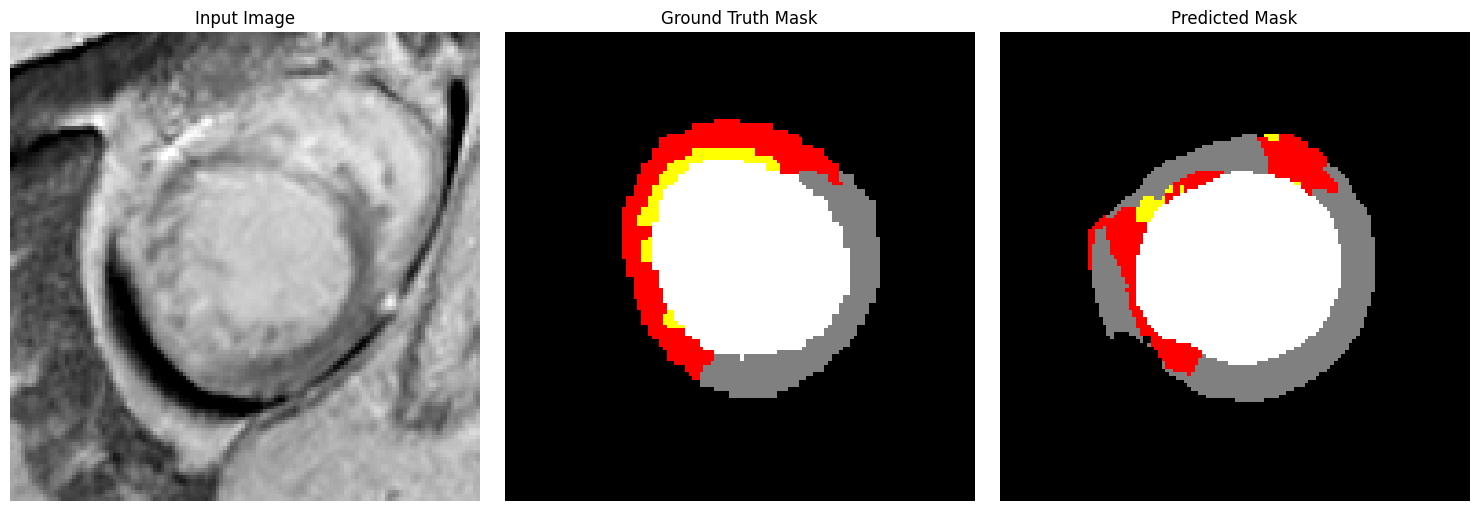

 57%|█████▊    | 46/80 [00:23<00:14,  2.36it/s]

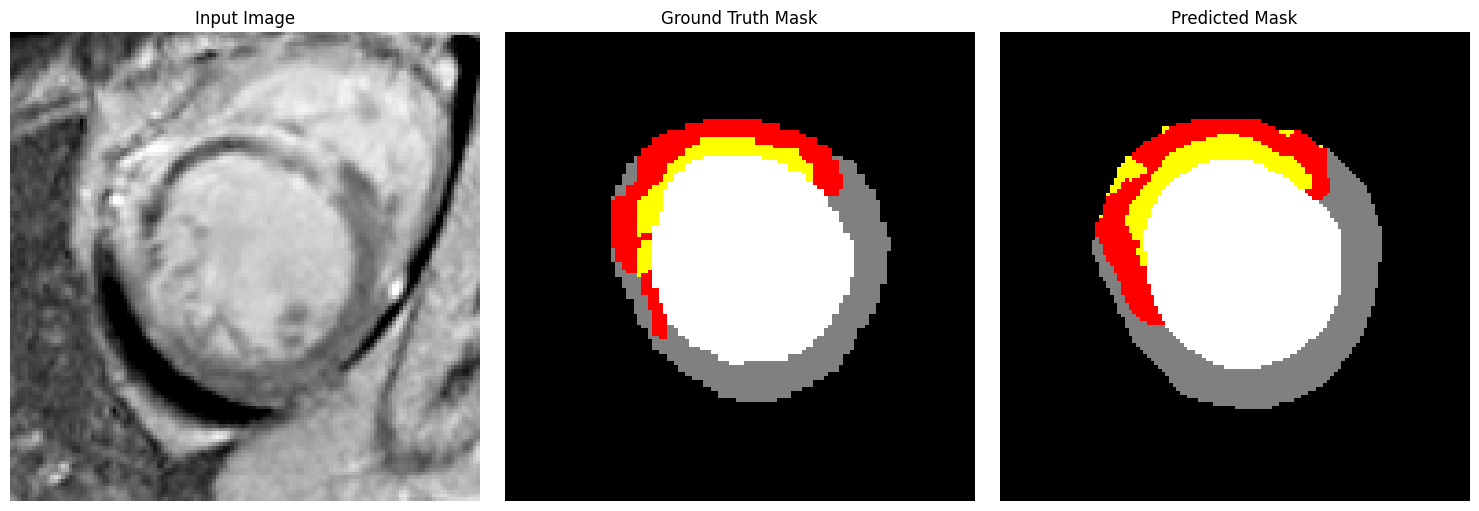

 59%|█████▉    | 47/80 [00:23<00:13,  2.39it/s]

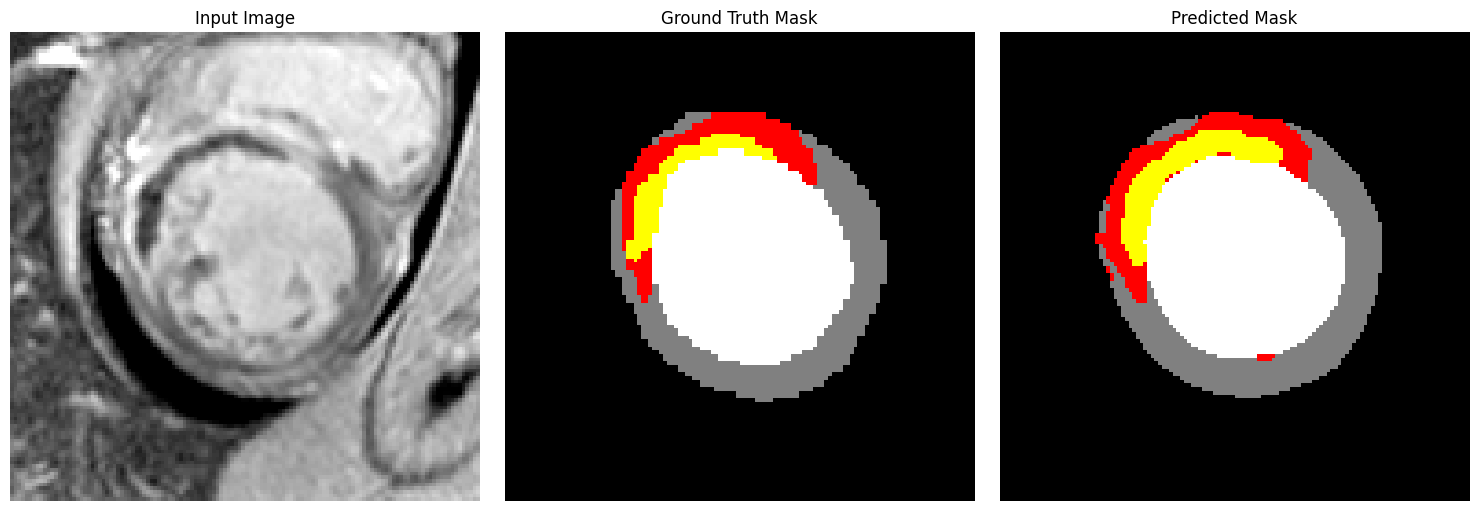

 60%|██████    | 48/80 [00:24<00:13,  2.36it/s]

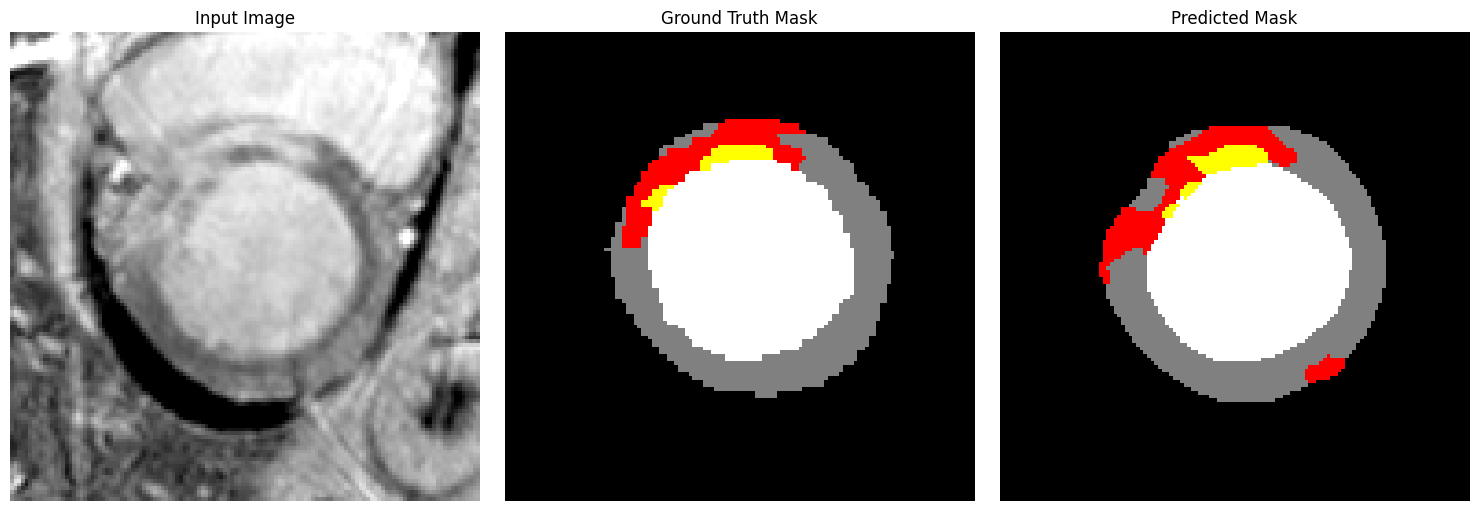

 61%|██████▏   | 49/80 [00:24<00:13,  2.37it/s]

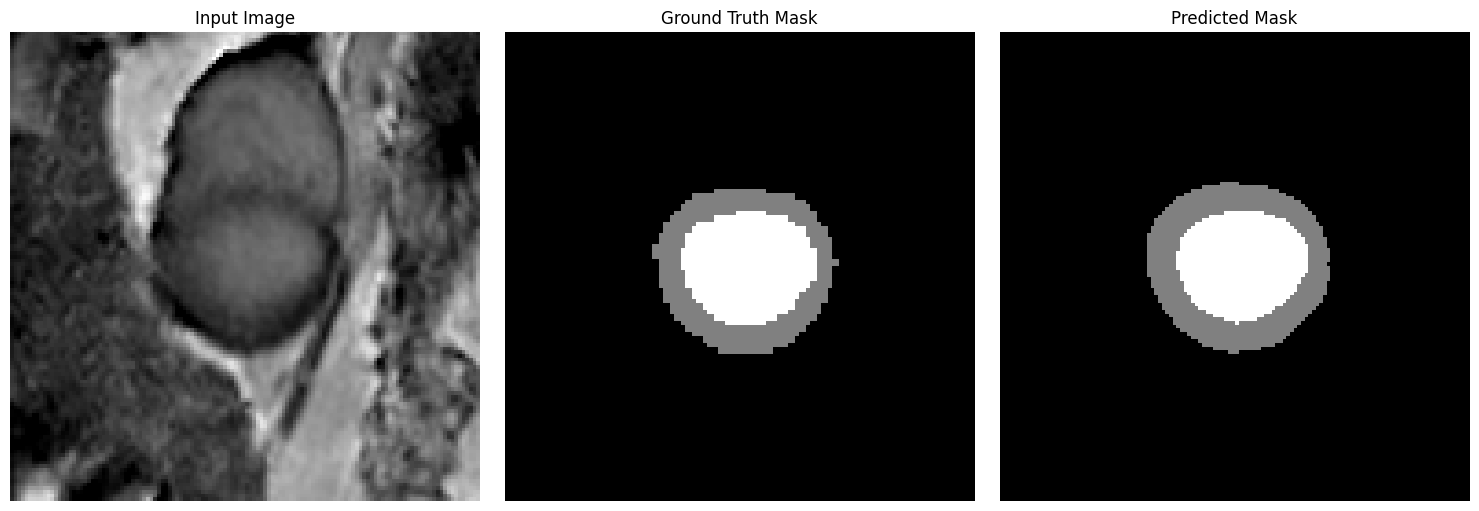

 62%|██████▎   | 50/80 [00:25<00:12,  2.38it/s]

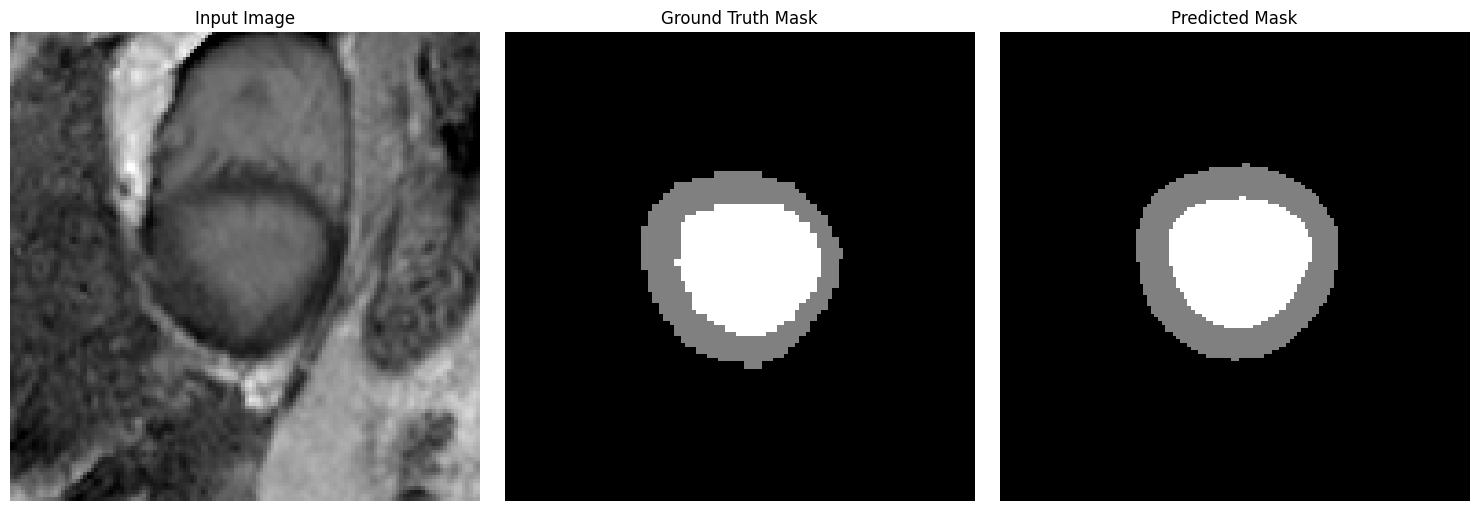

 64%|██████▍   | 51/80 [00:26<00:16,  1.72it/s]

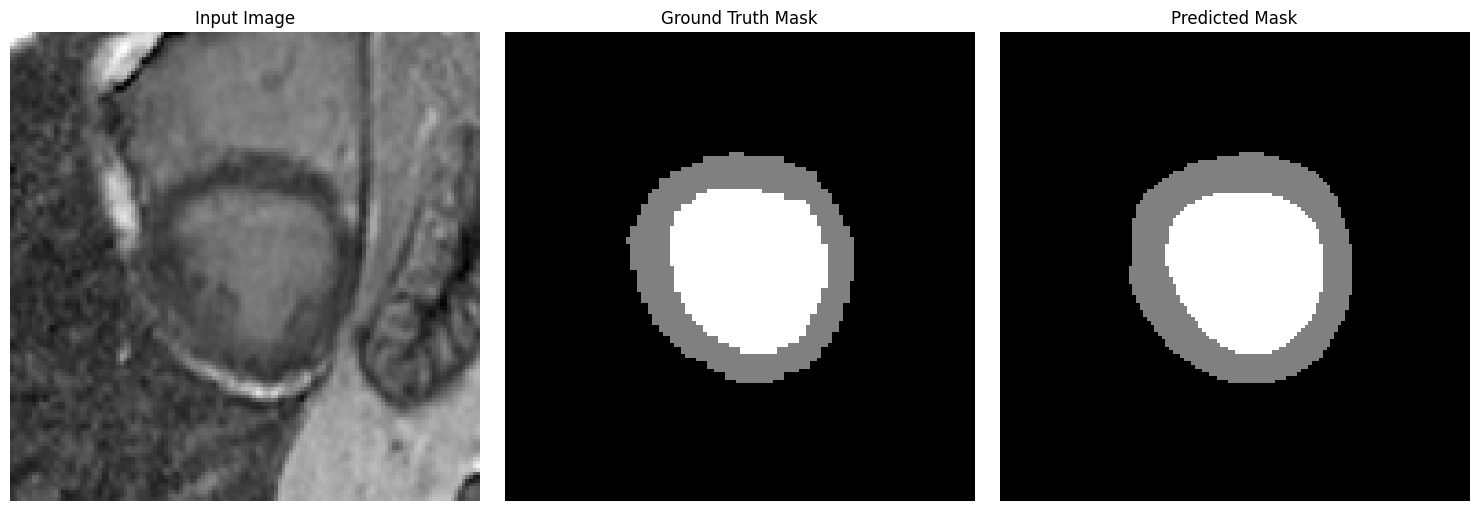

 65%|██████▌   | 52/80 [00:26<00:14,  1.87it/s]

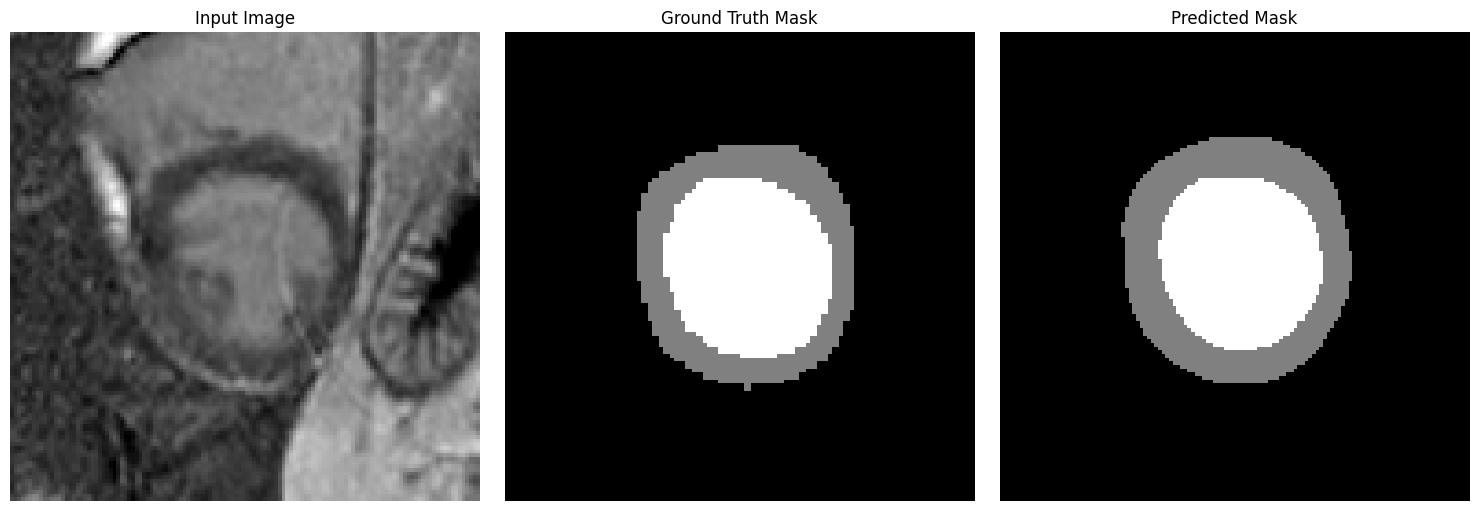

 66%|██████▋   | 53/80 [00:26<00:13,  1.99it/s]

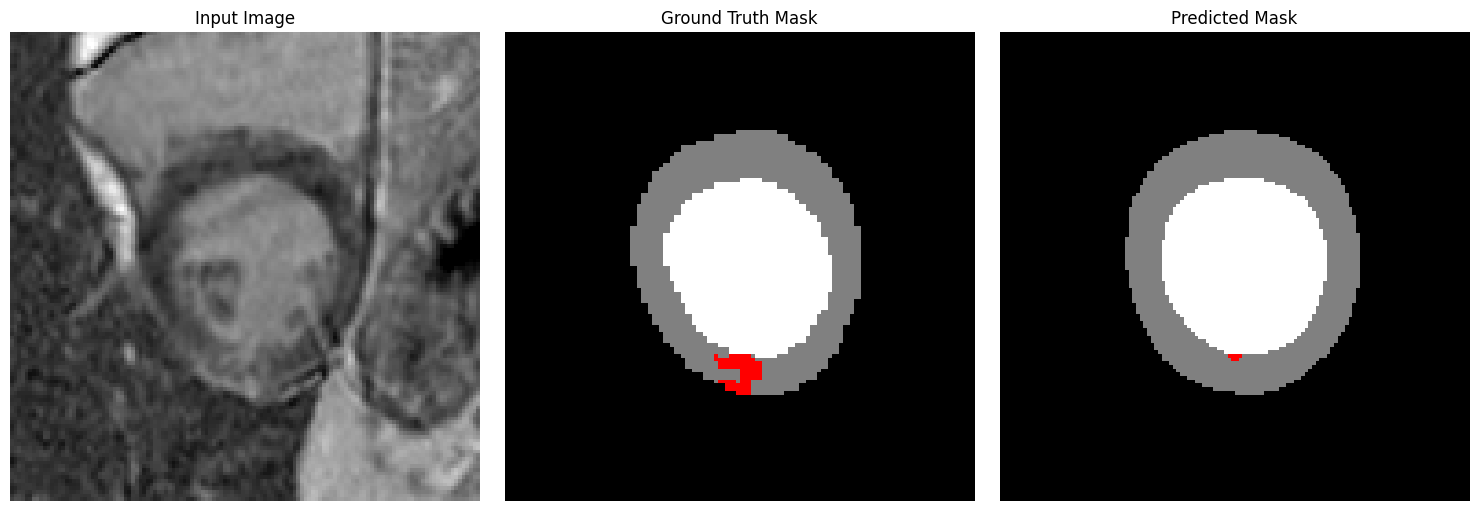

 68%|██████▊   | 54/80 [00:27<00:12,  2.02it/s]

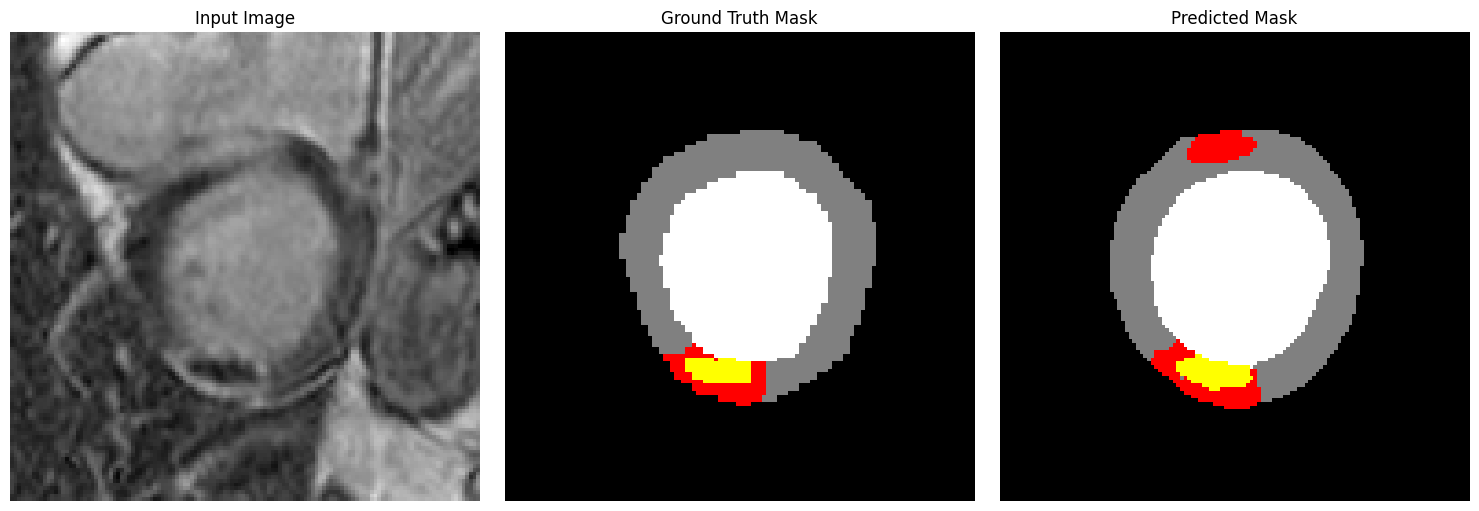

 69%|██████▉   | 55/80 [00:27<00:13,  1.89it/s]

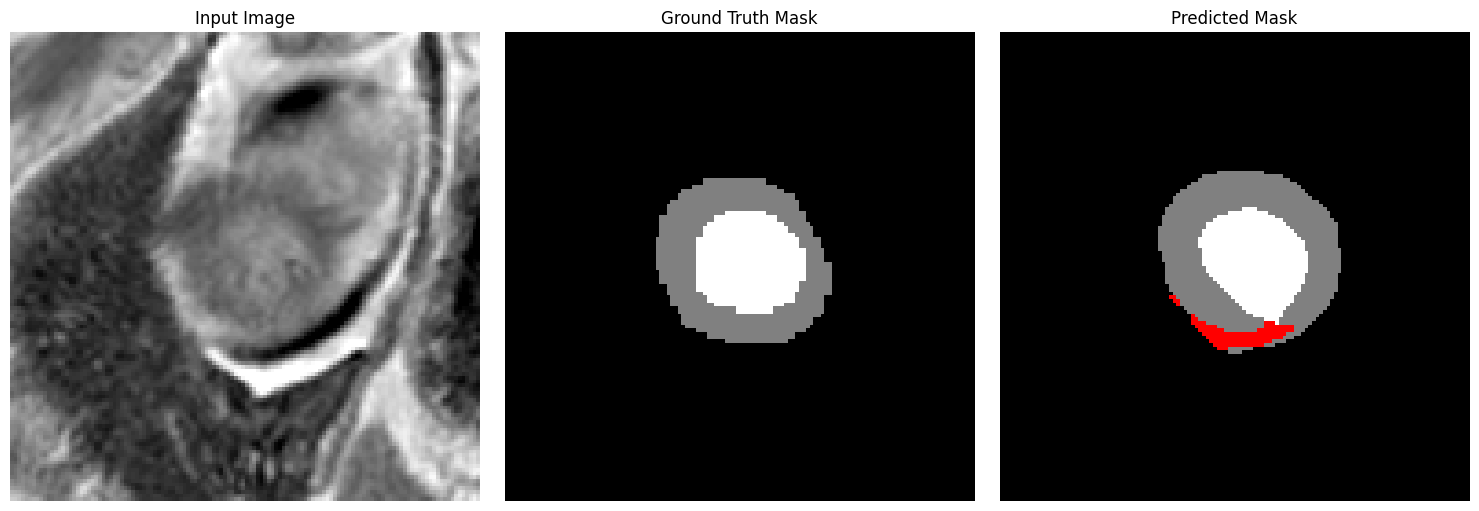

 70%|███████   | 56/80 [00:28<00:13,  1.78it/s]

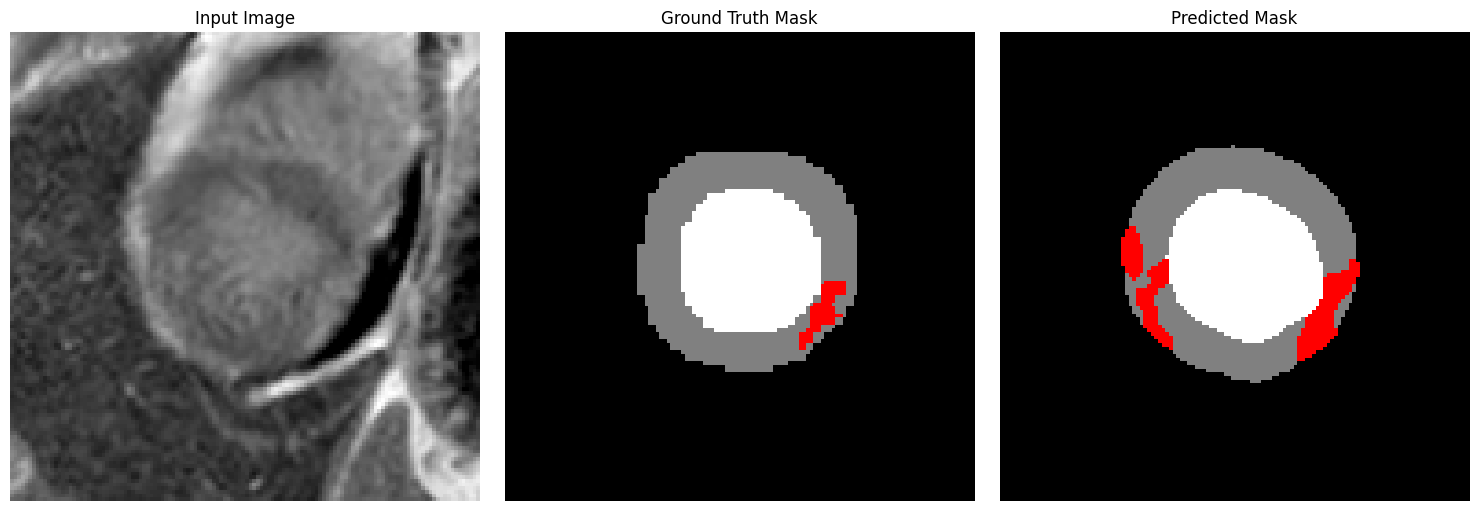

 71%|███████▏  | 57/80 [00:29<00:13,  1.74it/s]

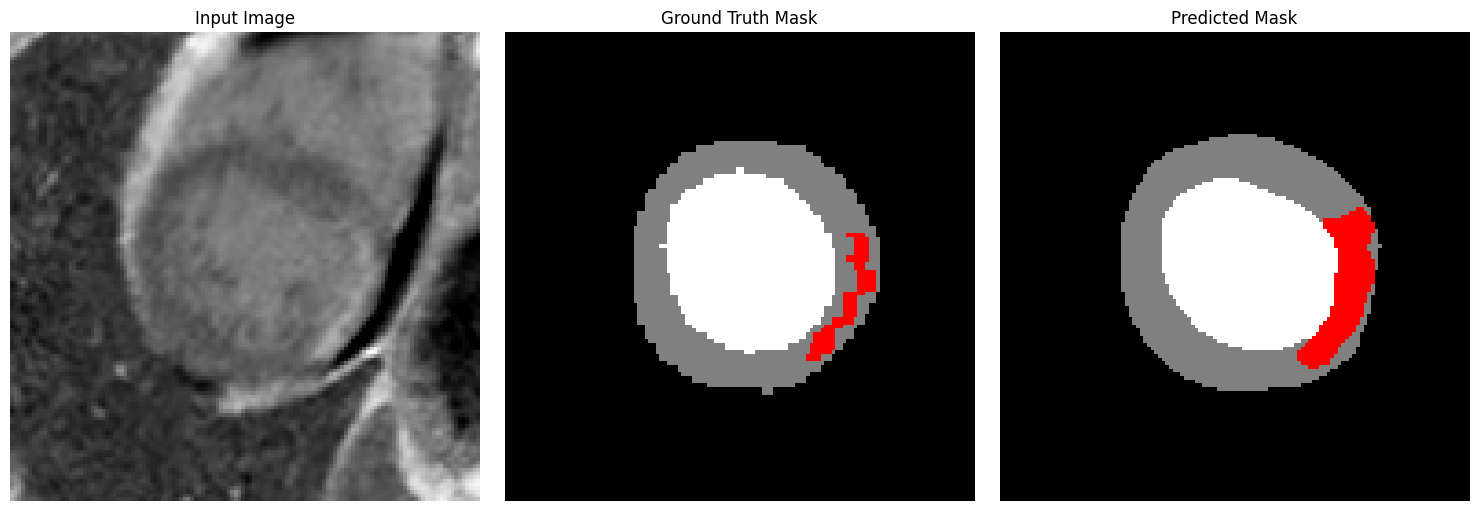

 72%|███████▎  | 58/80 [00:29<00:12,  1.71it/s]

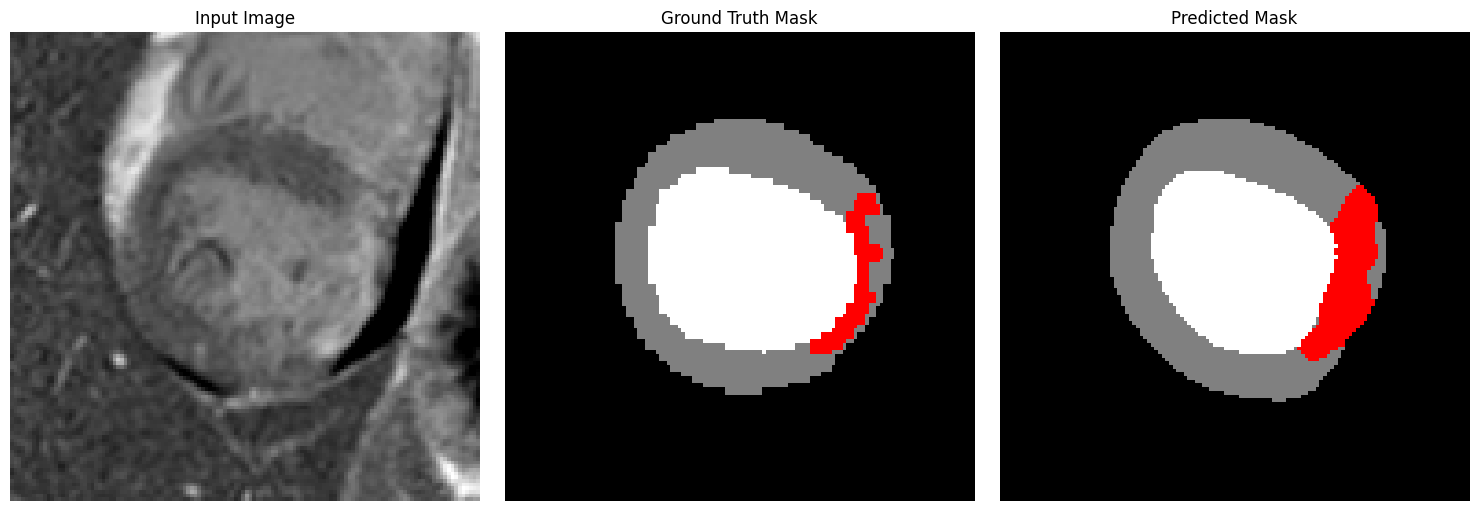

 74%|███████▍  | 59/80 [00:30<00:12,  1.67it/s]

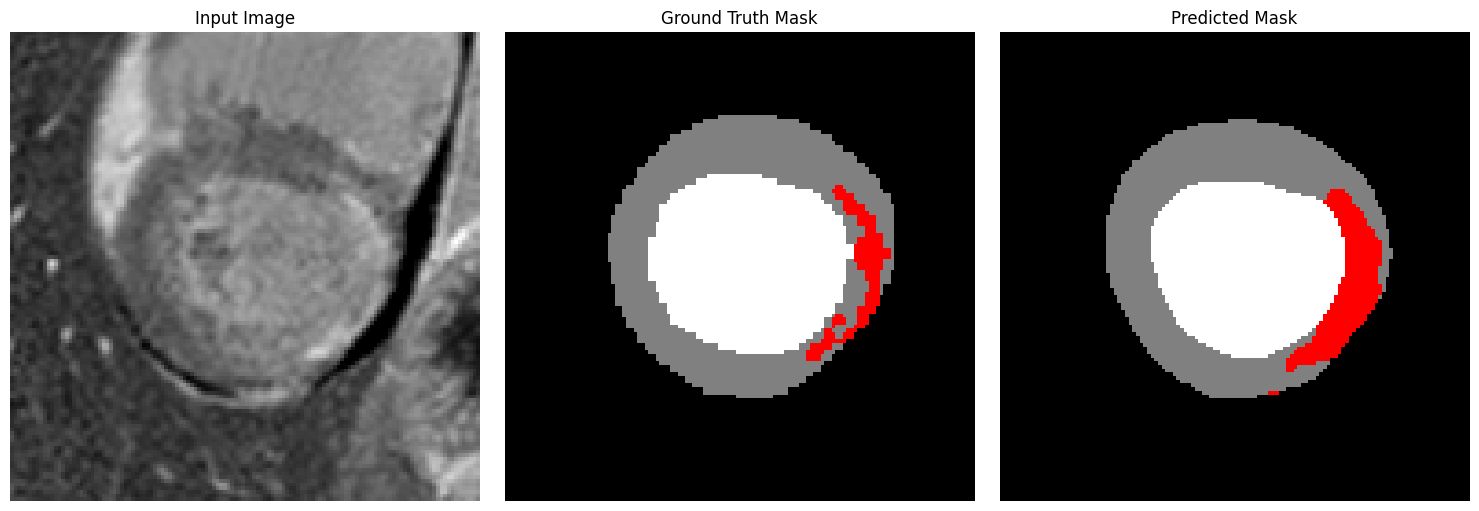

 75%|███████▌  | 60/80 [00:31<00:12,  1.66it/s]

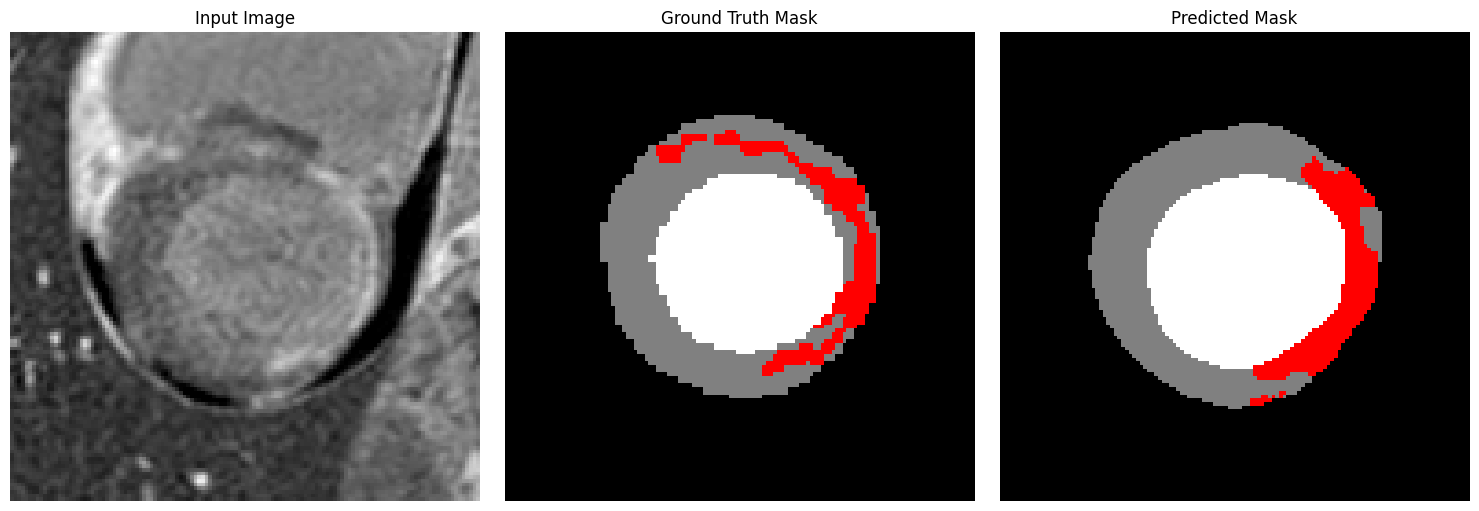

 76%|███████▋  | 61/80 [00:31<00:10,  1.82it/s]

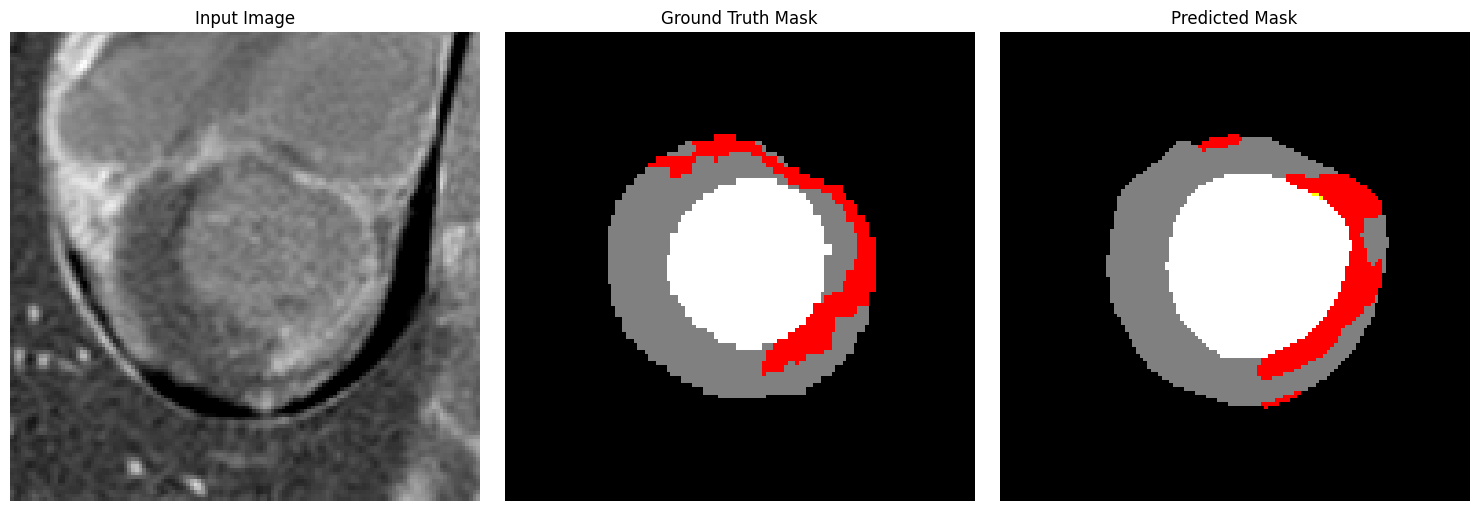

 78%|███████▊  | 62/80 [00:31<00:09,  1.94it/s]

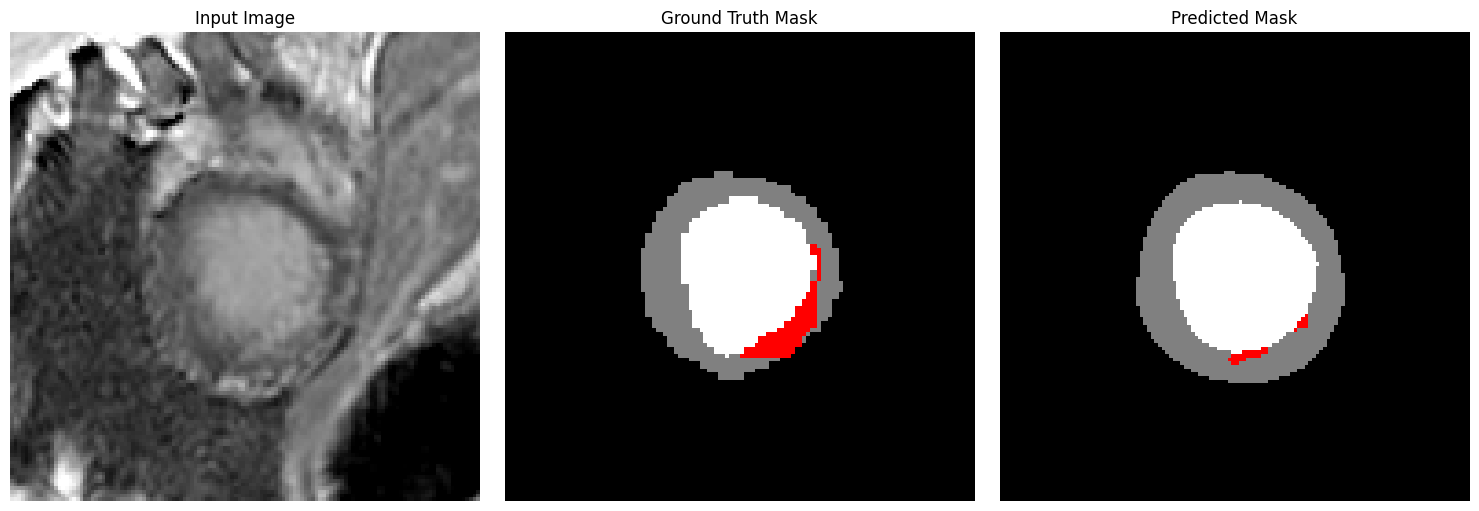

 79%|███████▉  | 63/80 [00:32<00:08,  2.03it/s]

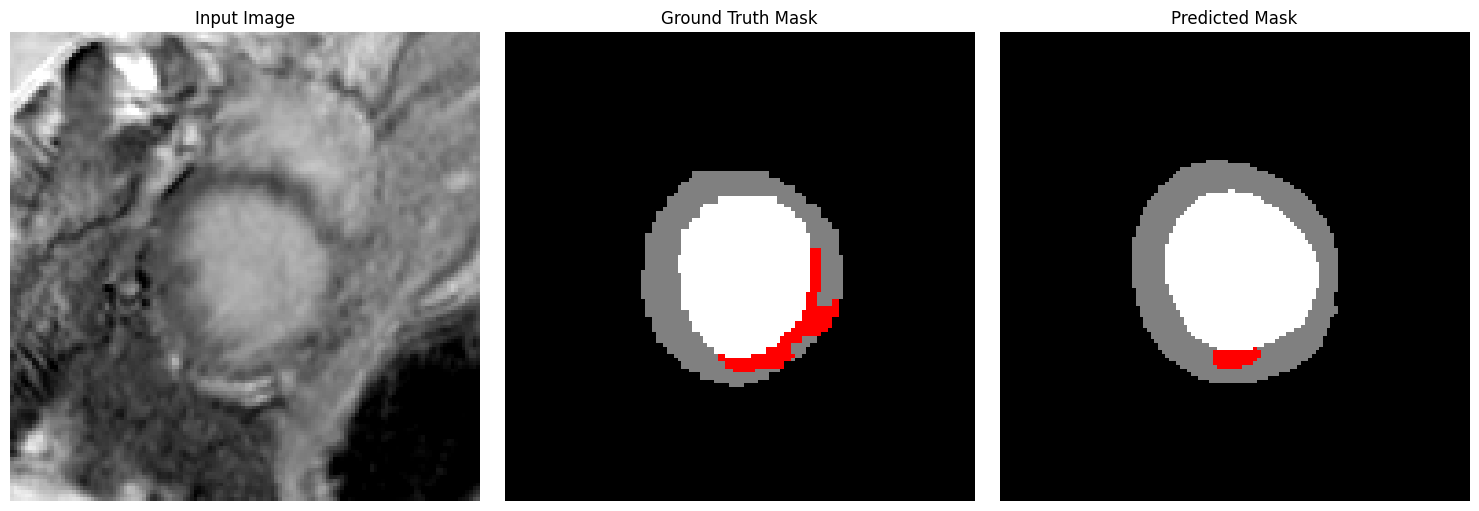

 80%|████████  | 64/80 [00:33<00:09,  1.76it/s]

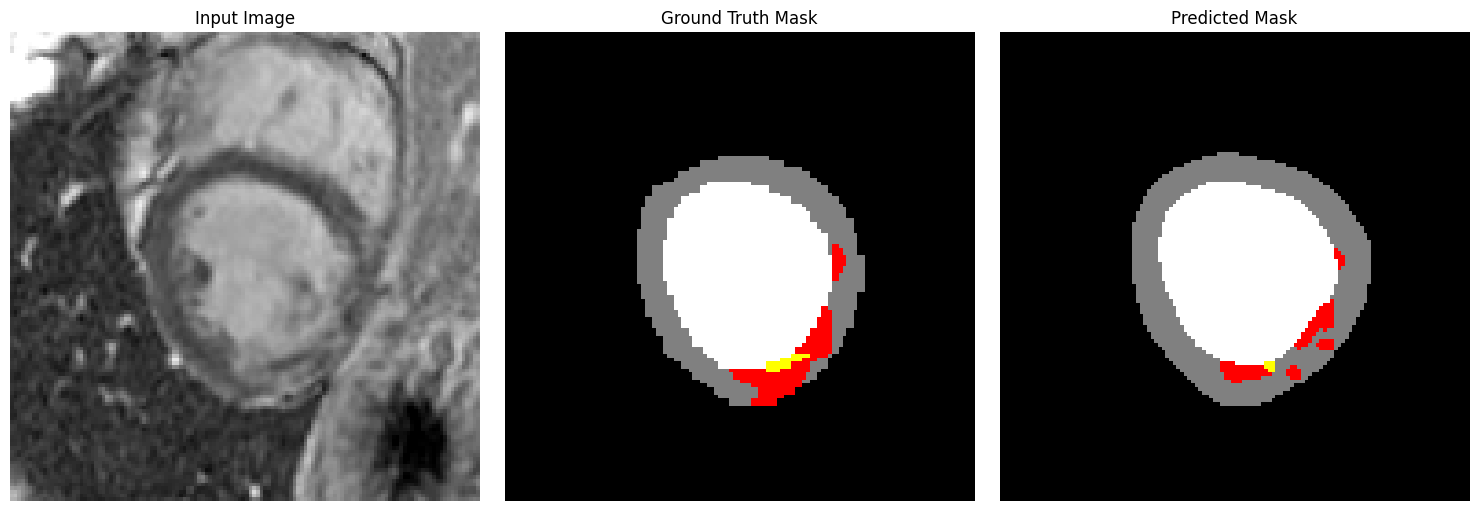

 81%|████████▏ | 65/80 [00:33<00:07,  1.92it/s]

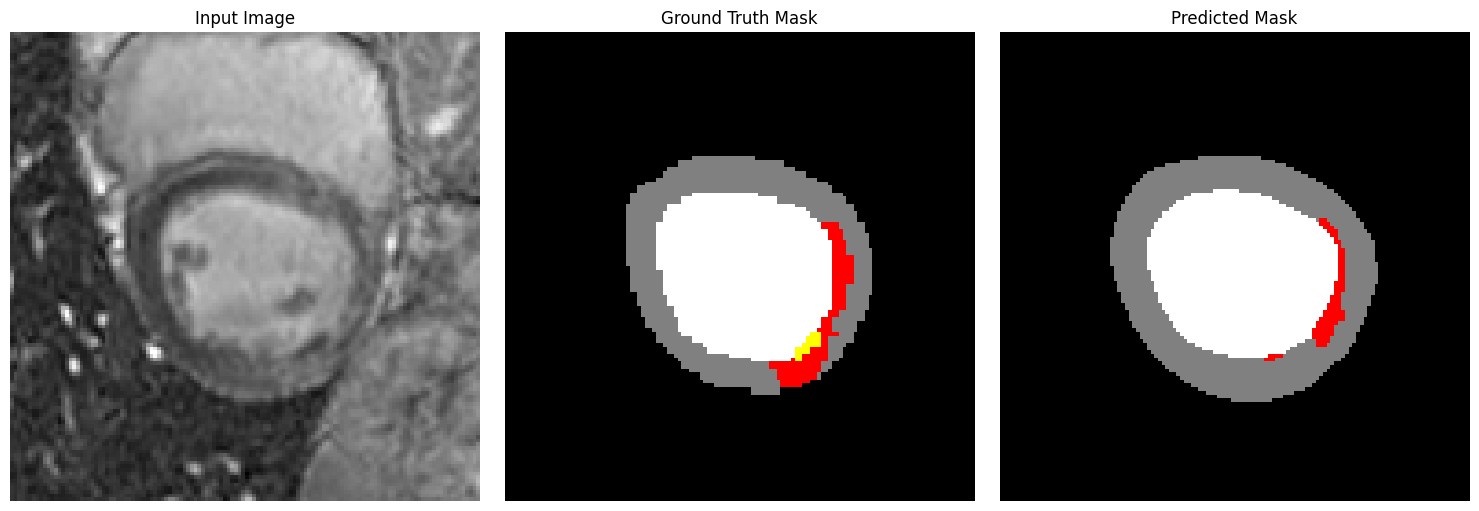

 82%|████████▎ | 66/80 [00:33<00:06,  2.01it/s]

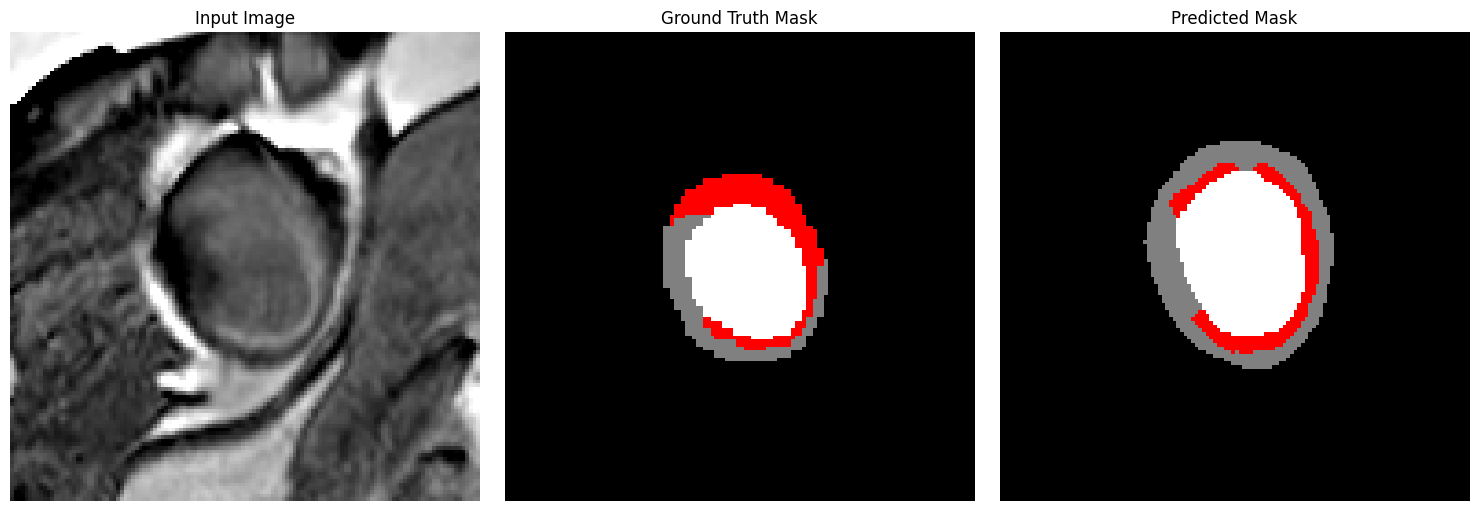

 84%|████████▍ | 67/80 [00:34<00:06,  2.09it/s]

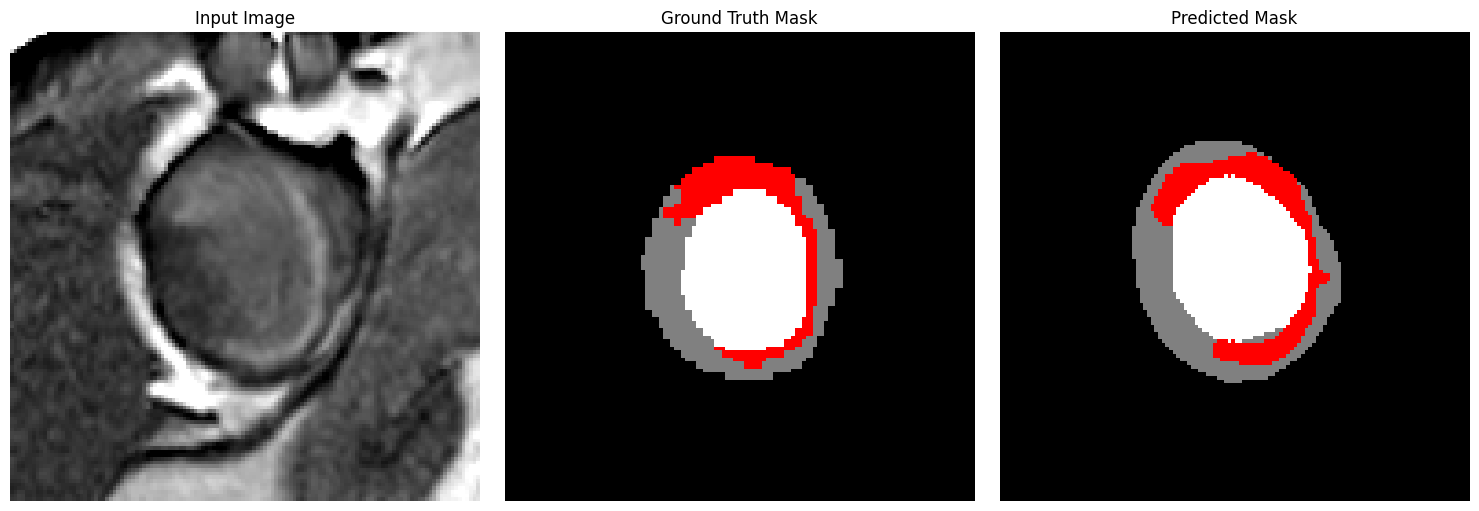

 85%|████████▌ | 68/80 [00:34<00:05,  2.08it/s]

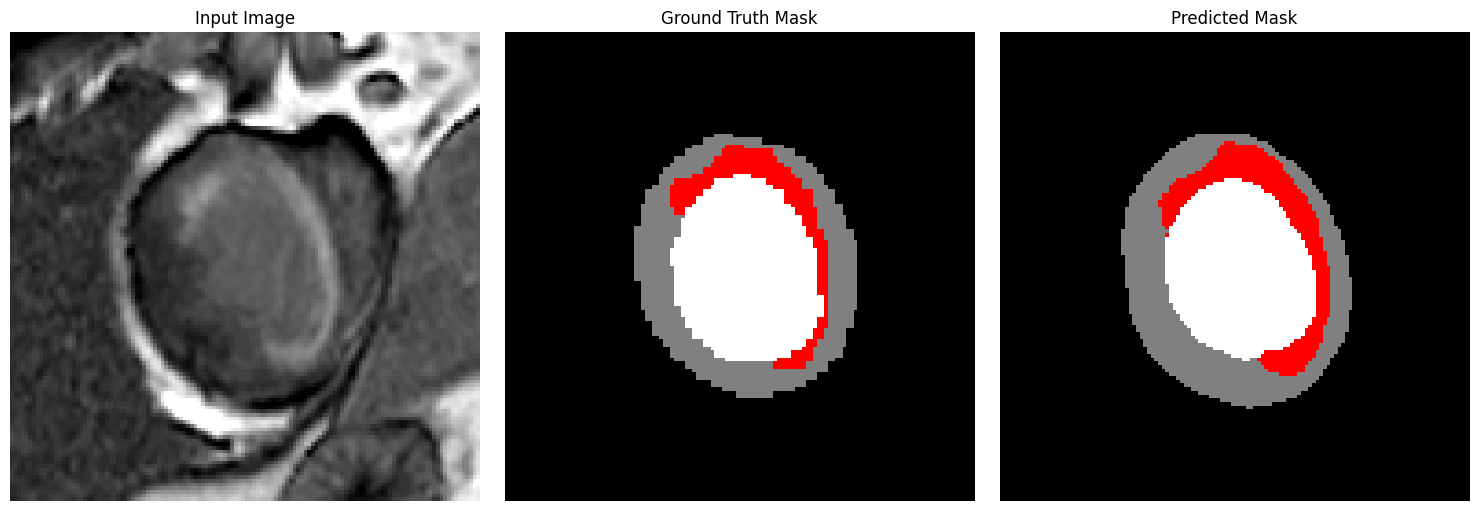

 86%|████████▋ | 69/80 [00:35<00:05,  2.14it/s]

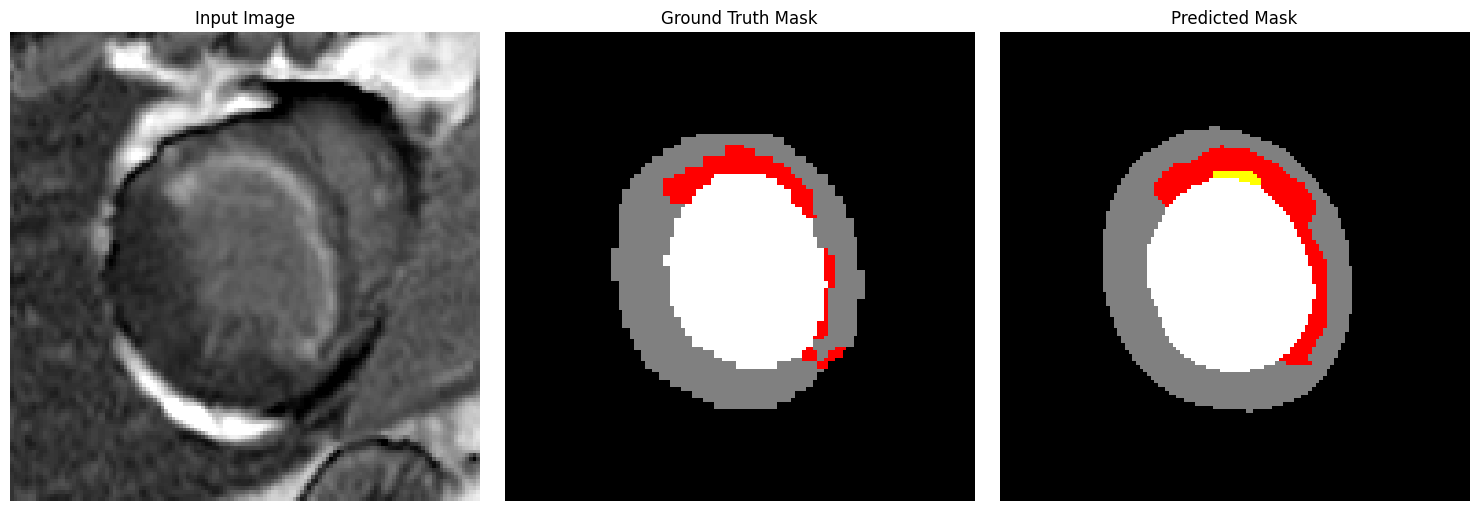

 88%|████████▊ | 70/80 [00:35<00:04,  2.17it/s]

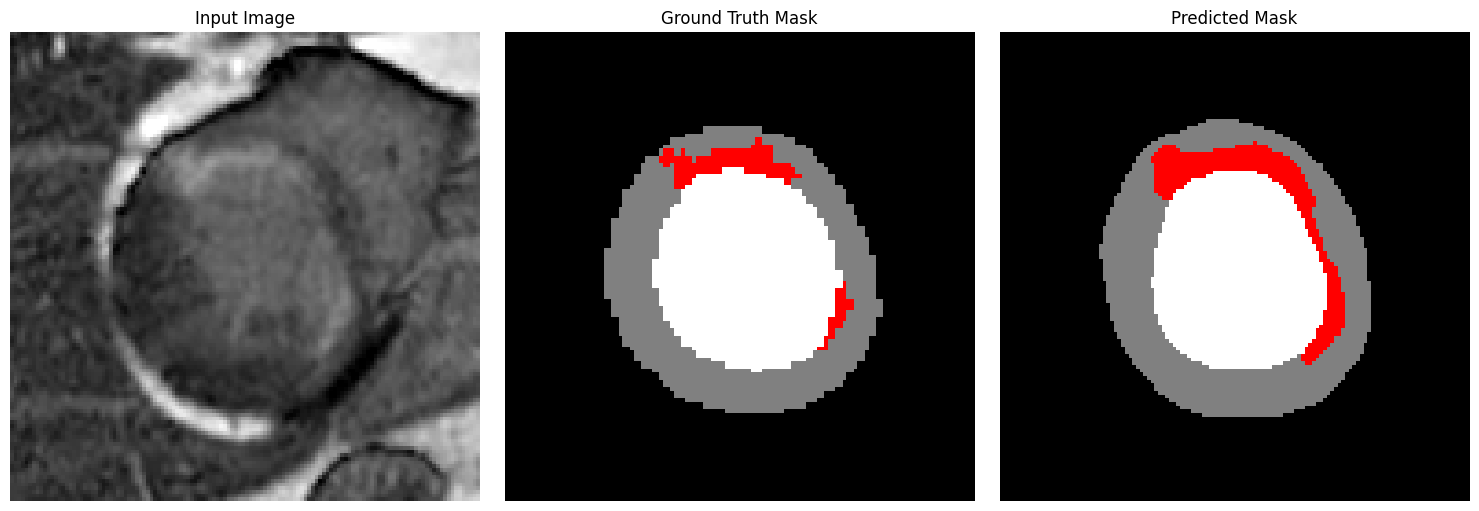

 89%|████████▉ | 71/80 [00:36<00:04,  2.21it/s]

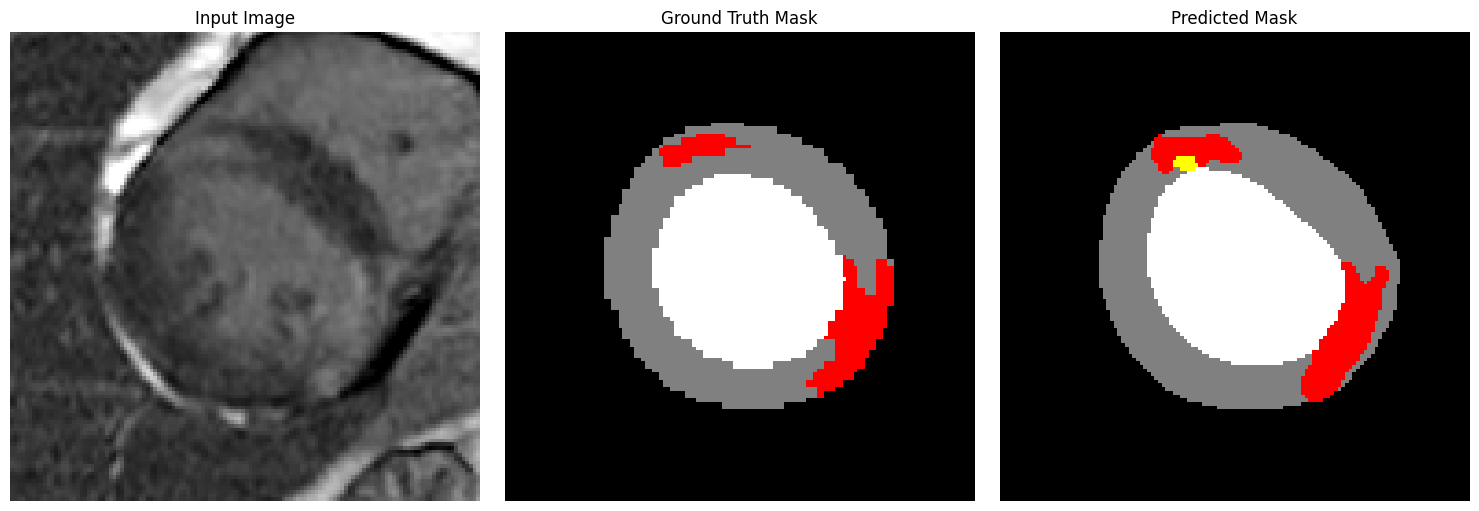

 90%|█████████ | 72/80 [00:36<00:03,  2.25it/s]

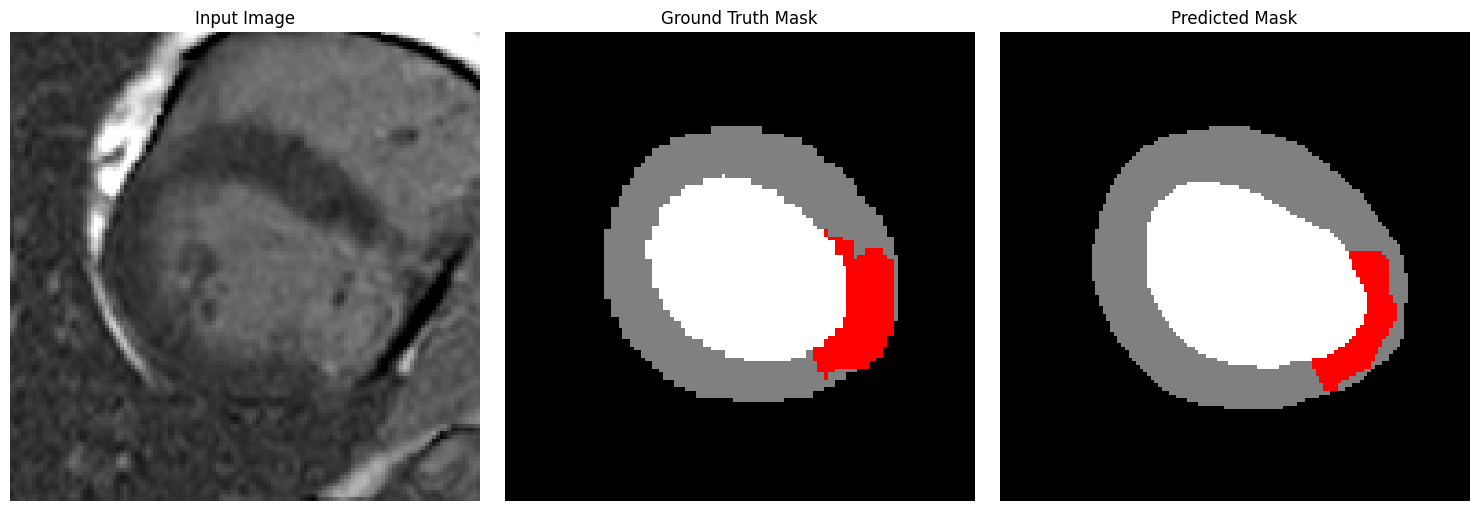

 91%|█████████▏| 73/80 [00:37<00:03,  2.26it/s]

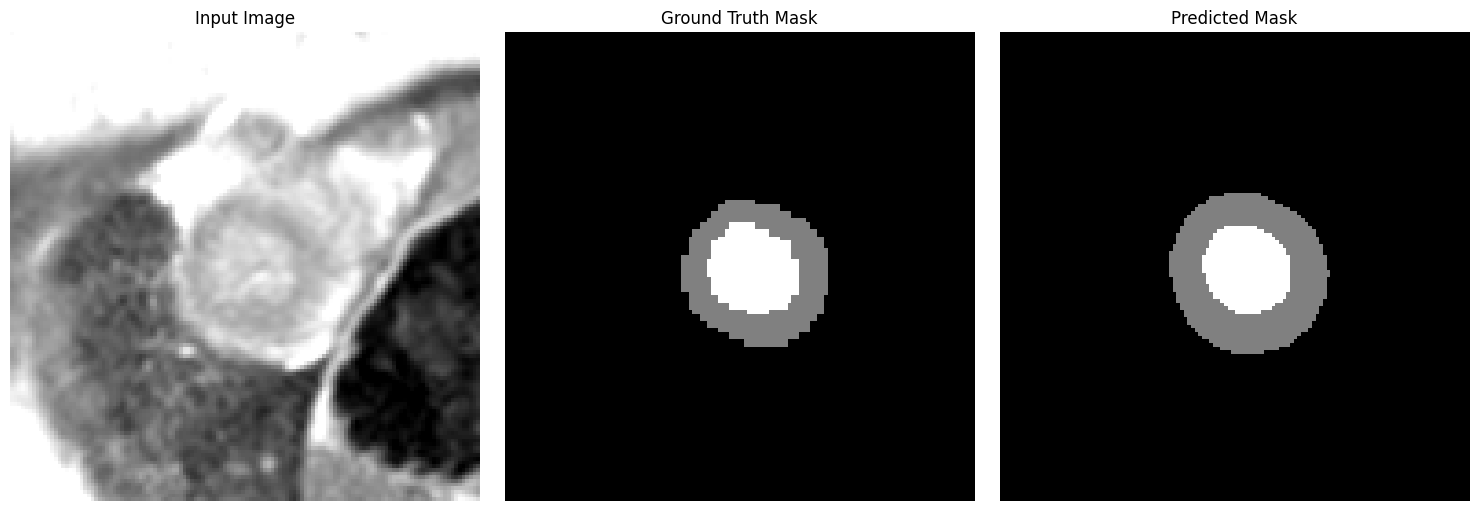

 92%|█████████▎| 74/80 [00:37<00:02,  2.29it/s]

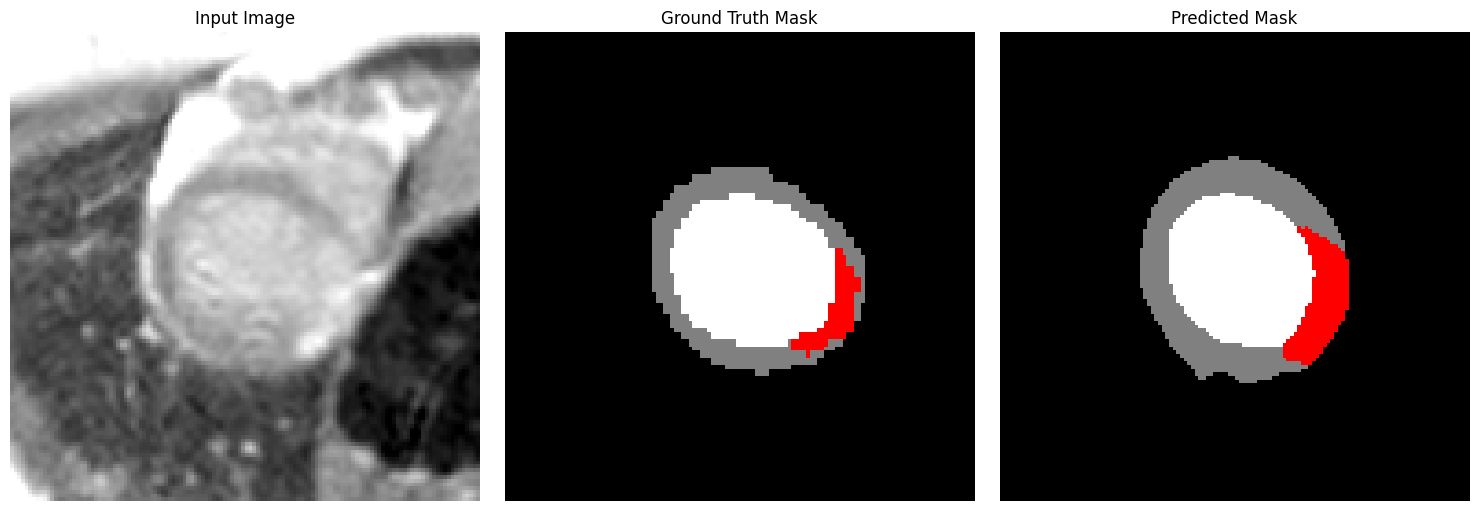

 94%|█████████▍| 75/80 [00:37<00:02,  2.28it/s]

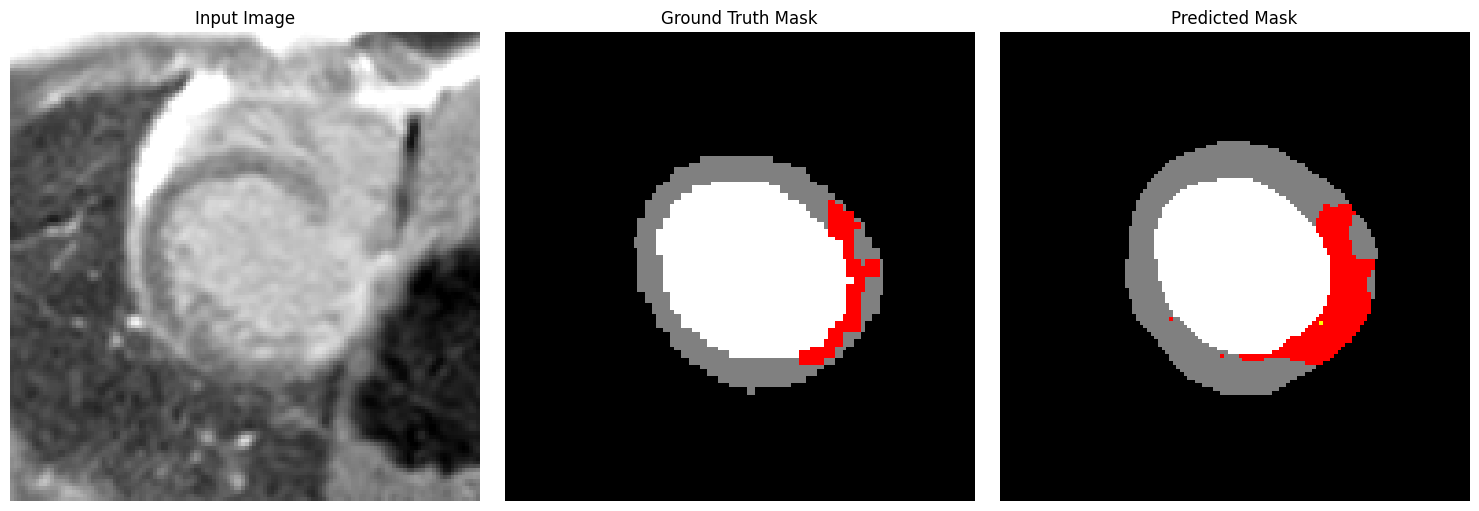

 95%|█████████▌| 76/80 [00:38<00:01,  2.29it/s]

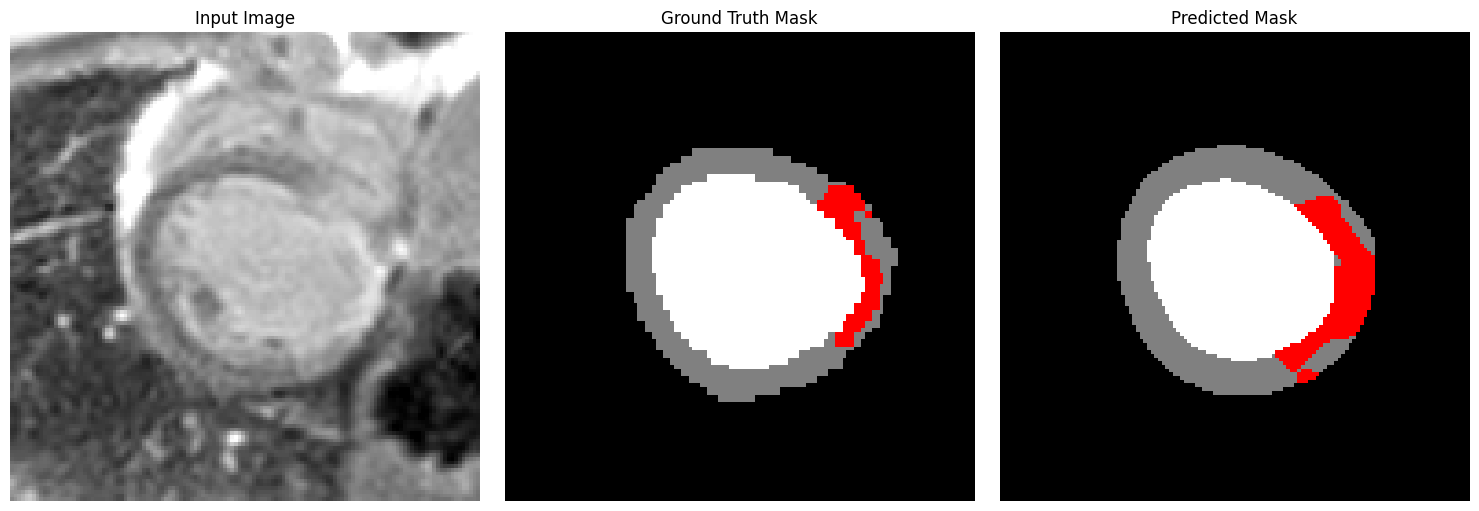

 96%|█████████▋| 77/80 [00:38<00:01,  2.31it/s]

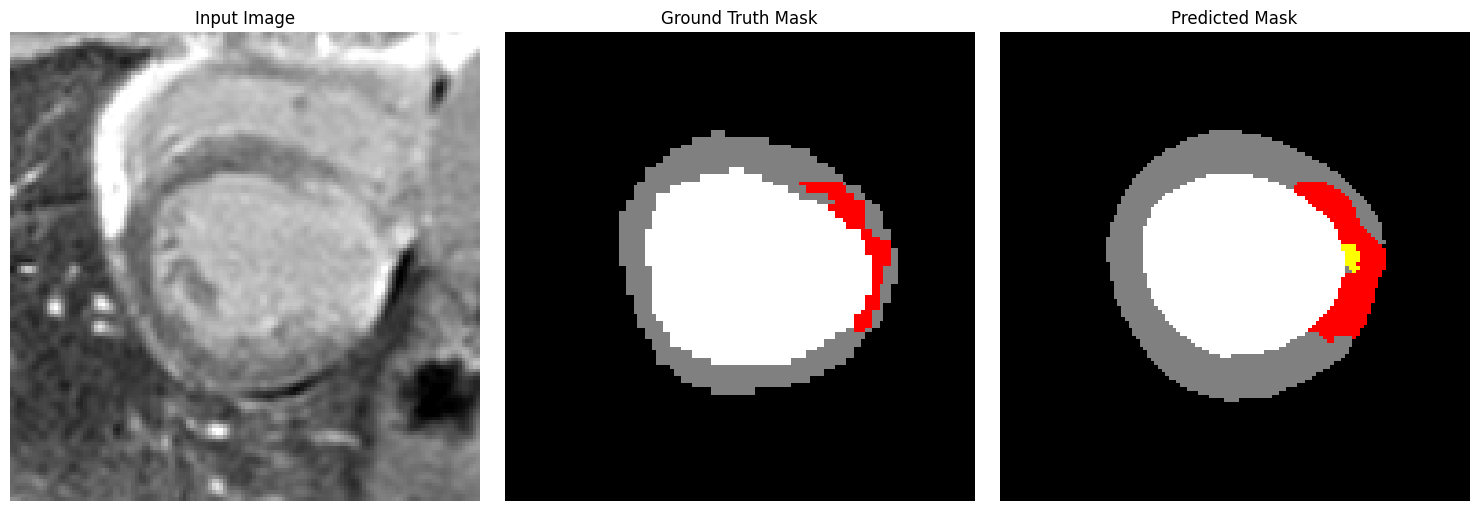

 98%|█████████▊| 78/80 [00:39<00:00,  2.29it/s]

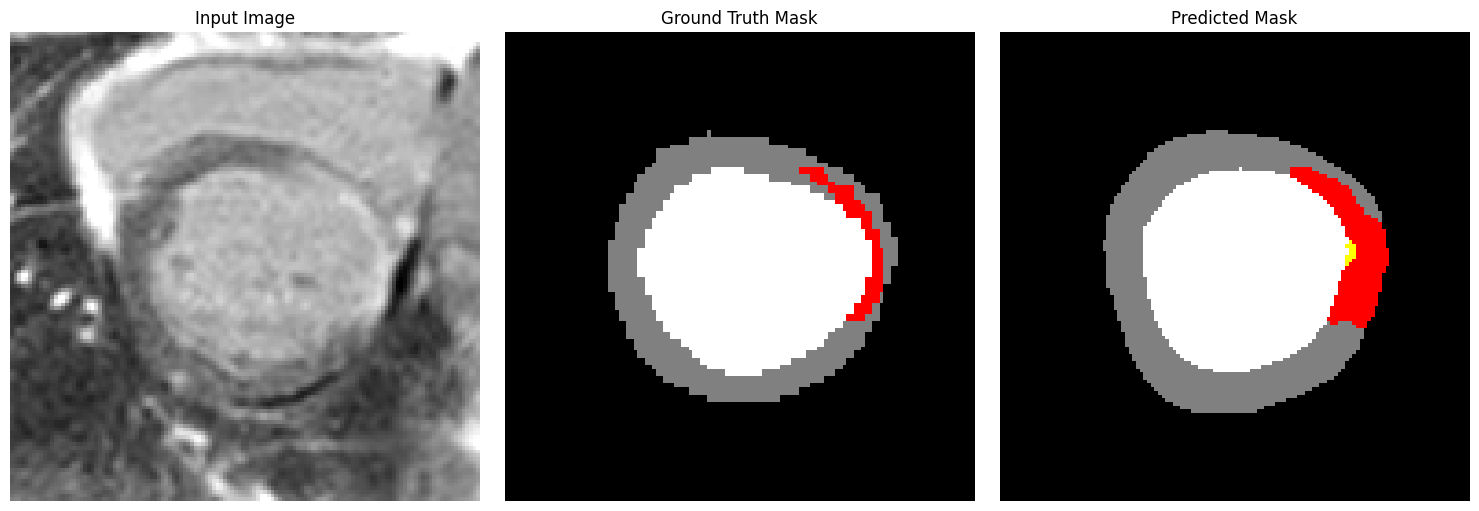

 99%|█████████▉| 79/80 [00:39<00:00,  2.30it/s]

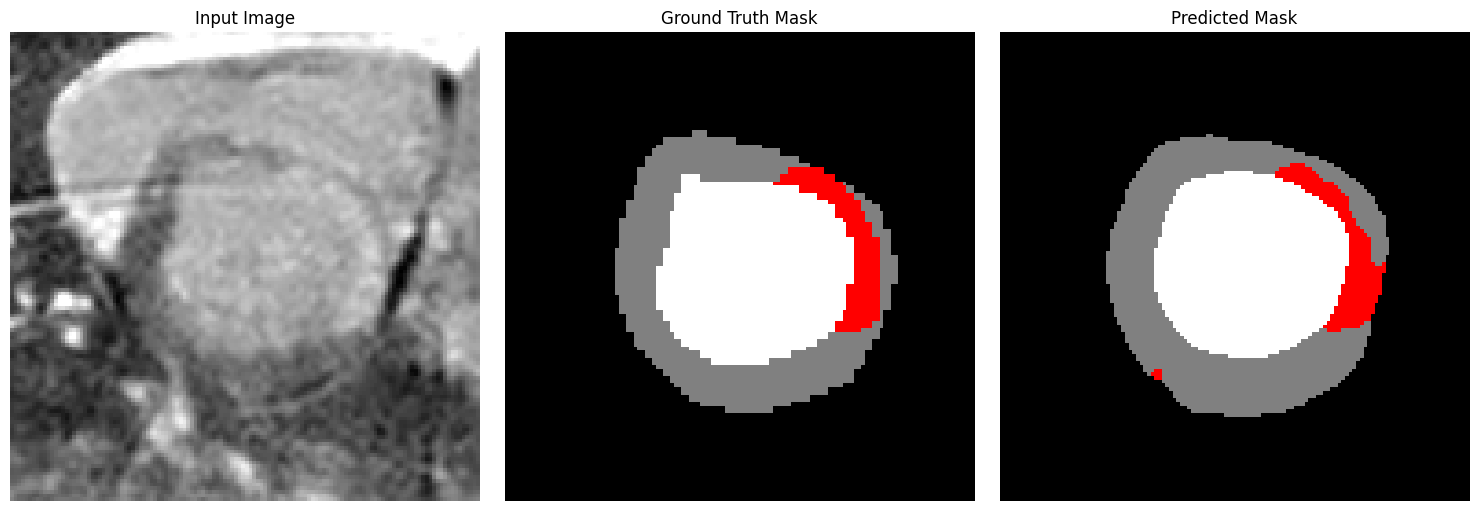

100%|██████████| 80/80 [00:40<00:00,  1.99it/s]


In [ ]:
from tqdm import tqdm  # optional for progress bar

# Loop through the test set
for i in tqdm(range(len(test_images_tensor))):  # tqdm adds a progress bar
    test_img = test_images_tensor[i]
    gt_mask = test_masks_tensor[i]

    # If tensors, convert to numpy
    if isinstance(test_img, tf.Tensor):
        test_img = test_img.numpy()
    if isinstance(gt_mask, tf.Tensor):
        gt_mask = gt_mask.numpy()

    # Add batch dimension
    test_img_expanded = np.expand_dims(test_img, axis=0)
    gt_mask_expanded = np.expand_dims(gt_mask, axis=0)

    # Call your function
    generate_images(model, test_img_expanded, gt_mask_expanded)


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.metrics import MeanIoU

# Define Dice coefficient function
def dice_coefficient(y_true, y_pred, num_classes):
    dice_scores = []
    for i in range(num_classes):
        y_true_i = (y_true == i).astype(np.int32)
        y_pred_i = (y_pred == i).astype(np.int32)

        intersection = np.sum(y_true_i * y_pred_i)
        union = np.sum(y_true_i) + np.sum(y_pred_i)

        if union == 0:
            dice_scores.append(np.nan)  # Ignore empty class in averaging
        else:
            dice_scores.append((2. * intersection) / union)

    return dice_scores

# Initialize metric
iou_metric = MeanIoU(num_classes=NUM_CLASSES)
dice_all = []

# Loop through test set
for i in range(len(test_images_tensor)):
    img = test_images_tensor[i].numpy()
    gt = test_masks_tensor[i].numpy().squeeze()

    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
    pred = np.argmax(pred.squeeze(), axis=-1)

    # Update IoU
    iou_metric.update_state(gt, pred)

    # Accumulate Dice scores
    dice_scores = dice_coefficient(gt, pred, num_classes=NUM_CLASSES)
    dice_all.append(dice_scores)

# Compute final metrics
mean_iou = iou_metric.result().numpy()
mean_dice_per_class = np.nanmean(dice_all, axis=0)  # Average per class, ignoring NaNs
mean_dice = np.nanmean(mean_dice_per_class)         # Overall mean Dice

print(f"✅ Average Mean IoU:  {mean_iou:.4f}")
print(f"✅ Average Dice Coefficient: {mean_dice:.4f}")


✅ Average Mean IoU:  0.6727
✅ Average Dice Coefficient: 0.6943


In [ ]:
import pickle

# Save training history to file
with open('/content/drive/MyDrive/Original_Data_Only_Augmented_10000/training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
